# Preprocessing

## Train

In [1]:
import pandas as pd

df= pd.read_csv("Datasets/LIAR/train_cleaned.csv", sep=',')

df

,label,statement,subjects
0,false,Says the Annies List political group supports ...,abortion
1,half-true,When did the decline of coal start? It started...,"energy,history,job-accomplishments"
2,mostly-true,"Hillary Clinton agrees with John McCain ""by vo...",foreign-policy
3,false,Health care reform legislation is likely to ma...,health-care
4,half-true,The economic turnaround started at the end of ...,"economy,jobs"
...,...,...,...
10235,mostly-true,There are a larger number of shark attacks in ...,"animals,elections"
10236,mostly-true,Democrats have now become the party of the [At...,elections
10237,half-true,Says an alternative to Social Security that op...,"retirement,social-security"
10238,false,On lifting the U.S. Cuban embargo and allowing...,"florida,foreign-policy"


In [2]:
import pandas as pd
from collections import Counter

# CSV einlesen
df = pd.read_csv("Datasets/LIAR/train_cleaned.csv", sep=',', header=0)

# Filter: nur Zeilen, wo es genau EIN Subject gibt (kein Komma)
single_subject_df = df[df['subjects'].apply(lambda x: ',' not in str(x))]

# Zähle die Häufigkeit der Einzel-Subjects
subject_counter = Counter(single_subject_df['subjects'].str.strip())

# Sortiere nach Häufigkeit
most_common_subjects = subject_counter.most_common()

# Ausgabe
print("Top 10 Subjects mit genau einem Eintrag:")
for subject, count in most_common_subjects[:10]:
    print(f"{subject}: {count}")

print(f"\nAnzahl einzelner Subject-Zeilen insgesamt: {len(single_subject_df)}")


Top 10 Subjects mit genau einem Eintrag:
health-care: 381
taxes: 308
immigration: 253
elections: 252
education: 237
candidates-biography: 190
economy: 137
guns: 130
federal-budget: 121
jobs: 98

Anzahl einzelner Subject-Zeilen insgesamt: 3892


In [3]:
import pandas as pd
from collections import Counter

# CSV einlesen
df = pd.read_csv("Datasets/LIAR/train_cleaned.csv", sep=',', header=0)

# Filter: nur Zeilen mit höchstens 1 Komma → also 1 oder 2 Subjects
max_two_subjects_df = df[df['subjects'].apply(lambda x: str(x).count(',') <= 1)]

# Einzelne Subjects extrahieren und zählen (auch bei zwei Subjects je einzeln zählen)
subject_counter = Counter()

for subjects in max_two_subjects_df['subjects']:
    if pd.notnull(subjects):
        for subject in subjects.split(','):
            subject_counter[subject.strip()] += 1

# Top Subjects anzeigen
most_common_subjects = subject_counter.most_common()

print("Top 10 Subjects mit höchstens 2 pro Zeile:")
for subject, count in most_common_subjects[:10]:
    print(f"{subject}: {count}")

print(f"\nAnzahl solcher Zeilen insgesamt: {len(max_two_subjects_df)}")


Top 10 Subjects mit höchstens 2 pro Zeile:
health-care: 710
taxes: 584
economy: 498
education: 461
elections: 438
immigration: 399
candidates-biography: 380
federal-budget: 351
jobs: 329
state-budget: 326

Anzahl solcher Zeilen insgesamt: 7049


In [9]:
import pandas as pd

# Originaldatei einlesen
df = pd.read_csv("Datasets/LIAR/train_cleaned.csv", sep=',', header=0)

# Filter: Zeilen mit 'health-care' UND höchstens 1 Komma (→ max. 2 Subjects)
filtered_df = df[
    df['subjects'].apply(lambda x: 'health-care' in str(x).split(',') and str(x).count(',') <= 1)
]

# Neue CSV speichern
filtered_df.to_csv("healthcare_prompts.csv", index=False)

print(f"{len(filtered_df)} Zeilen gespeichert in 'healthcare_prompts.csv'")


710 Zeilen gespeichert in 'healthcare_prompts.csv'


In [10]:
filtered_df

,label,statement,subjects
3,false,Health care reform legislation is likely to ma...,health-care
14,barely-true,Most of the (Affordable Care Act) has already ...,health-care
23,half-true,"Says Scott Walker favors cutting up to 350,000...","health-care,message-machine"
25,false,I dont know who (Jonathan Gruber) is.,health-care
38,pants-fire,"In the case of a catastrophic event, the Atlan...","health-care,pop-culture"
...,...,...,...
10175,pants-fire,"All non-US citizens, illegal or not, will be p...","health-care,immigration"
10189,barely-true,"With Obamacare, were fixing to get hit with th...","federal-budget,health-care"
10207,false,Obamacare means that for up to 20 million Amer...,health-care
10214,false,"Under last years health care reform, a bunch o...",health-care


## Test

In [10]:
import pandas as pd

df_test= pd.read_csv("preprocessed_test_cleaned.csv", sep='\t')

df_test

,label,statement,subjects
0,true,Building a wall on the U.S . Mexico border wil...,immigration
1,false,Wisconsin is on pace to double the number of l...,jobs
2,false,Says John McCain has done nothing to help the ...,"military,veterans,voting-record"
3,half-true,Suzanne Bonamici supports a plan that will cut...,"medicare,message-machine-2012,campaign-adverti..."
4,pants-fire,When asked by a reporter whether hes at the ce...,"campaign-finance,legal-issues,campaign-adverti..."
...,...,...,...
1262,half-true,Says his budget provides the highest state fun...,education
1263,barely-true,Ive been here almost every day .,"civil-rights,crime,criminal-justice"
1264,barely-true,In the early 1980s Sen . Edward Kennedy secret...,"bipartisanship,congress,foreign-policy,history"
1265,barely-true,Says an EPA permit languished under Strickland...,"environment,government-efficiency"


In [2]:
import pandas as pd
from collections import Counter

# CSV einlesen
df = pd.read_csv("preprocessed_test_cleaned.csv", sep=',', header=0)

# Filter: nur Zeilen mit höchstens 1 Komma → also 1 oder 2 Subjects
max_two_subjects_df = df[df['subjects'].apply(lambda x: str(x).count(',') <= 1)]

# Einzelne Subjects extrahieren und zählen (auch bei zwei Subjects je einzeln zählen)
subject_counter = Counter()

for subjects in max_two_subjects_df['subjects']:
    if pd.notnull(subjects):
        for subject in subjects.split(','):
            subject_counter[subject.strip()] += 1

# Top Subjects anzeigen
most_common_subjects = subject_counter.most_common()

print("Top 10 Subjects mit höchstens 2 pro Zeile:")
for subject, count in most_common_subjects[:10]:
    print(f"{subject}: {count}")

print(f"\nAnzahl solcher Zeilen insgesamt: {len(max_two_subjects_df)}")


ParserError: Error tokenizing data. C error: Expected 1 fields in line 4, saw 3


In [13]:
import pandas as pd

# Originaldatei einlesen
df = pd.read_csv("preprocessed_test_cleaned.csv", sep='\t', header=0)

# Filter: Zeilen mit 'health-care' UND höchstens 1 Komma (→ max. 2 Subjects)
filtered_df = df[
    df['subjects'].apply(lambda x: 'health-care' in str(x).split(',') and str(x).count(',') <= 1)
]

# Neue CSV speichern
filtered_df.to_csv("healthcare_prompts_test.csv", index=False)

print(f"{len(filtered_df)} Zeilen gespeichert in 'healthcare_prompts.csv'")


83 Zeilen gespeichert in 'healthcare_prompts.csv'


# Feintuning - HealthcarePrompts

### Llama - Normal

In [3]:
import pandas as pd
import json

# CSV laden
df = pd.read_csv("healthcare_prompts.csv", sep="\t")

# Mapping der Labels in "True"/"False"
label_map = {
    "true": "True",
    "mostly-true": "True",
    "half-true": "True",
    "barely-true": "False",
    "false": "False",
    "pants-fire": "False"
}

# Prompt-Template-Funktion
def create_prompt(statement, label):
    return {
        "text": (
            f"Statement: {statement}\n"
            f"Task: Determine whether the statement is factually correct or fake news. "
            f"Use only publicly verifiable and objective facts. Do not guess.\n"
            f"Answer with only one word: True or False.\n"
            f"Answer: {label}"
        )
    }

# Prompt-Daten erstellen
jsonl_data = []
for _, row in df.iterrows():
    raw_label = row["label"].strip().lower()
    mapped_label = label_map.get(raw_label)

    if mapped_label:  # Nur verarbeitbare Labels
        prompt = create_prompt(row["statement"], mapped_label)
        jsonl_data.append(prompt)

# Als JSONL-Datei speichern
with open("fine_tune_data.jsonl", "w", encoding="utf-8") as f:
    for entry in jsonl_data:
        f.write(json.dumps(entry, ensure_ascii=False) + "\n")

print(f"✅ {len(jsonl_data)} Beispiele gespeichert in 'fine_tune_data.jsonl'")


✅ 710 Beispiele gespeichert in 'fine_tune_data.jsonl'


In [1]:
from transformers import AutoTokenizer, AutoModelForCausalLM, TrainingArguments, Trainer, DataCollatorForLanguageModeling
from datasets import load_dataset, Dataset
from peft import get_peft_model, LoraConfig, TaskType
import torch
import os 

os.environ["CUDA_VISIBLE_DEVICES"] = "2,3"  # anpassen falls nötig
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model_name = "meta-llama/Llama-3.1-8B-Instruct"
tokenizer = AutoTokenizer.from_pretrained(model_name, use_fast=True)
tokenizer.pad_token = tokenizer.eos_token  # Wichtig für CausalLM

# Beispiel-Daten laden (hier: lokal aus JSONL-Datei)
dataset = load_dataset("json", data_files={"train": "fine_tune_data.jsonl"})["train"]

# Tokenisierung
def tokenize(example):
    return tokenizer(example["text"], truncation=True, padding="max_length", max_length=512)

tokenized_dataset = dataset.map(tokenize, batched=True)

# Modell mit LoRA initialisieren
base_model = AutoModelForCausalLM.from_pretrained(model_name, device_map="auto", torch_dtype=torch.float16)

peft_config = LoraConfig(
    r=8,
    lora_alpha=32,
    target_modules=["q_proj", "v_proj"],  # hängt vom Modell ab
    lora_dropout=0.05,
    bias="none",
    task_type=TaskType.CAUSAL_LM
)

model = get_peft_model(base_model, peft_config)

# Trainingskonfiguration
training_args = TrainingArguments(
    output_dir="./results",
    per_device_train_batch_size=2,
    gradient_accumulation_steps=4,
    num_train_epochs=3,
    logging_dir="./logs",
    save_total_limit=2,
    fp16=True,
    optim="adamw_torch",
    logging_steps=10,
    save_steps=100,
    learning_rate=2e-5,
    report_to="none",
)

data_collator = DataCollatorForLanguageModeling(tokenizer, mlm=False)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_dataset,
    tokenizer=tokenizer,
    data_collator=data_collator,
)

trainer.train()


2025-07-12 08:37:16.918234: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1752302236.942031    7233 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1752302236.948863    7233 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1752302236.970351    7233 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1752302236.970374    7233 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1752302236.970376    7233 computation_placer.cc:177] computation placer alr

Loading checkpoint shards:   0%|          | 0/4 [00:00<?, ?it/s]

/tmp/ipykernel_7233/3341851209.py:55: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(
No label_names provided for model class `PeftModelForCausalLM`. Since `PeftModel` hides base models input arguments, if label_names is not given, label_names can't be set automatically within `Trainer`. Note that empty label_names list will be used instead.


Step,Training Loss
10,3.026000
20,2.790500
30,2.492900
40,2.202700
50,1.906700
60,1.599900
70,1.311100
80,1.165400
90,1.098000
100,1.115300


/home/jovyan/.local/lib/python3.10/site-packages/peft/utils/other.py:1221: UserWarning: Unable to fetch remote file due to the following error 401 Client Error. (Request ID: Root=1-68720317-5862183e080c5c8662e5500d;6b96410c-6872-4bfe-bae3-a0e47453d5b6)

Cannot access gated repo for url https://huggingface.co/meta-llama/Llama-3.1-8B-Instruct/resolve/main/config.json.
Access to model meta-llama/Llama-3.1-8B-Instruct is restricted. You must have access to it and be authenticated to access it. Please log in. - silently ignoring the lookup for the file config.json in meta-llama/Llama-3.1-8B-Instruct.
  warnings.warn(
/home/jovyan/.local/lib/python3.10/site-packages/peft/utils/save_and_load.py:238: UserWarning: Could not find a config file in meta-llama/Llama-3.1-8B-Instruct - will assume that the vocabulary was not modified.
  warnings.warn(
/home/jovyan/.local/lib/python3.10/site-packages/peft/utils/other.py:1221: UserWarning: Unable to fetch remote file due to the following error 401 Clie

TrainOutput(global_step=267, training_loss=1.36005821656645, metrics={'train_runtime': 292.2508, 'train_samples_per_second': 7.288, 'train_steps_per_second': 0.914, 'total_flos': 4.912972283510784e+16, 'train_loss': 1.36005821656645, 'epoch': 3.0})

In [2]:
trainer.save_model("finetuned-llama3-healtcare_normal")
tokenizer.save_pretrained("finetuned-llama3-healtcare_normal")


/home/jovyan/.local/lib/python3.10/site-packages/peft/utils/other.py:1221: UserWarning: Unable to fetch remote file due to the following error 401 Client Error. (Request ID: Root=1-687203d5-7ee5dd396fe9357c779bc1fc;9e598b6b-48a4-407e-bdad-27ad18f11686)

Cannot access gated repo for url https://huggingface.co/meta-llama/Llama-3.1-8B-Instruct/resolve/main/config.json.
Access to model meta-llama/Llama-3.1-8B-Instruct is restricted. You must have access to it and be authenticated to access it. Please log in. - silently ignoring the lookup for the file config.json in meta-llama/Llama-3.1-8B-Instruct.
  warnings.warn(
/home/jovyan/.local/lib/python3.10/site-packages/peft/utils/save_and_load.py:238: UserWarning: Could not find a config file in meta-llama/Llama-3.1-8B-Instruct - will assume that the vocabulary was not modified.
  warnings.warn(


('finetuned-llama3-healtcare_normal/tokenizer_config.json',
 'finetuned-llama3-healtcare_normal/special_tokens_map.json',
 'finetuned-llama3-healtcare_normal/chat_template.jinja',
 'finetuned-llama3-healtcare_normal/tokenizer.json')

#### Test Healthcare

In [2]:
import torch
import os
import pandas as pd
from transformers import (
    AutoTokenizer,
    AutoModelForCausalLM,
)
import torch.nn.functional as F
from tqdm import tqdm  # für den Ladebalken

# CUDA-Konfiguration
os.environ["CUDA_VISIBLE_DEVICES"] = "2"  # anpassen falls nötig
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Prompt-Template
def build_prompt(text):
    return (
        f"Statement: {text}\n"
        f"Task: Determine whether the statement is factually correct or fake news. Use only publicly verifiable and objective facts. Do not guess.\n"
        f"Answer with only one word: True or False.\n"
        f"Answer:"
    )

# Modell-Auswahl
models = {
    "finetuned-llama3-healtcare_normal": "causal"
}

# Daten laden
df = pd.read_csv("healthcare_prompts_test.csv", sep=",")
df = df.iloc[:2000].copy()
statements = df["statement"].tolist()

# Ergebnis-Speicher
results = {name: [] for name in models}
confidences = {name: [] for name in models}

# Modelle durchlaufen
for model_name, model_type in models.items():
    print(f"\n📦 Lade Modell: {model_name} ({model_type})")

    tokenizer = AutoTokenizer.from_pretrained(model_name, use_fast=True)
    model = AutoModelForCausalLM.from_pretrained(model_name).to(device)
    model.eval()

    # Token IDs für " True" und " False" (mit führendem Leerzeichen!)
    true_token_id = tokenizer(" True", add_special_tokens=False)["input_ids"][0]
    false_token_id = tokenizer(" False", add_special_tokens=False)["input_ids"][0]

    # Verarbeitung mit Ladebalken
    for text in tqdm(statements, desc="🔍 Verarbeitung"):
        prompt = build_prompt(text)
        inputs = tokenizer(prompt, return_tensors="pt").to(device)

        with torch.no_grad():
            outputs = model(**inputs)
            logits = outputs.logits
            next_token_logits = logits[0, -1, :]  # nächstes Token
            probs = F.softmax(next_token_logits, dim=-1)

        # Wahrscheinlichkeiten abrufen
        prob_true = probs[true_token_id].item()
        prob_false = probs[false_token_id].item()

        if prob_true > prob_false:
            result = "True"
            confidence = prob_true
        else:
            result = "False"
            confidence = prob_false

        results[model_name].append(result)
        confidences[model_name].append(confidence)

# Ergebnisse ins DataFrame schreiben
for model_name in results:
    suffix = model_name.split("/")[-1]
    df[f"label_{suffix}"] = results[model_name]
    df[f"confidence_{suffix}"] = confidences[model_name]

# Ausgabe zur Kontrolle
print("\n✅ Verarbeitung abgeschlossen.")
df



📦 Lade Modell: finetuned-llama3-healtcare_normal (causal)


2025-07-12 08:48:50.882549: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1752302930.913845    7827 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1752302930.918701    7827 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1752302930.933017    7827 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1752302930.933029    7827 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1752302930.933031    7827 computation_placer.cc:177] computation placer alr

Loading checkpoint shards:   0%|          | 0/4 [00:00<?, ?it/s]

🔍 Verarbeitung: 100%|██████████| 83/83 [00:08<00:00,  9.45it/s]


✅ Verarbeitung abgeschlossen.


,label,statement,subjects,label_finetuned-llama3-healtcare_normal,confidence_finetuned-llama3-healtcare_normal
0,true,Each year 18000 people die in America because ...,health-care,True,0.517072
1,mostly-true,Active duty males in the military are twice as...,"health-care,military",True,0.644883
2,half-true,Says Thomas Jefferson said You might be able t...,"health-care,history",False,0.958737
3,barely-true,Because of the federal health care law 300000 ...,health-care,False,0.674051
4,barely-true,Pre-existing conditions are covered under my (...,"debates,health-care",False,0.538764
...,...,...,...,...,...
78,false,We had an amendment in the health care law tha...,"education,health-care",False,0.831414
79,true,Texas has the highest rate of uninsured in the...,health-care,True,0.798757
80,true,Says 80 percent of the health care dollars are...,"health-care,public-health",True,0.609511
81,pants-fire,Says state Rep . Sandy Pasch her recall oppone...,"health-care,unions",True,0.515449


In [3]:
import pandas as pd
from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
)

# Definiere deine Labelgruppen
true_labels = ["true", "mostly-true", "half-true"]
false_labels = ["barely-true", "false", "pants-fire", "pants-on-fire"]

# Mapping-Funktion: Normalisiert die Labels zu "True" oder "False"
def map_label(label):
    label = str(label).strip().lower()
    if label in true_labels:
        return "True"
    elif label in false_labels:
        return "False"
    else:
        return "False"  # Default für unbekannte Labels

# Wandle Ground Truth und Prediction in binäre Kategorien um
y_true = df["label"].apply(map_label)
y_pred = df["label_finetuned-llama3-healtcare_normal"].apply(lambda x: map_label(x))

# Konfusionsmatrix
cm = confusion_matrix(y_true, y_pred, labels=["True", "False"])
print("Confusion Matrix (True/False):")
print(cm)

print(f"\nAccuracy:  {accuracy_score(y_true, y_pred)}")
print(f"Precision: {precision_score(y_true, y_pred, pos_label='True')}  (bezogen auf 'True')")
print(f"Recall:    {recall_score(y_true, y_pred, pos_label='True')}  (bezogen auf 'True')")
print(f"F1 Score:  {f1_score(y_true, y_pred, pos_label='True')}  (bezogen auf 'True')")

# Optionaler vollständiger Bericht
print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=["True", "False"]))


Confusion Matrix (True/False):
[[24 18]
 [ 7 34]]

Accuracy:  0.6987951807228916
Precision: 0.7741935483870968  (bezogen auf 'True')
Recall:    0.5714285714285714  (bezogen auf 'True')
F1 Score:  0.6575342465753424  (bezogen auf 'True')

Classification Report:
              precision    recall  f1-score   support

        True       0.65      0.83      0.73        41
       False       0.77      0.57      0.66        42

    accuracy                           0.70        83
   macro avg       0.71      0.70      0.69        83
weighted avg       0.71      0.70      0.69        83



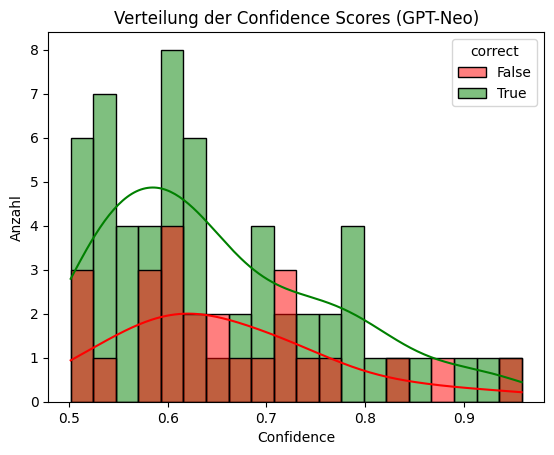

In [4]:
import seaborn as sns
import matplotlib.pyplot as plt
df["label_true"] = df["label"].apply(map_label)
df["correct"] = df["label_true"] == df["label_finetuned-llama3-healtcare_normal"]

sns.histplot(data=df, x="confidence_finetuned-llama3-healtcare_normal", hue="correct", bins=20, kde=True, palette=["red", "green"])
plt.title("Verteilung der Confidence Scores (GPT-Neo)")
plt.xlabel("Confidence")
plt.ylabel("Anzahl")
plt.show()

#### Test Gesamt

In [3]:
import torch
import os
import pandas as pd
from transformers import (
    AutoTokenizer,
    AutoModelForCausalLM,
)
import torch.nn.functional as F
from tqdm import tqdm  # für den Ladebalken

# CUDA-Konfiguration
os.environ["CUDA_VISIBLE_DEVICES"] = "2"  # anpassen falls nötig
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Prompt-Template
def build_prompt(text):
    return (
        f"Statement: {text}\n"
        f"Task: Determine whether the statement is factually correct or fake news. Use only publicly verifiable and objective facts. Do not guess.\n"
        f"Answer with only one word: True or False.\n"
        f"Answer:"
    )

# Modell-Auswahl
models = {
    "finetuned-llama3-healtcare_normal": "causal"
}

# Daten laden
df = pd.read_csv("preprocessed_test_cleaned.csv", sep="	")
df = df.iloc[:2000].copy()
statements = df["statement"].tolist()

# Ergebnis-Speicher
results = {name: [] for name in models}
confidences = {name: [] for name in models}

# Modelle durchlaufen
for model_name, model_type in models.items():
    print(f"\n📦 Lade Modell: {model_name} ({model_type})")

    tokenizer = AutoTokenizer.from_pretrained(model_name, use_fast=True)
    model = AutoModelForCausalLM.from_pretrained(model_name).to(device)
    model.eval()

    # Token IDs für " True" und " False" (mit führendem Leerzeichen!)
    true_token_id = tokenizer(" True", add_special_tokens=False)["input_ids"][0]
    false_token_id = tokenizer(" False", add_special_tokens=False)["input_ids"][0]

    # Verarbeitung mit Ladebalken
    for text in tqdm(statements, desc="🔍 Verarbeitung"):
        prompt = build_prompt(text)
        inputs = tokenizer(prompt, return_tensors="pt").to(device)

        with torch.no_grad():
            outputs = model(**inputs)
            logits = outputs.logits
            next_token_logits = logits[0, -1, :]  # nächstes Token
            probs = F.softmax(next_token_logits, dim=-1)

        # Wahrscheinlichkeiten abrufen
        prob_true = probs[true_token_id].item()
        prob_false = probs[false_token_id].item()

        if prob_true > prob_false:
            result = "True"
            confidence = prob_true
        else:
            result = "False"
            confidence = prob_false

        results[model_name].append(result)
        confidences[model_name].append(confidence)

# Ergebnisse ins DataFrame schreiben
for model_name in results:
    suffix = model_name.split("/")[-1]
    df[f"label_{suffix}"] = results[model_name]
    df[f"confidence_{suffix}"] = confidences[model_name]

# Ausgabe zur Kontrolle
print("\n✅ Verarbeitung abgeschlossen.")
df



📦 Lade Modell: finetuned-llama3-healtcare_normal (causal)


Loading checkpoint shards:   0%|          | 0/4 [00:00<?, ?it/s]

🔍 Verarbeitung: 100%|██████████| 1267/1267 [02:11<00:00,  9.63it/s]


✅ Verarbeitung abgeschlossen.


,label,statement,subjects,label_finetuned-llama3-healtcare_normal,confidence_finetuned-llama3-healtcare_normal
0,true,Building a wall on the U.S . Mexico border wil...,immigration,False,0.507427
1,false,Wisconsin is on pace to double the number of l...,jobs,True,0.510876
2,false,Says John McCain has done nothing to help the ...,"military,veterans,voting-record",False,0.662554
3,half-true,Suzanne Bonamici supports a plan that will cut...,"medicare,message-machine-2012,campaign-adverti...",False,0.745960
4,pants-fire,When asked by a reporter whether hes at the ce...,"campaign-finance,legal-issues,campaign-adverti...",True,0.614710
...,...,...,...,...,...
1262,half-true,Says his budget provides the highest state fun...,education,True,0.520410
1263,barely-true,Ive been here almost every day .,"civil-rights,crime,criminal-justice",True,0.702420
1264,barely-true,In the early 1980s Sen . Edward Kennedy secret...,"bipartisanship,congress,foreign-policy,history",False,0.616763
1265,barely-true,Says an EPA permit languished under Strickland...,"environment,government-efficiency",True,0.562641


In [4]:
import pandas as pd
from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
)

# Definiere deine Labelgruppen
true_labels = ["true", "mostly-true", "half-true"]
false_labels = ["barely-true", "false", "pants-fire", "pants-on-fire"]

# Mapping-Funktion: Normalisiert die Labels zu "True" oder "False"
def map_label(label):
    label = str(label).strip().lower()
    if label in true_labels:
        return "True"
    elif label in false_labels:
        return "False"
    else:
        return "False"  # Default für unbekannte Labels

# Wandle Ground Truth und Prediction in binäre Kategorien um
y_true = df["label"].apply(map_label)
y_pred = df["label_finetuned-llama3-healtcare_normal"].apply(lambda x: map_label(x))

# Konfusionsmatrix
cm = confusion_matrix(y_true, y_pred, labels=["True", "False"])
print("Confusion Matrix (True/False):")
print(cm)

print(f"\nAccuracy:  {accuracy_score(y_true, y_pred)}")
print(f"Precision: {precision_score(y_true, y_pred, pos_label='True')}  (bezogen auf 'True')")
print(f"Recall:    {recall_score(y_true, y_pred, pos_label='True')}  (bezogen auf 'True')")
print(f"F1 Score:  {f1_score(y_true, y_pred, pos_label='True')}  (bezogen auf 'True')")

# Optionaler vollständiger Bericht
print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=["True", "False"]))


Confusion Matrix (True/False):
[[421 293]
 [191 362]]

Accuracy:  0.6179952644041041
Precision: 0.6879084967320261  (bezogen auf 'True')
Recall:    0.5896358543417367  (bezogen auf 'True')
F1 Score:  0.6349924585218703  (bezogen auf 'True')

Classification Report:
              precision    recall  f1-score   support

        True       0.55      0.65      0.60       553
       False       0.69      0.59      0.63       714

    accuracy                           0.62      1267
   macro avg       0.62      0.62      0.62      1267
weighted avg       0.63      0.62      0.62      1267



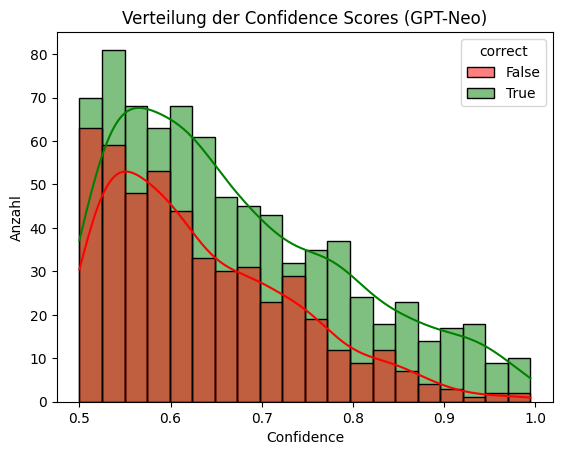

In [5]:
import seaborn as sns
import matplotlib.pyplot as plt
df["label_true"] = df["label"].apply(map_label)
df["correct"] = df["label_true"] == df["label_finetuned-llama3-healtcare_normal"]

sns.histplot(data=df, x="confidence_finetuned-llama3-healtcare_normal", hue="correct", bins=20, kde=True, palette=["red", "green"])
plt.title("Verteilung der Confidence Scores (GPT-Neo)")
plt.xlabel("Confidence")
plt.ylabel("Anzahl")
plt.show()

### Llama - Subjects

In [6]:
import pandas as pd
import json

# CSV laden
df = pd.read_csv("healthcare_prompts.csv")  # sep="\t" entfernt, falls Komma verwendet wird

# Label-Mapping in "True"/"False"
label_map = {
    "true": "True",
    "mostly-true": "True",
    "half-true": "True",
    "barely-true": "False",
    "false": "False",
    "pants-fire": "False"
}

# Prompt-Template mit Subjects und Beispiel
def create_prompt(statement, label, subjects):
    formatted_subjects = ", ".join([s.strip().title() for s in str(subjects).split(",")])
    return {
        "text": (
            f"Statement: {statement}\n"
            f"Task: Decide if the statement is factually correct. For better context, consider the subjects: {formatted_subjects}.\n"
            f"Answer only with True or False.\n"
            f"Example:\n"
            f"Statement: The sky is green.\n"
            f"Subjects: Weather, Nature\n"
            f"Answer: False\n"
            f"Statement: {statement}\n"
            f"Answer: {label}"
        )
    }

# Prompt-Daten erstellen
jsonl_data = []
for _, row in df.iterrows():
    raw_label = str(row["label"]).strip().lower()
    mapped_label = label_map.get(raw_label)

    if mapped_label:
        prompt = create_prompt(row["statement"], mapped_label, row["subjects"])
        jsonl_data.append(prompt)

# Als JSONL-Datei speichern
with open("fine_tune_data_subjects.jsonl", "w", encoding="utf-8") as f:
    for entry in jsonl_data:
        f.write(json.dumps(entry, ensure_ascii=False) + "\n")

print(f"✅ {len(jsonl_data)} Prompts gespeichert in 'fine_tune_data_subjects.jsonl'")


✅ 710 Prompts gespeichert in 'fine_tune_data.jsonl'


In [1]:
from transformers import AutoTokenizer, AutoModelForCausalLM, TrainingArguments, Trainer, DataCollatorForLanguageModeling
from datasets import load_dataset, Dataset
from peft import get_peft_model, LoraConfig, TaskType
import torch
import os 

os.environ["CUDA_VISIBLE_DEVICES"] = "2,3"  # anpassen falls nötig
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model_name = "meta-llama/Llama-3.1-8B-Instruct"
tokenizer = AutoTokenizer.from_pretrained(model_name, use_fast=True)
tokenizer.pad_token = tokenizer.eos_token  # Wichtig für CausalLM

# Beispiel-Daten laden (hier: lokal aus JSONL-Datei)
dataset = load_dataset("json", data_files={"train": "fine_tune_data_subjects.jsonl"})["train"]

# Tokenisierung
def tokenize(example):
    return tokenizer(example["text"], truncation=True, padding="max_length", max_length=512)

tokenized_dataset = dataset.map(tokenize, batched=True)

# Modell mit LoRA initialisieren
base_model = AutoModelForCausalLM.from_pretrained(model_name, device_map="auto", torch_dtype=torch.float16)

peft_config = LoraConfig(
    r=8,
    lora_alpha=32,
    target_modules=["q_proj", "v_proj"],  # hängt vom Modell ab
    lora_dropout=0.05,
    bias="none",
    task_type=TaskType.CAUSAL_LM
)

model = get_peft_model(base_model, peft_config)

# Trainingskonfiguration
training_args = TrainingArguments(
    output_dir="./results",
    per_device_train_batch_size=2,
    gradient_accumulation_steps=4,
    num_train_epochs=3,
    logging_dir="./logs",
    save_total_limit=2,
    fp16=True,
    optim="adamw_torch",
    logging_steps=10,
    save_steps=100,
    learning_rate=2e-5,
    report_to="none",
)

data_collator = DataCollatorForLanguageModeling(tokenizer, mlm=False)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_dataset,
    tokenizer=tokenizer,
    data_collator=data_collator,
)

trainer.train()


2025-07-12 08:53:01.795601: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1752303181.820964    8263 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1752303181.828081    8263 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1752303181.847770    8263 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1752303181.847790    8263 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1752303181.847793    8263 computation_placer.cc:177] computation placer alr

Loading checkpoint shards:   0%|          | 0/4 [00:00<?, ?it/s]

/tmp/ipykernel_8263/2724149745.py:55: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(
No label_names provided for model class `PeftModelForCausalLM`. Since `PeftModel` hides base models input arguments, if label_names is not given, label_names can't be set automatically within `Trainer`. Note that empty label_names list will be used instead.


Step,Training Loss
10,2.553500
20,2.315400
30,2.073800
40,1.842300
50,1.597900
60,1.405400
70,1.215200
80,0.978200
90,0.839000
100,0.812600


/home/jovyan/.local/lib/python3.10/site-packages/peft/utils/other.py:1221: UserWarning: Unable to fetch remote file due to the following error 401 Client Error. (Request ID: Root=1-687206c7-71b72ea70671c2b33e83bd95;da99a302-d5e6-4b76-8edc-ed06930a8da9)

Cannot access gated repo for url https://huggingface.co/meta-llama/Llama-3.1-8B-Instruct/resolve/main/config.json.
Access to model meta-llama/Llama-3.1-8B-Instruct is restricted. You must have access to it and be authenticated to access it. Please log in. - silently ignoring the lookup for the file config.json in meta-llama/Llama-3.1-8B-Instruct.
  warnings.warn(
/home/jovyan/.local/lib/python3.10/site-packages/peft/utils/save_and_load.py:238: UserWarning: Could not find a config file in meta-llama/Llama-3.1-8B-Instruct - will assume that the vocabulary was not modified.
  warnings.warn(
/home/jovyan/.local/lib/python3.10/site-packages/peft/utils/other.py:1221: UserWarning: Unable to fetch remote file due to the following error 401 Clie

TrainOutput(global_step=267, training_loss=1.0424392768059776, metrics={'train_runtime': 291.3639, 'train_samples_per_second': 7.31, 'train_steps_per_second': 0.916, 'total_flos': 4.912972283510784e+16, 'train_loss': 1.0424392768059776, 'epoch': 3.0})

In [2]:
trainer.save_model("finetuned-llama3-healtcare_subjects")
tokenizer.save_pretrained("finetuned-llama3-healtcare_subjects")


/home/jovyan/.local/lib/python3.10/site-packages/peft/utils/other.py:1221: UserWarning: Unable to fetch remote file due to the following error 401 Client Error. (Request ID: Root=1-68720a97-4a02acf570134f6a2cd838e8;f0c04505-aaf3-4cad-a79d-a9ea6504258e)

Cannot access gated repo for url https://huggingface.co/meta-llama/Llama-3.1-8B-Instruct/resolve/main/config.json.
Access to model meta-llama/Llama-3.1-8B-Instruct is restricted. You must have access to it and be authenticated to access it. Please log in. - silently ignoring the lookup for the file config.json in meta-llama/Llama-3.1-8B-Instruct.
  warnings.warn(
/home/jovyan/.local/lib/python3.10/site-packages/peft/utils/save_and_load.py:238: UserWarning: Could not find a config file in meta-llama/Llama-3.1-8B-Instruct - will assume that the vocabulary was not modified.
  warnings.warn(


('finetuned-llama3-healtcare_subjects/tokenizer_config.json',
 'finetuned-llama3-healtcare_subjects/special_tokens_map.json',
 'finetuned-llama3-healtcare_subjects/chat_template.jinja',
 'finetuned-llama3-healtcare_subjects/tokenizer.json')

#### Test - Healtchare

In [1]:
import torch
import os
import pandas as pd
from transformers import (
    AutoTokenizer,
    AutoModelForCausalLM,
    AutoModelForSeq2SeqLM,
    RobertaTokenizer,
    RobertaForSequenceClassification,
)
import torch.nn.functional as F
from tqdm import tqdm  # für Ladebalken

# CUDA Device
os.environ["CUDA_VISIBLE_DEVICES"] = "5"  # anpassen falls nötig
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Prompt-Template mit Statement + Subjects
def build_prompt(statement, subjects):
    return (
        f"Statement: {statement}\n"
        f"Task: Decide if the statement is factually correct. For better context, consider the subjects: {subjects}.\n"
        f"Answer only with True or False.\n"
        f"Example:\n"
        f"Statement: The sky is green.\n"
        f"Subjects: Weather, Nature\n"
        f"Answer: False\n"
        f"Statement: {statement}\n"
        f"Answer:"
    )

# Modelle
models = {
    "finetuned-llama3-healtcare_subjects": "causal",
    # weitere Modelle können ergänzt werden
}

# Daten laden
df = pd.read_csv(r"healthcare_prompts_test.csv", sep=",")
df = df.iloc[:2000].copy()

statements = df["statement"].tolist()
subjects = df["subjects"].tolist()

# Ergebnisse speichern
results = {name: [] for name in models}
confidences = {name: [] for name in models}  # für Confidence Score

# Modelle durchlaufen
for model_name, model_type in models.items():
    print(f"Lade Modell: {model_name} ({model_type})")

    if model_type == "causal":
        tokenizer = AutoTokenizer.from_pretrained(model_name, use_fast=True)
        model = AutoModelForCausalLM.from_pretrained(model_name).to(device)
        model.eval()

        # Tokens mit führendem Leerzeichen, wichtig!
        true_token_id = tokenizer(" True", add_special_tokens=False)["input_ids"][0]
        false_token_id = tokenizer(" False", add_special_tokens=False)["input_ids"][0]

        # tqdm Ladebalken für Fortschritt
        for text, subj in tqdm(zip(statements, subjects), total=len(statements), desc="Processing causal model"):
            prompt = build_prompt(text, subj)
            inputs = tokenizer(prompt, return_tensors="pt", truncation=True).to(device)
            with torch.no_grad():
                outputs = model(**inputs)
                logits = outputs.logits
                next_token_logits = logits[0, -1, :]
                probs = F.softmax(next_token_logits, dim=-1)

            prob_true = probs[true_token_id].item()
            prob_false = probs[false_token_id].item()

            if prob_true > prob_false:
                result = "True"
                confidence = prob_true
            else:
                result = "False"
                confidence = prob_false

            results[model_name].append(result)
            confidences[model_name].append(confidence)

# Ergebnisse im DataFrame speichern
for model_name in results:
    suffix = model_name.split("/")[-1]
    df[f"label_{suffix}"] = results[model_name]
    # Nur für causal Modell Confidence speichern
    if model_name in confidences:
        df[f"confidence_{suffix}"] = confidences[model_name]

# Ausgabe DataFrame (z.B. df.head())
df.head


2025-07-12 09:41:54.215743: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1752306114.236770   10865 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1752306114.243100   10865 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1752306114.261344   10865 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1752306114.261363   10865 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1752306114.261365   10865 computation_placer.cc:177] computation placer alr

Lade Modell: finetuned-llama3-healtcare_subjects (causal)


Loading checkpoint shards:   0%|          | 0/4 [00:00<?, ?it/s]

Processing causal model: 100%|██████████| 83/83 [00:12<00:00,  6.90it/s]


<bound method NDFrame.head of           label                                          statement  \
0          true  Each year 18000 people die in America because ...   
1   mostly-true  Active duty males in the military are twice as...   
2     half-true  Says Thomas Jefferson said You might be able t...   
3   barely-true  Because of the federal health care law 300000 ...   
4   barely-true  Pre-existing conditions are covered under my (...   
..          ...                                                ...   
78        false  We had an amendment in the health care law tha...   
79         true  Texas has the highest rate of uninsured in the...   
80         true  Says 80 percent of the health care dollars are...   
81   pants-fire  Says state Rep . Sandy Pasch her recall oppone...   
82    half-true  Says Mark Pryorcut Medicare to pay for Obamaca...   

                     subjects label_finetuned-llama3-healtcare_subjects  \
0                 health-care                         

In [2]:
import pandas as pd
from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
)

# Definiere deine Labelgruppen
true_labels = ["true", "mostly-true", "half-true"]
false_labels = ["barely-true", "false", "pants-fire", "pants-on-fire"]

# Mapping-Funktion: Normalisiert die Labels zu "True" oder "False"
def map_label(label):
    label = str(label).strip().lower()
    if label in true_labels:
        return "True"
    elif label in false_labels:
        return "False"
    else:
        return "False"  # Default für unbekannte Labels

# Wandle Ground Truth und Prediction in binäre Kategorien um
y_true = df["label"].apply(map_label)
y_pred = df["label_finetuned-llama3-healtcare_subjects"].apply(lambda x: map_label(x))

# Konfusionsmatrix
cm = confusion_matrix(y_true, y_pred, labels=["True", "False"])
print("Confusion Matrix (True/False):")
print(cm)

print(f"\nAccuracy:  {accuracy_score(y_true, y_pred)}")
print(f"Precision: {precision_score(y_true, y_pred, pos_label='True')}  (bezogen auf 'True')")
print(f"Recall:    {recall_score(y_true, y_pred, pos_label='True')}  (bezogen auf 'True')")
print(f"F1 Score:  {f1_score(y_true, y_pred, pos_label='True')}  (bezogen auf 'True')")

# Optionaler vollständiger Bericht
print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=["True", "False"]))


Confusion Matrix (True/False):
[[24 18]
 [14 27]]

Accuracy:  0.6144578313253012
Precision: 0.631578947368421  (bezogen auf 'True')
Recall:    0.5714285714285714  (bezogen auf 'True')
F1 Score:  0.6  (bezogen auf 'True')

Classification Report:
              precision    recall  f1-score   support

        True       0.60      0.66      0.63        41
       False       0.63      0.57      0.60        42

    accuracy                           0.61        83
   macro avg       0.62      0.61      0.61        83
weighted avg       0.62      0.61      0.61        83



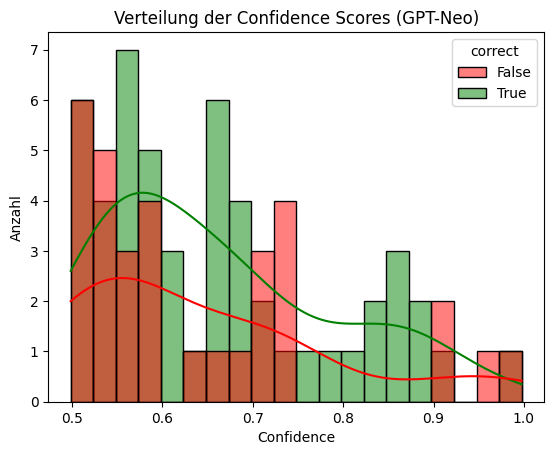

In [3]:
import seaborn as sns
import matplotlib.pyplot as plt
df["label_true"] = df["label"].apply(map_label)
df["correct"] = df["label_true"] == df["label_finetuned-llama3-healtcare_subjects"]

sns.histplot(data=df, x="confidence_finetuned-llama3-healtcare_subjects", hue="correct", bins=20, kde=True, palette=["red", "green"])
plt.title("Verteilung der Confidence Scores (GPT-Neo)")
plt.xlabel("Confidence")
plt.ylabel("Anzahl")
plt.show()

#### Test - Subjects

In [1]:
import torch
import os
import pandas as pd
from transformers import (
    AutoTokenizer,
    AutoModelForCausalLM,
    AutoModelForSeq2SeqLM,
    RobertaTokenizer,
    RobertaForSequenceClassification,
)
import torch.nn.functional as F
from tqdm import tqdm  # für Ladebalken

# CUDA Device
os.environ["CUDA_VISIBLE_DEVICES"] = "5"  # anpassen falls nötig
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Prompt-Template mit Statement + Subjects
def build_prompt(statement, subjects):
    return (
        f"Statement: {statement}\n"
        f"Task: Decide if the statement is factually correct. For better context, consider the subjects: {subjects}.\n"
        f"Answer only with True or False.\n"
        f"Example:\n"
        f"Statement: The sky is green.\n"
        f"Subjects: Weather, Nature\n"
        f"Answer: False\n"
        f"Statement: {statement}\n"
        f"Answer:"
    )

# Modelle
models = {
    "finetuned-llama3-healtcare_subjects": "causal",
    # weitere Modelle können ergänzt werden
}

# Daten laden
df = pd.read_csv(r"preprocessed_test_cleaned.csv", sep="\t")
df = df.iloc[:2000].copy()

statements = df["statement"].tolist()
subjects = df["subjects"].tolist()

# Ergebnisse speichern
results = {name: [] for name in models}
confidences = {name: [] for name in models}  # für Confidence Score

# Modelle durchlaufen
for model_name, model_type in models.items():
    print(f"Lade Modell: {model_name} ({model_type})")

    if model_type == "causal":
        tokenizer = AutoTokenizer.from_pretrained(model_name, use_fast=True)
        model = AutoModelForCausalLM.from_pretrained(model_name).to(device)
        model.eval()

        # Tokens mit führendem Leerzeichen, wichtig!
        true_token_id = tokenizer(" True", add_special_tokens=False)["input_ids"][0]
        false_token_id = tokenizer(" False", add_special_tokens=False)["input_ids"][0]

        # tqdm Ladebalken für Fortschritt
        for text, subj in tqdm(zip(statements, subjects), total=len(statements), desc="Processing causal model"):
            prompt = build_prompt(text, subj)
            inputs = tokenizer(prompt, return_tensors="pt", truncation=True).to(device)
            with torch.no_grad():
                outputs = model(**inputs)
                logits = outputs.logits
                next_token_logits = logits[0, -1, :]
                probs = F.softmax(next_token_logits, dim=-1)

            prob_true = probs[true_token_id].item()
            prob_false = probs[false_token_id].item()

            if prob_true > prob_false:
                result = "True"
                confidence = prob_true
            else:
                result = "False"
                confidence = prob_false

            results[model_name].append(result)
            confidences[model_name].append(confidence)

# Ergebnisse im DataFrame speichern
for model_name in results:
    suffix = model_name.split("/")[-1]
    df[f"label_{suffix}"] = results[model_name]
    # Nur für causal Modell Confidence speichern
    if model_name in confidences:
        df[f"confidence_{suffix}"] = confidences[model_name]

# Ausgabe DataFrame (z.B. df.head())
df.head


2025-07-12 09:43:55.639009: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1752306235.662639   11240 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1752306235.669332   11240 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1752306235.689517   11240 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1752306235.689542   11240 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1752306235.689544   11240 computation_placer.cc:177] computation placer alr

Lade Modell: finetuned-llama3-healtcare_subjects (causal)


Loading checkpoint shards:   0%|          | 0/4 [00:00<?, ?it/s]

Processing causal model: 100%|██████████| 1267/1267 [03:01<00:00,  6.97it/s]


<bound method NDFrame.head of             label                                          statement  \
0            true  Building a wall on the U.S . Mexico border wil...   
1           false  Wisconsin is on pace to double the number of l...   
2           false  Says John McCain has done nothing to help the ...   
3       half-true  Suzanne Bonamici supports a plan that will cut...   
4      pants-fire  When asked by a reporter whether hes at the ce...   
...           ...                                                ...   
1262    half-true  Says his budget provides the highest state fun...   
1263  barely-true                   Ive been here almost every day .   
1264  barely-true  In the early 1980s Sen . Edward Kennedy secret...   
1265  barely-true  Says an EPA permit languished under Strickland...   
1266        false  Says the governor is going around the state ta...   

                                               subjects  \
0                                           im

In [2]:
import pandas as pd
from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
)

# Definiere deine Labelgruppen
true_labels = ["true", "mostly-true", "half-true"]
false_labels = ["barely-true", "false", "pants-fire", "pants-on-fire"]

# Mapping-Funktion: Normalisiert die Labels zu "True" oder "False"
def map_label(label):
    label = str(label).strip().lower()
    if label in true_labels:
        return "True"
    elif label in false_labels:
        return "False"
    else:
        return "False"  # Default für unbekannte Labels

# Wandle Ground Truth und Prediction in binäre Kategorien um
y_true = df["label"].apply(map_label)
y_pred = df["label_finetuned-llama3-healtcare_subjects"].apply(lambda x: map_label(x))

# Konfusionsmatrix
cm = confusion_matrix(y_true, y_pred, labels=["True", "False"])
print("Confusion Matrix (True/False):")
print(cm)

print(f"\nAccuracy:  {accuracy_score(y_true, y_pred)}")
print(f"Precision: {precision_score(y_true, y_pred, pos_label='True')}  (bezogen auf 'True')")
print(f"Recall:    {recall_score(y_true, y_pred, pos_label='True')}  (bezogen auf 'True')")
print(f"F1 Score:  {f1_score(y_true, y_pred, pos_label='True')}  (bezogen auf 'True')")

# Optionaler vollständiger Bericht
print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=["True", "False"]))


Confusion Matrix (True/False):
[[462 252]
 [251 302]]

Accuracy:  0.6029992107340174
Precision: 0.6479663394109397  (bezogen auf 'True')
Recall:    0.6470588235294118  (bezogen auf 'True')
F1 Score:  0.6475122634898388  (bezogen auf 'True')

Classification Report:
              precision    recall  f1-score   support

        True       0.55      0.55      0.55       553
       False       0.65      0.65      0.65       714

    accuracy                           0.60      1267
   macro avg       0.60      0.60      0.60      1267
weighted avg       0.60      0.60      0.60      1267



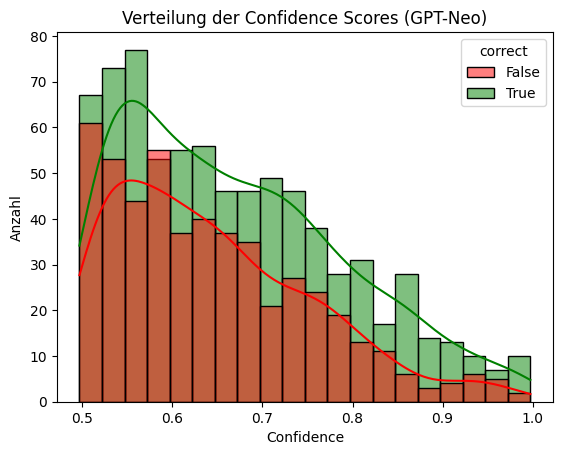

In [3]:
import seaborn as sns
import matplotlib.pyplot as plt
df["label_true"] = df["label"].apply(map_label)
df["correct"] = df["label_true"] == df["label_finetuned-llama3-healtcare_subjects"]

sns.histplot(data=df, x="confidence_finetuned-llama3-healtcare_subjects", hue="correct", bins=20, kde=True, palette=["red", "green"])
plt.title("Verteilung der Confidence Scores (GPT-Neo)")
plt.xlabel("Confidence")
plt.ylabel("Anzahl")
plt.show()

## DeepSeek - Normal

In [1]:
from transformers import AutoTokenizer, AutoModelForCausalLM, TrainingArguments, Trainer, DataCollatorForLanguageModeling
from datasets import load_dataset, Dataset
from peft import get_peft_model, LoraConfig, TaskType
import torch
import os 

os.environ["CUDA_VISIBLE_DEVICES"] = "2,3"  # anpassen falls nötig
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model_name = "deepseek-ai/deepseek-llm-7b-base"
tokenizer = AutoTokenizer.from_pretrained(model_name, use_fast=True)
tokenizer.pad_token = tokenizer.eos_token  # Wichtig für CausalLM

# Beispiel-Daten laden (hier: lokal aus JSONL-Datei)
dataset = load_dataset("json", data_files={"train": "fine_tune_data.jsonl"})["train"]

# Tokenisierung
def tokenize(example):
    return tokenizer(example["text"], truncation=True, padding="max_length", max_length=512)

tokenized_dataset = dataset.map(tokenize, batched=True)

# Modell mit LoRA initialisieren
base_model = AutoModelForCausalLM.from_pretrained(model_name, device_map="auto", torch_dtype=torch.float16)

peft_config = LoraConfig(
    r=8,
    lora_alpha=32,
    target_modules=["q_proj", "v_proj"],  # hängt vom Modell ab
    lora_dropout=0.05,
    bias="none",
    task_type=TaskType.CAUSAL_LM
)

model = get_peft_model(base_model, peft_config)

# Trainingskonfiguration
training_args = TrainingArguments(
    output_dir="./results",
    per_device_train_batch_size=2,
    gradient_accumulation_steps=4,
    num_train_epochs=3,
    logging_dir="./logs",
    save_total_limit=2,
    fp16=True,
    optim="adamw_torch",
    logging_steps=10,
    save_steps=100,
    learning_rate=2e-5,
    report_to="none",
)

data_collator = DataCollatorForLanguageModeling(tokenizer, mlm=False)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_dataset,
    tokenizer=tokenizer,
    data_collator=data_collator,
)

trainer.train()


2025-07-12 09:26:29.212610: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1752305189.233830    9746 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1752305189.240408    9746 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1752305189.259421    9746 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1752305189.259455    9746 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1752305189.259457    9746 computation_placer.cc:177] computation placer alr

Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

/tmp/ipykernel_9746/3012345629.py:55: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(
No label_names provided for model class `PeftModelForCausalLM`. Since `PeftModel` hides base models input arguments, if label_names is not given, label_names can't be set automatically within `Trainer`. Note that empty label_names list will be used instead.


Step,Training Loss
10,2.863700
20,2.762900
30,2.635600
40,2.492300
50,2.365300
60,2.204600
70,1.970900
80,1.674400
90,1.381700
100,1.230500


TrainOutput(global_step=267, training_loss=1.3918438672126456, metrics={'train_runtime': 261.4469, 'train_samples_per_second': 8.147, 'train_steps_per_second': 1.021, 'total_flos': 4.249825591689216e+16, 'train_loss': 1.3918438672126456, 'epoch': 3.0})

In [4]:
trainer.save_model("finetuned-deepseek-healtcare_normal")
tokenizer.save_pretrained("finetuned-deepseek-healtcare_normal")


('finetuned-deepseek-healtcare_normal/tokenizer_config.json',
 'finetuned-deepseek-healtcare_normal/special_tokens_map.json',
 'finetuned-deepseek-healtcare_normal/tokenizer.json')

#### Test Healtcare

In [5]:
import torch
import os
import pandas as pd
from transformers import (
    AutoTokenizer,
    AutoModelForCausalLM,
)
import torch.nn.functional as F
from tqdm import tqdm  # für den Ladebalken

# CUDA-Konfiguration
os.environ["CUDA_VISIBLE_DEVICES"] = "2"  # anpassen falls nötig
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Prompt-Template
def build_prompt(text):
    return (
        f"Statement: {text}\n"
        f"Task: Determine whether the statement is factually correct or fake news. Use only publicly verifiable and objective facts. Do not guess.\n"
        f"Answer with only one word: True or False.\n"
        f"Answer:"
    )

# Modell-Auswahl
models = {
    "finetuned-deepseek-healtcare_normal": "causal"
}

# Daten laden
df = pd.read_csv("healthcare_prompts_test.csv", sep=",")
df = df.iloc[:2000].copy()
statements = df["statement"].tolist()

# Ergebnis-Speicher
results = {name: [] for name in models}
confidences = {name: [] for name in models}

# Modelle durchlaufen
for model_name, model_type in models.items():
    print(f"\n📦 Lade Modell: {model_name} ({model_type})")

    tokenizer = AutoTokenizer.from_pretrained(model_name, use_fast=True)
    model = AutoModelForCausalLM.from_pretrained(model_name).to(device)
    model.eval()

    # Token IDs für " True" und " False" (mit führendem Leerzeichen!)
    true_token_id = tokenizer(" True", add_special_tokens=False)["input_ids"][0]
    false_token_id = tokenizer(" False", add_special_tokens=False)["input_ids"][0]

    # Verarbeitung mit Ladebalken
    for text in tqdm(statements, desc="🔍 Verarbeitung"):
        prompt = build_prompt(text)
        inputs = tokenizer(prompt, return_tensors="pt").to(device)

        with torch.no_grad():
            outputs = model(**inputs)
            logits = outputs.logits
            next_token_logits = logits[0, -1, :]  # nächstes Token
            probs = F.softmax(next_token_logits, dim=-1)

        # Wahrscheinlichkeiten abrufen
        prob_true = probs[true_token_id].item()
        prob_false = probs[false_token_id].item()

        if prob_true > prob_false:
            result = "True"
            confidence = prob_true
        else:
            result = "False"
            confidence = prob_false

        results[model_name].append(result)
        confidences[model_name].append(confidence)

# Ergebnisse ins DataFrame schreiben
for model_name in results:
    suffix = model_name.split("/")[-1]
    df[f"label_{suffix}"] = results[model_name]
    df[f"confidence_{suffix}"] = confidences[model_name]

# Ausgabe zur Kontrolle
print("\n✅ Verarbeitung abgeschlossen.")
df



📦 Lade Modell: finetuned-deepseek-healtcare_normal (causal)


Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

🔍 Verarbeitung: 100%|██████████| 83/83 [00:07<00:00, 11.06it/s]


✅ Verarbeitung abgeschlossen.


,label,statement,subjects,label_finetuned-deepseek-healtcare_normal,confidence_finetuned-deepseek-healtcare_normal
0,true,Each year 18000 people die in America because ...,health-care,True,0.576511
1,mostly-true,Active duty males in the military are twice as...,"health-care,military",True,0.530940
2,half-true,Says Thomas Jefferson said You might be able t...,"health-care,history",False,0.523724
3,barely-true,Because of the federal health care law 300000 ...,health-care,True,0.559181
4,barely-true,Pre-existing conditions are covered under my (...,"debates,health-care",True,0.557110
...,...,...,...,...,...
78,false,We had an amendment in the health care law tha...,"education,health-care",False,0.562920
79,true,Texas has the highest rate of uninsured in the...,health-care,True,0.512859
80,true,Says 80 percent of the health care dollars are...,"health-care,public-health",False,0.534384
81,pants-fire,Says state Rep . Sandy Pasch her recall oppone...,"health-care,unions",False,0.647972


In [6]:
import pandas as pd
from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
)

# Definiere deine Labelgruppen
true_labels = ["true", "mostly-true", "half-true"]
false_labels = ["barely-true", "false", "pants-fire", "pants-on-fire"]

# Mapping-Funktion: Normalisiert die Labels zu "True" oder "False"
def map_label(label):
    label = str(label).strip().lower()
    if label in true_labels:
        return "True"
    elif label in false_labels:
        return "False"
    else:
        return "False"  # Default für unbekannte Labels

# Wandle Ground Truth und Prediction in binäre Kategorien um
y_true = df["label"].apply(map_label)
y_pred = df["label_finetuned-deepseek-healtcare_normal"].apply(lambda x: map_label(x))

# Konfusionsmatrix
cm = confusion_matrix(y_true, y_pred, labels=["True", "False"])
print("Confusion Matrix (True/False):")
print(cm)

print(f"\nAccuracy:  {accuracy_score(y_true, y_pred)}")
print(f"Precision: {precision_score(y_true, y_pred, pos_label='True')}  (bezogen auf 'True')")
print(f"Recall:    {recall_score(y_true, y_pred, pos_label='True')}  (bezogen auf 'True')")
print(f"F1 Score:  {f1_score(y_true, y_pred, pos_label='True')}  (bezogen auf 'True')")

# Optionaler vollständiger Bericht
print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=["True", "False"]))


Confusion Matrix (True/False):
[[23 19]
 [17 24]]

Accuracy:  0.5662650602409639
Precision: 0.575  (bezogen auf 'True')
Recall:    0.5476190476190477  (bezogen auf 'True')
F1 Score:  0.5609756097560976  (bezogen auf 'True')

Classification Report:
              precision    recall  f1-score   support

        True       0.56      0.59      0.57        41
       False       0.57      0.55      0.56        42

    accuracy                           0.57        83
   macro avg       0.57      0.57      0.57        83
weighted avg       0.57      0.57      0.57        83



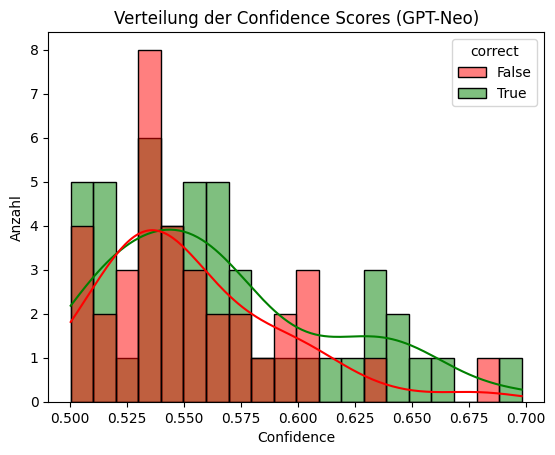

In [7]:
import seaborn as sns
import matplotlib.pyplot as plt
df["label_true"] = df["label"].apply(map_label)
df["correct"] = df["label_true"] == df["label_finetuned-deepseek-healtcare_normal"]

sns.histplot(data=df, x="confidence_finetuned-deepseek-healtcare_normal", hue="correct", bins=20, kde=True, palette=["red", "green"])
plt.title("Verteilung der Confidence Scores (GPT-Neo)")
plt.xlabel("Confidence")
plt.ylabel("Anzahl")
plt.show()

#### Test gesamt

In [1]:
import torch
import os
import pandas as pd
from transformers import (
    AutoTokenizer,
    AutoModelForCausalLM,
)
import torch.nn.functional as F
from tqdm import tqdm  # für den Ladebalken

# CUDA-Konfiguration
os.environ["CUDA_VISIBLE_DEVICES"] = "2"  # anpassen falls nötig
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Prompt-Template
def build_prompt(text):
    return (
        f"Statement: {text}\n"
        f"Task: Determine whether the statement is factually correct or fake news. Use only publicly verifiable and objective facts. Do not guess.\n"
        f"Answer with only one word: True or False.\n"
        f"Answer:"
    )

# Modell-Auswahl
models = {
    "finetuned-deepseek-healtcare_normal": "causal"
}

# Daten laden
df = pd.read_csv("preprocessed_test_cleaned.csv", sep="	")
df = df.iloc[:2000].copy()
statements = df["statement"].tolist()

# Ergebnis-Speicher
results = {name: [] for name in models}
confidences = {name: [] for name in models}

# Modelle durchlaufen
for model_name, model_type in models.items():
    print(f"\n📦 Lade Modell: {model_name} ({model_type})")

    tokenizer = AutoTokenizer.from_pretrained(model_name, use_fast=True)
    model = AutoModelForCausalLM.from_pretrained(model_name).to(device)
    model.eval()

    # Token IDs für " True" und " False" (mit führendem Leerzeichen!)
    true_token_id = tokenizer(" True", add_special_tokens=False)["input_ids"][0]
    false_token_id = tokenizer(" False", add_special_tokens=False)["input_ids"][0]

    # Verarbeitung mit Ladebalken
    for text in tqdm(statements, desc="🔍 Verarbeitung"):
        prompt = build_prompt(text)
        inputs = tokenizer(prompt, return_tensors="pt").to(device)

        with torch.no_grad():
            outputs = model(**inputs)
            logits = outputs.logits
            next_token_logits = logits[0, -1, :]  # nächstes Token
            probs = F.softmax(next_token_logits, dim=-1)

        # Wahrscheinlichkeiten abrufen
        prob_true = probs[true_token_id].item()
        prob_false = probs[false_token_id].item()

        if prob_true > prob_false:
            result = "True"
            confidence = prob_true
        else:
            result = "False"
            confidence = prob_false

        results[model_name].append(result)
        confidences[model_name].append(confidence)

# Ergebnisse ins DataFrame schreiben
for model_name in results:
    suffix = model_name.split("/")[-1]
    df[f"label_{suffix}"] = results[model_name]
    df[f"confidence_{suffix}"] = confidences[model_name]

# Ausgabe zur Kontrolle
print("\n✅ Verarbeitung abgeschlossen.")
df



📦 Lade Modell: finetuned-deepseek-healtcare_normal (causal)


2025-07-13 09:55:17.714764: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1752393317.733776   20459 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1752393317.738505   20459 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1752393317.752501   20459 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1752393317.752513   20459 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1752393317.752515   20459 computation_placer.cc:177] computation placer alr

Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

🔍 Verarbeitung: 100%|██████████| 1267/1267 [01:54<00:00, 11.07it/s]


✅ Verarbeitung abgeschlossen.


,label,statement,subjects,label_finetuned-deepseek-healtcare_normal,confidence_finetuned-deepseek-healtcare_normal
0,true,Building a wall on the U.S . Mexico border wil...,immigration,True,0.566465
1,false,Wisconsin is on pace to double the number of l...,jobs,False,0.557292
2,false,Says John McCain has done nothing to help the ...,"military,veterans,voting-record",False,0.702595
3,half-true,Suzanne Bonamici supports a plan that will cut...,"medicare,message-machine-2012,campaign-adverti...",False,0.529573
4,pants-fire,When asked by a reporter whether hes at the ce...,"campaign-finance,legal-issues,campaign-adverti...",False,0.509038
...,...,...,...,...,...
1262,half-true,Says his budget provides the highest state fun...,education,False,0.613027
1263,barely-true,Ive been here almost every day .,"civil-rights,crime,criminal-justice",True,0.549798
1264,barely-true,In the early 1980s Sen . Edward Kennedy secret...,"bipartisanship,congress,foreign-policy,history",False,0.497566
1265,barely-true,Says an EPA permit languished under Strickland...,"environment,government-efficiency",False,0.718759


In [2]:
import pandas as pd
from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
)

# Definiere deine Labelgruppen
true_labels = ["true", "mostly-true", "half-true"]
false_labels = ["barely-true", "false", "pants-fire", "pants-on-fire"]

# Mapping-Funktion: Normalisiert die Labels zu "True" oder "False"
def map_label(label):
    label = str(label).strip().lower()
    if label in true_labels:
        return "True"
    elif label in false_labels:
        return "False"
    else:
        return "False"  # Default für unbekannte Labels

# Wandle Ground Truth und Prediction in binäre Kategorien um
y_true = df["label"].apply(map_label)
y_pred = df["label_finetuned-deepseek-healtcare_normal"].apply(lambda x: map_label(x))

# Konfusionsmatrix
cm = confusion_matrix(y_true, y_pred, labels=["True", "False"])
print("Confusion Matrix (True/False):")
print(cm)

print(f"\nAccuracy:  {accuracy_score(y_true, y_pred)}")
print(f"Precision: {precision_score(y_true, y_pred, pos_label='True')}  (bezogen auf 'True')")
print(f"Recall:    {recall_score(y_true, y_pred, pos_label='True')}  (bezogen auf 'True')")
print(f"F1 Score:  {f1_score(y_true, y_pred, pos_label='True')}  (bezogen auf 'True')")

# Optionaler vollständiger Bericht
print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=["True", "False"]))


Confusion Matrix (True/False):
[[332 382]
 [186 367]]

Accuracy:  0.5516969218626677
Precision: 0.640926640926641  (bezogen auf 'True')
Recall:    0.4649859943977591  (bezogen auf 'True')
F1 Score:  0.538961038961039  (bezogen auf 'True')

Classification Report:
              precision    recall  f1-score   support

        True       0.49      0.66      0.56       553
       False       0.64      0.46      0.54       714

    accuracy                           0.55      1267
   macro avg       0.57      0.56      0.55      1267
weighted avg       0.58      0.55      0.55      1267



In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
df["label_true"] = df["label"].apply(map_label)
df["correct"] = df["label_true"] == df["label_finetuned-deepseek-healtcare_normal"]

sns.histplot(data=df, x="confidence_finetuned-deepseek-healtcare_normal", hue="correct", bins=20, kde=True, palette=["red", "green"])
plt.title("Verteilung der Confidence Scores (GPT-Neo)")
plt.xlabel("Confidence")
plt.ylabel("Anzahl")
plt.show()

## Deepseek - Subjects

In [7]:
import os
import torch
import numpy as np
from collections import Counter
from datasets import load_dataset
from transformers import (
    AutoTokenizer,
    AutoModelForCausalLM,
    TrainingArguments,
    DataCollatorForLanguageModeling,
)
from peft import get_peft_model, LoraConfig, TaskType
from transformers import Trainer
import torch.nn as nn
import gc

# ------------------------- #
# 1. CUDA & Geräte Setup
# ------------------------- #
os.environ["CUDA_VISIBLE_DEVICES"] = "2,3"
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ------------------------- #
# 2. Tokenizer & Dataset
# ------------------------- #
model_name = "deepseek-ai/deepseek-llm-7b-base"
tokenizer = AutoTokenizer.from_pretrained(model_name, use_fast=True)
tokenizer.pad_token = tokenizer.eos_token

dataset = load_dataset("json", data_files={"train": "../own_datasets/fine_tune_data_subjects.jsonl"})["train"]

def tokenize(example):
    return tokenizer(example["text"], truncation=True, padding="max_length", max_length=512)

tokenized_dataset = dataset.map(tokenize, batched=True)

# ------------------------- #
# 3. Base Model mit LoRA
# ------------------------- #
base_model = AutoModelForCausalLM.from_pretrained(
    model_name, device_map="auto", torch_dtype=torch.float16
)

peft_config = LoraConfig(
    r=8,
    lora_alpha=32,
    target_modules=["q_proj", "v_proj"],
    lora_dropout=0.05,
    bias="none",
    task_type=TaskType.CAUSAL_LM
)

model = get_peft_model(base_model, peft_config)

# ------------------------- #
# 4. Token-basierte Class Weights
# ------------------------- #
token_counts = Counter()
for example in tokenized_dataset:
    tokens = example["input_ids"]
    token_counts.update(t for t in tokens if t != tokenizer.pad_token_id)

total_tokens = sum(token_counts.values())
vocab_size = model.config.vocab_size  # ← sichere Quelle
weights = np.ones(vocab_size)

for token_id, count in token_counts.items():
    if token_id < vocab_size:
        weights[token_id] = total_tokens / (count + 1e-6)

weights = weights / weights.sum()
weights = torch.tensor(weights, dtype=torch.float32)



# ------------------------- #
# 5. Custom Weighted Trainer
# ------------------------- #
class WeightedLossTrainer(Trainer):
    def __init__(self, *args, class_weights=None, **kwargs):
        super().__init__(*args, **kwargs)
        self.class_weights = class_weights

    def compute_loss(self, model, inputs, return_outputs=False, num_items_in_batch=None):
        labels = inputs.get("labels")
        outputs = model(**inputs)
        logits = outputs.get("logits")

        loss_fct = nn.CrossEntropyLoss(weight=self.class_weights.to(logits.device), ignore_index=-100)
        loss = loss_fct(logits.view(-1, logits.size(-1)), labels.view(-1))

        return (loss, outputs) if return_outputs else loss

# ------------------------- #
# 6. TrainingArguments
# ------------------------- #
training_args = TrainingArguments(
    output_dir="./results",
    per_device_train_batch_size=2,
    gradient_accumulation_steps=4,
    num_train_epochs=3,
    logging_dir="./logs",
    save_total_limit=2,
    fp16=True,
    optim="adamw_torch",
    logging_steps=10,
    save_steps=100,
    learning_rate=2e-5,
    report_to="none",
)

data_collator = DataCollatorForLanguageModeling(tokenizer, mlm=False)

# ------------------------- #
# 7. Trainer Initialisierung
# ------------------------- #
trainer = WeightedLossTrainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_dataset,
    tokenizer=tokenizer,
    data_collator=data_collator,
    class_weights=weights
)

# ------------------------- #
# 8. Trainieren & Cleanup
# ------------------------- #
trainer.train()

# GPU/CPU Cache leeren
#torch.cuda.empty_cache()
#gc.collect()


Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

/tmp/ipykernel_39498/2242929448.py:81: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `WeightedLossTrainer.__init__`. Use `processing_class` instead.
  super().__init__(*args, **kwargs)
No label_names provided for model class `PeftModelForCausalLM`. Since `PeftModel` hides base models input arguments, if label_names is not given, label_names can't be set automatically within `Trainer`. Note that empty label_names list will be used instead.


Step,Training Loss
10,56.615200
20,54.739700
30,54.406000
40,52.165400
50,49.116800
60,47.673200
70,45.970700
80,42.963300
90,39.271800
100,36.260000


TrainOutput(global_step=267, training_loss=27.796641260497132, metrics={'train_runtime': 270.7057, 'train_samples_per_second': 7.868, 'train_steps_per_second': 0.986, 'total_flos': 4.249825591689216e+16, 'train_loss': 27.796641260497132, 'epoch': 3.0})

In [8]:
trainer.save_model("../models/finetuned-deepseek-healtcare_subjects")
tokenizer.save_pretrained("../models/finetuned-deepseek-healtcare_subjects")


('../models/finetuned-deepseek-healtcare_subjects/tokenizer_config.json',
 '../models/finetuned-deepseek-healtcare_subjects/special_tokens_map.json',
 '../models/finetuned-deepseek-healtcare_subjects/tokenizer.json')

In [22]:
import gc


torch.cuda.empty_cache()
gc.collect()
import os
os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True"


#### Test Healtcare

In [17]:
import torch
import os
import pandas as pd
from transformers import (
    AutoTokenizer,
    AutoModelForCausalLM,
    AutoModelForSeq2SeqLM,
    RobertaTokenizer,
    RobertaForSequenceClassification,
)
import torch.nn.functional as F
from tqdm import tqdm  # für Ladebalken

# CUDA Device
os.environ["CUDA_VISIBLE_DEVICES"] = "5"  # anpassen falls nötig
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Prompt-Template mit Statement + Subjects
def build_prompt(statement, subjects):
    return (
        f"Statement: {statement}\n"
        f"Task: Decide if the statement is factually correct. For better context, consider the subjects: {subjects}.\n"
        f"Answer only with True or False.\n"
        f"Example:\n"
        f"Statement: The sky is green.\n"
        f"Subjects: Weather, Nature\n"
        f"Answer: False\n"
        f"Statement: {statement}\n"
        f"Answer:"
    )

# Modelle
models = {
    "../models/finetuned-deepseek-healtcare_subjects": "causal",
    # weitere Modelle können ergänzt werden
}

# Daten laden
df = pd.read_csv(r"../own_datasets/healthcare_prompts_test.csv", sep=",")
df = df.iloc[:2000].copy()

statements = df["statement"].tolist()
subjects = df["subjects"].tolist()

# Ergebnisse speichern
results = {name: [] for name in models}
confidences = {name: [] for name in models}  # für Confidence Score

# Modelle durchlaufen
for model_name, model_type in models.items():
    print(f"Lade Modell: {model_name} ({model_type})")

    if model_type == "causal":
        tokenizer = AutoTokenizer.from_pretrained(model_name, use_fast=True)
        model = AutoModelForCausalLM.from_pretrained(model_name).to(device)
        model.eval()

        # Tokens mit führendem Leerzeichen, wichtig!
        true_token_id = tokenizer(" True", add_special_tokens=False)["input_ids"][0]
        false_token_id = tokenizer(" False", add_special_tokens=False)["input_ids"][0]

        # tqdm Ladebalken für Fortschritt
        for text, subj in tqdm(zip(statements, subjects), total=len(statements), desc="Processing causal model"):
            prompt = build_prompt(text, subj)
            inputs = tokenizer(prompt, return_tensors="pt", truncation=True).to(device)
            with torch.no_grad():
                outputs = model(**inputs)
                logits = outputs.logits
                next_token_logits = logits[0, -1, :]
                probs = F.softmax(next_token_logits, dim=-1)

            prob_true = probs[true_token_id].item()
            prob_false = probs[false_token_id].item()

            if prob_true > prob_false:
                result = "True"
                confidence = prob_true
            else:
                result = "False"
                confidence = prob_false

            results[model_name].append(result)
            confidences[model_name].append(confidence)

# Ergebnisse im DataFrame speichern
for model_name in results:
    suffix = model_name.split("/")[-1]
    df[f"label_{suffix}"] = results[model_name]
    # Nur für causal Modell Confidence speichern
    if model_name in confidences:
        df[f"confidence_{suffix}"] = confidences[model_name]

# Ausgabe DataFrame (z.B. df.head())
df.head


Lade Modell: ../models/finetuned-deepseek-healtcare_subjects (causal)


Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

Processing causal model: 100%|██████████| 83/83 [00:10<00:00,  8.01it/s]


<bound method NDFrame.head of           label                                          statement  \
0          true  Each year 18000 people die in America because ...   
1   mostly-true  Active duty males in the military are twice as...   
2     half-true  Says Thomas Jefferson said You might be able t...   
3   barely-true  Because of the federal health care law 300000 ...   
4   barely-true  Pre-existing conditions are covered under my (...   
..          ...                                                ...   
78        false  We had an amendment in the health care law tha...   
79         true  Texas has the highest rate of uninsured in the...   
80         true  Says 80 percent of the health care dollars are...   
81   pants-fire  Says state Rep . Sandy Pasch her recall oppone...   
82    half-true  Says Mark Pryorcut Medicare to pay for Obamaca...   

                     subjects label_finetuned-deepseek-healtcare_subjects  \
0                 health-care                       

In [18]:
import pandas as pd
from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
)

# Definiere deine Labelgruppen
true_labels = ["true", "mostly-true", "half-true"]
false_labels = ["barely-true", "false", "pants-fire", "pants-on-fire"]

# Mapping-Funktion: Normalisiert die Labels zu "True" oder "False"
def map_label(label):
    label = str(label).strip().lower()
    if label in true_labels:
        return "True"
    elif label in false_labels:
        return "False"
    else:
        return "False"  # Default für unbekannte Labels

# Wandle Ground Truth und Prediction in binäre Kategorien um
y_true = df["label"].apply(map_label)
y_pred = df["label_finetuned-deepseek-healtcare_subjects"].apply(lambda x: map_label(x))

# Konfusionsmatrix
cm = confusion_matrix(y_true, y_pred, labels=["True", "False"])
print("Confusion Matrix (True/False):")
print(cm)

print(f"\nAccuracy:  {accuracy_score(y_true, y_pred)}")
print(f"Precision: {precision_score(y_true, y_pred, pos_label='True')}  (bezogen auf 'True')")
print(f"Recall:    {recall_score(y_true, y_pred, pos_label='True')}  (bezogen auf 'True')")
print(f"F1 Score:  {f1_score(y_true, y_pred, pos_label='True')}  (bezogen auf 'True')")

# Optionaler vollständiger Bericht
print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=["True", "False"]))


Confusion Matrix (True/False):
[[25 17]
 [25 16]]

Accuracy:  0.4939759036144578
Precision: 0.5  (bezogen auf 'True')
Recall:    0.5952380952380952  (bezogen auf 'True')
F1 Score:  0.5434782608695652  (bezogen auf 'True')

Classification Report:
              precision    recall  f1-score   support

        True       0.48      0.39      0.43        41
       False       0.50      0.60      0.54        42

    accuracy                           0.49        83
   macro avg       0.49      0.49      0.49        83
weighted avg       0.49      0.49      0.49        83



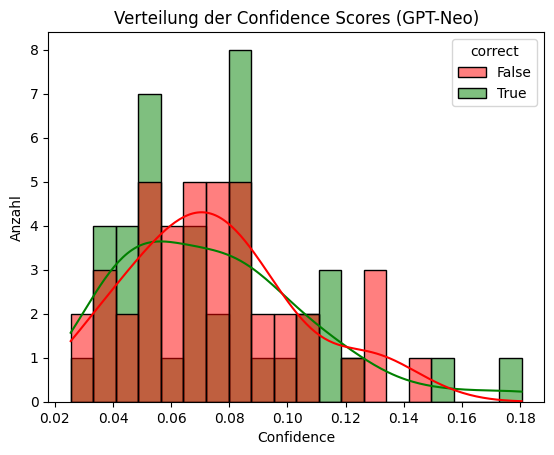

In [19]:
import seaborn as sns
import matplotlib.pyplot as plt
df["label_true"] = df["label"].apply(map_label)
df["correct"] = df["label_true"] == df["label_finetuned-deepseek-healtcare_subjects"]

sns.histplot(data=df, x="confidence_finetuned-deepseek-healtcare_subjects", hue="correct", bins=20, kde=True, palette=["red", "green"])
plt.title("Verteilung der Confidence Scores (GPT-Neo)")
plt.xlabel("Confidence")
plt.ylabel("Anzahl")
plt.show()

#### Test Subjects

In [1]:
import torch
import os
import pandas as pd
from transformers import (
    AutoTokenizer,
    AutoModelForCausalLM,
    AutoModelForSeq2SeqLM,
    RobertaTokenizer,
    RobertaForSequenceClassification,
)
import torch.nn.functional as F
from tqdm import tqdm  # für Ladebalken

# CUDA Device
os.environ["CUDA_VISIBLE_DEVICES"] = "5"  # anpassen falls nötig
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Prompt-Template mit Statement + Subjects
def build_prompt(statement, subjects):
    return (
        f"Statement: {statement}\n"
        f"Task: Decide if the statement is factually correct. For better context, consider the subjects: {subjects}.\n"
        f"Answer only with True or False.\n"
        f"Example:\n"
        f"Statement: The sky is green.\n"
        f"Subjects: Weather, Nature\n"
        f"Answer: False\n"
        f"Statement: {statement}\n"
        f"Answer:"
    )

# Modelle
models = {
    "../models/finetuned-deepseek-healtcare_subjects": "causal",
    # weitere Modelle können ergänzt werden
}

# Daten laden
df = pd.read_csv(r"../own_datasets/preprocessed_test_cleaned.csv", sep="\t")
df = df.iloc[:2000].copy()

statements = df["statement"].tolist()
subjects = df["subjects"].tolist()

# Ergebnisse speichern
results = {name: [] for name in models}
confidences = {name: [] for name in models}  # für Confidence Score

# Modelle durchlaufen
for model_name, model_type in models.items():
    print(f"Lade Modell: {model_name} ({model_type})")

    if model_type == "causal":
        tokenizer = AutoTokenizer.from_pretrained(model_name, use_fast=True)
        model = AutoModelForCausalLM.from_pretrained(model_name).to(device)
        model.eval()

        # Tokens mit führendem Leerzeichen, wichtig!
        true_token_id = tokenizer(" True", add_special_tokens=False)["input_ids"][0]
        false_token_id = tokenizer(" False", add_special_tokens=False)["input_ids"][0]

        # tqdm Ladebalken für Fortschritt
        for text, subj in tqdm(zip(statements, subjects), total=len(statements), desc="Processing causal model"):
            prompt = build_prompt(text, subj)
            inputs = tokenizer(prompt, return_tensors="pt", truncation=True).to(device)
            with torch.no_grad():
                outputs = model(**inputs)
                logits = outputs.logits
                next_token_logits = logits[0, -1, :]
                probs = F.softmax(next_token_logits, dim=-1)

            prob_true = probs[true_token_id].item()
            prob_false = probs[false_token_id].item()

            if prob_true > prob_false:
                result = "True"
                confidence = prob_true
            else:
                result = "False"
                confidence = prob_false

            results[model_name].append(result)
            confidences[model_name].append(confidence)

# Ergebnisse im DataFrame speichern
for model_name in results:
    suffix = model_name.split("/")[-1]
    df[f"label_{suffix}"] = results[model_name]
    # Nur für causal Modell Confidence speichern
    if model_name in confidences:
        df[f"confidence_{suffix}"] = confidences[model_name]

# Ausgabe DataFrame (z.B. df.head())
df.head


2025-07-26 06:45:53.634773: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1753505153.656313   40627 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1753505153.663282   40627 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1753505153.680868   40627 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1753505153.680892   40627 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1753505153.680894   40627 computation_placer.cc:177] computation placer alr

Lade Modell: ../models/finetuned-deepseek-healtcare_subjects (causal)


Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

Processing causal model: 100%|██████████| 1267/1267 [02:39<00:00,  7.93it/s]


<bound method NDFrame.head of             label                                          statement  \
0            true  Building a wall on the U.S . Mexico border wil...   
1           false  Wisconsin is on pace to double the number of l...   
2           false  Says John McCain has done nothing to help the ...   
3       half-true  Suzanne Bonamici supports a plan that will cut...   
4      pants-fire  When asked by a reporter whether hes at the ce...   
...           ...                                                ...   
1262    half-true  Says his budget provides the highest state fun...   
1263  barely-true                   Ive been here almost every day .   
1264  barely-true  In the early 1980s Sen . Edward Kennedy secret...   
1265  barely-true  Says an EPA permit languished under Strickland...   
1266        false  Says the governor is going around the state ta...   

                                               subjects  \
0                                           im

In [2]:
import pandas as pd
from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
)

# Definiere deine Labelgruppen
true_labels = ["true", "mostly-true", "half-true"]
false_labels = ["barely-true", "false", "pants-fire", "pants-on-fire"]

# Mapping-Funktion: Normalisiert die Labels zu "True" oder "False"
def map_label(label):
    label = str(label).strip().lower()
    if label in true_labels:
        return "True"
    elif label in false_labels:
        return "False"
    else:
        return "False"  # Default für unbekannte Labels

# Wandle Ground Truth und Prediction in binäre Kategorien um
y_true = df["label"].apply(map_label)
y_pred = df["label_finetuned-deepseek-healtcare_subjects"].apply(lambda x: map_label(x))

# Konfusionsmatrix
cm = confusion_matrix(y_true, y_pred, labels=["True", "False"])
print("Confusion Matrix (True/False):")
print(cm)

print(f"\nAccuracy:  {accuracy_score(y_true, y_pred)}")
print(f"Precision: {precision_score(y_true, y_pred, pos_label='True')}  (bezogen auf 'True')")
print(f"Recall:    {recall_score(y_true, y_pred, pos_label='True')}  (bezogen auf 'True')")
print(f"F1 Score:  {f1_score(y_true, y_pred, pos_label='True')}  (bezogen auf 'True')")

# Optionaler vollständiger Bericht
print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=["True", "False"]))


Confusion Matrix (True/False):
[[580 134]
 [451 102]]

Accuracy:  0.5382794001578532
Precision: 0.562560620756547  (bezogen auf 'True')
Recall:    0.8123249299719888  (bezogen auf 'True')
F1 Score:  0.664756446991404  (bezogen auf 'True')

Classification Report:
              precision    recall  f1-score   support

        True       0.43      0.18      0.26       553
       False       0.56      0.81      0.66       714

    accuracy                           0.54      1267
   macro avg       0.50      0.50      0.46      1267
weighted avg       0.51      0.54      0.49      1267



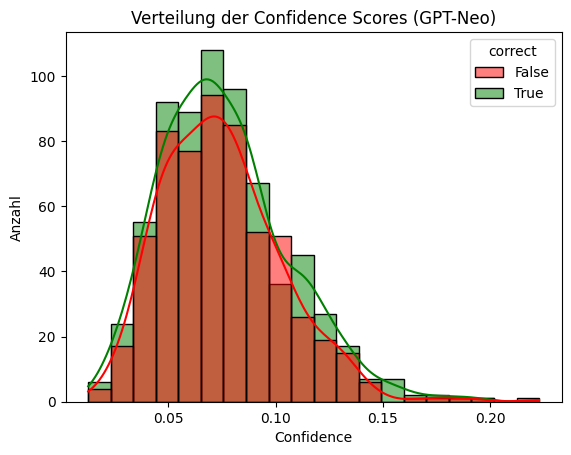

In [3]:
import seaborn as sns
import matplotlib.pyplot as plt
df["label_true"] = df["label"].apply(map_label)
df["correct"] = df["label_true"] == df["label_finetuned-deepseek-healtcare_subjects"]

sns.histplot(data=df, x="confidence_finetuned-deepseek-healtcare_subjects", hue="correct", bins=20, kde=True, palette=["red", "green"])
plt.title("Verteilung der Confidence Scores (GPT-Neo)")
plt.xlabel("Confidence")
plt.ylabel("Anzahl")
plt.show()

# Preprocessing Normal

In [3]:
import pandas as pd

columns = [
    "id", "label", "statement", "subjects", "speaker", "job_title", "state_info", "party_affiliation",
    "barely_true_counts", "false_counts", "half_true_counts", "mostly_true_counts", "pants_on_fire_counts", "context"
]

df = pd.read_csv("Datasets/LIAR/train.tsv", sep="\t", names=columns, header=None)
df.drop(columns=["id", "barely_true_counts", "false_counts", "half_true_counts", "mostly_true_counts", "pants_on_fire_counts", "job_title", "state_info", "party_affiliation", "context", "speaker"], inplace=True)
df.to_csv("Datasets/LIAR/train_cleaned.csv", index=False)
df

,label,statement,subjects
0,false,Says the Annies List political group supports ...,abortion
1,half-true,When did the decline of coal start? It started...,"energy,history,job-accomplishments"
2,mostly-true,"Hillary Clinton agrees with John McCain ""by vo...",foreign-policy
3,false,Health care reform legislation is likely to ma...,health-care
4,half-true,The economic turnaround started at the end of ...,"economy,jobs"
...,...,...,...
10235,mostly-true,There are a larger number of shark attacks in ...,"animals,elections"
10236,mostly-true,Democrats have now become the party of the [At...,elections
10237,half-true,Says an alternative to Social Security that op...,"retirement,social-security"
10238,false,On lifting the U.S. Cuban embargo and allowing...,"florida,foreign-policy"


In [2]:
import re

# Muster für die Textbereinigung
sent_patt = re.compile(r'(?<!\.|\!|\?|\:|\;|\s)\w[.,:;!?]\s+')
multi_sym = re.compile(r'[!.,?=-]{2,}')
time = re.compile(r'([0-2][0-9]:[0-5][0-9]([pm]|[am])*)|([0-2]*[0-9]*:*[0-5][0-9]([pm]|[am])+)|([0-9][0-9]*([pm]|[am])+)')
date = re.compile(r'([0-3]*[0-9]\/[0-9]*\/[0-9]+)')


def remove_emojis(text):
    """
    Entfernt Emojis aus einem gegebenen Text.

    Args:
        text (str): Der zu verarbeitende Text.

    Returns:
        str: Der Text ohne Emojis.
    """
    emoji_pattern = re.compile(
        r"[" 
        u"\U0001F600-\U0001F64F"  # Emoticons
        u"\U0001F300-\U0001F5FF"  # Symbole & Piktogramme
        u"\U0001F680-\U0001F6FF"  # Transport & Karten
        u"\U0001F1E0-\U0001F1FF"  # Flaggen (iOS)
        u"\U00002702-\U000027B0"  # Weitere Symbole
        u"\U000024C2-\U0001F251"  # Diverse Zeichen
        u"\U0000200D"             # Zero Width Joiner
        u"\U0001F926-\U0001F937"  # Gesten
        u"\U00010000-\U0010FFFF"  # Andere Zeichen (Plane 1+)
        u"\u200d"                 # Zero Width Joiner
        u"\u2640-\u2642"          # Geschlechterzeichen
        u"\u2600-\u2B55"          # Diverse Symbole
        u"\u23cf"                 # Eject-Button
        u"\u23e9"                 # Weitere Buttons
        u"\u231a"                 # Uhr
        u"\u3030"                 # Wellenlinie
        u"\ufe0f"                 # Variation Selector
        u"\u2069"                 # Pop Directional Isolate
        u"\u2066"                 # Isolates
        u"\u200c"                 # Zero Width Non-Joiner
        u"\u25aa"                 # Kleine schwarze Quadrate
        u"\u25ab"                 # Kleine weiße Quadrate
        "]+",
        flags=re.UNICODE
    )
    return emoji_pattern.sub(r'', text)

def clean_tweets(df):
    """
    Bereinigt Tweets in einem DataFrame, indem unerwünschte Zeichen, Links, Hashtags, Benutzerkonten und Emojis entfernt werden.

    Args:
        df (DataFrame): Ein DataFrame, der die Tweets enthält.

    Returns:
        DataFrame: Der bereinigte DataFrame.
    """
    for idx in range(len(df)):
        tweet = df.iloc[idx]['statement']
        
        tweet = " " + tweet + " "
        
        tweet = tweet.replace("\n", " ").replace("\"", "").replace(",", "").replace("!", "").replace("?", "").replace("“", "").replace("„", "").replace("”", "").replace("|", " ").replace("`", " ").replace("'", " ").replace(":_", " ").replace("_", " ").replace(" rt ", " retweet ").replace(" mrs. ", " mrs ").replace(" ms. ", " ms ").replace(" mr. ", " mr ").replace(" dr. ", " dr ").replace(" prof. ", " prof ").replace(" dr.-ing. ", " dr.-ing ")  
        tweet = re.sub(r'http\S+', ' hrefl ', tweet)  # links
        tweet = re.sub(r'#\S+', '', tweet)  # hashtag
        tweet = re.sub(r'@\S+', ' usacc ', tweet)  # useraccount
        tweet = remove_emojis(tweet)  # Emojis entfernen
        
        all_sym = multi_sym.finditer(tweet)
        all_time = time.finditer(tweet)
        all_date = date.finditer(tweet)
        
        for m in all_sym:
            tweet = tweet.replace(m.group(), ' ' + m.group()[0] + ' ', 1)
        for m in all_time:
            tweet = tweet.replace(m.group(), ' tiform ', 1)
        for m in all_date:
            tweet = tweet.replace(m.group(), ' dtform ', 1)
        tweet = " " + tweet + " "
        all_pts = sent_patt.finditer(tweet)
        for m in all_pts:
            tweet = tweet.replace(m.group(), m.group()[0] + ' ' + m.group()[1] + ' ', 1)
        
        tweet = re.sub(r"\s\s+", " ", tweet)
        df.iloc[idx, df.columns.get_loc('statement')] = tweet.strip()
    return df

In [4]:
import pandas as pd
df = pd.read_csv(r'Datasets/LIAR/train_cleaned.csv')

df = clean_tweets(df)
df.to_csv(r'preprocessed_train_cleaned.csv', sep='\t', index=False)

In [5]:
import pandas as pd
import json

# CSV laden
df = pd.read_csv("preprocessed_train_cleaned.csv", sep="\t")

# Mapping der Labels in "True"/"False"
label_map = {
    "true": "True",
    "mostly-true": "True",
    "half-true": "True",
    "barely-true": "False",
    "false": "False",
    "pants-fire": "False"
}

# Prompt-Template-Funktion
def create_prompt(statement, label):
    return {
        "text": (
            f"Statement: {statement}\n"
            f"Task: Determine whether the statement is factually correct or fake news. "
            f"Use only publicly verifiable and objective facts. Do not guess.\n"
            f"Answer with only one word: True or False.\n"
            f"Answer: {label}"
        )
    }

# Prompt-Daten erstellen
jsonl_data = []
for _, row in df.iterrows():
    raw_label = row["label"].strip().lower()
    mapped_label = label_map.get(raw_label)

    if mapped_label:  # Nur verarbeitbare Labels
        prompt = create_prompt(row["statement"], mapped_label)
        jsonl_data.append(prompt)

# Als JSONL-Datei speichern
with open("fine_tune_data_general.jsonl", "w", encoding="utf-8") as f:
    for entry in jsonl_data:
        f.write(json.dumps(entry, ensure_ascii=False) + "\n")

print(f"✅ {len(jsonl_data)} Beispiele gespeichert in 'fine_tune_data.jsonl'")


✅ 10240 Beispiele gespeichert in 'fine_tune_data.jsonl'


In [7]:
import pandas as pd
import json

# CSV laden
df = pd.read_csv("preprocessed_train_cleaned.csv", sep="\t")

# Label-Mapping in "True"/"False"
label_map = {
    "true": "True",
    "mostly-true": "True",
    "half-true": "True",
    "barely-true": "False",
    "false": "False",
    "pants-fire": "False"
}

# Prompt-Template mit Subjects und Beispiel
def create_prompt(statement, label, subjects):
    formatted_subjects = ", ".join([s.strip().title() for s in str(subjects).split(",")])
    return {
        "text": (
            f"Statement: {statement}\n"
            f"Task: Decide if the statement is factually correct. For better context, consider the subjects: {formatted_subjects}.\n"
            f"Answer only with True or False.\n"
            f"Example:\n"
            f"Statement: The sky is green.\n"
            f"Subjects: Weather, Nature\n"
            f"Answer: False\n"
            f"Statement: {statement}\n"
            f"Answer: {label}"
        )
    }

# Prompt-Daten erstellen
jsonl_data = []
for _, row in df.iterrows():
    raw_label = str(row["label"]).strip().lower()
    mapped_label = label_map.get(raw_label)

    if mapped_label:
        prompt = create_prompt(row["statement"], mapped_label, row["subjects"])
        jsonl_data.append(prompt)

# Als JSONL-Datei speichern
with open("fine_tune_data_general_subjects.jsonl", "w", encoding="utf-8") as f:
    for entry in jsonl_data:
        f.write(json.dumps(entry, ensure_ascii=False) + "\n")

print(f"✅ {len(jsonl_data)} Prompts gespeichert in 'fine_tune_data_subjects.jsonl'")


✅ 10240 Prompts gespeichert in 'fine_tune_data_subjects.jsonl'


# Feintuning - Normal

## Llama - Normal

In [9]:
from transformers import AutoTokenizer, AutoModelForCausalLM, TrainingArguments, Trainer, DataCollatorForLanguageModeling
from datasets import load_dataset, Dataset
from peft import get_peft_model, LoraConfig, TaskType
import torch
import os 

os.environ["CUDA_VISIBLE_DEVICES"] = "2,3"  # anpassen falls nötig
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model_name = "meta-llama/Llama-3.1-8B-Instruct"
tokenizer = AutoTokenizer.from_pretrained(model_name, use_fast=True)
tokenizer.pad_token = tokenizer.eos_token  # Wichtig für CausalLM

# Beispiel-Daten laden (hier: lokal aus JSONL-Datei)
dataset = load_dataset("json", data_files={"train": "fine_tune_data_general.jsonl"})["train"]

# Tokenisierung
def tokenize(example):
    return tokenizer(example["text"], truncation=True, padding="max_length", max_length=512)

tokenized_dataset = dataset.map(tokenize, batched=True)

# Modell mit LoRA initialisieren
base_model = AutoModelForCausalLM.from_pretrained(model_name, device_map="auto", torch_dtype=torch.float16)

peft_config = LoraConfig(
    r=8,
    lora_alpha=32,
    target_modules=["q_proj", "v_proj"],  # hängt vom Modell ab
    lora_dropout=0.05,
    bias="none",
    task_type=TaskType.CAUSAL_LM
)

model = get_peft_model(base_model, peft_config)

# Trainingskonfiguration
training_args = TrainingArguments(
    output_dir="./results",
    per_device_train_batch_size=2,
    gradient_accumulation_steps=4,
    num_train_epochs=3,
    logging_dir="./logs",
    save_total_limit=2,
    fp16=True,
    optim="adamw_torch",
    logging_steps=10,
    save_steps=100,
    learning_rate=2e-5,
    report_to="none",
    max_steps=1000
)

data_collator = DataCollatorForLanguageModeling(tokenizer, mlm=False)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_dataset,
    tokenizer=tokenizer,
    data_collator=data_collator,
)

trainer.train()


Loading checkpoint shards:   0%|          | 0/4 [00:00<?, ?it/s]

/tmp/ipykernel_12288/2687525771.py:56: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(
No label_names provided for model class `PeftModelForCausalLM`. Since `PeftModel` hides base models input arguments, if label_names is not given, label_names can't be set automatically within `Trainer`. Note that empty label_names list will be used instead.


Step,Training Loss
10,3.104100
20,2.887400
30,2.670400
40,2.339400
50,2.039600
60,1.631600
70,1.350800
80,1.321900
90,1.270400
100,1.258800


/home/jovyan/.local/lib/python3.10/site-packages/peft/utils/other.py:1221: UserWarning: Unable to fetch remote file due to the following error 401 Client Error. (Request ID: Root=1-68733f72-79f1961d23a2ede419344777;2f04e16c-7f34-45d1-bc2a-2be962627db5)

Cannot access gated repo for url https://huggingface.co/meta-llama/Llama-3.1-8B-Instruct/resolve/main/config.json.
Access to model meta-llama/Llama-3.1-8B-Instruct is restricted. You must have access to it and be authenticated to access it. Please log in. - silently ignoring the lookup for the file config.json in meta-llama/Llama-3.1-8B-Instruct.
  warnings.warn(
/home/jovyan/.local/lib/python3.10/site-packages/peft/utils/save_and_load.py:238: UserWarning: Could not find a config file in meta-llama/Llama-3.1-8B-Instruct - will assume that the vocabulary was not modified.
  warnings.warn(
/home/jovyan/.local/lib/python3.10/site-packages/peft/utils/other.py:1221: UserWarning: Unable to fetch remote file due to the following error 401 Clie

TrainOutput(global_step=1000, training_loss=1.0850669183731079, metrics={'train_runtime': 1102.1277, 'train_samples_per_second': 7.259, 'train_steps_per_second': 0.907, 'total_flos': 1.84524780601344e+17, 'train_loss': 1.0850669183731079, 'epoch': 0.78125})

In [10]:
trainer.save_model("finetuned-llama3-general_normal")
tokenizer.save_pretrained("finetuned-llama3-general_normal")


/home/jovyan/.local/lib/python3.10/site-packages/peft/utils/other.py:1221: UserWarning: Unable to fetch remote file due to the following error 401 Client Error. (Request ID: Root=1-6873463d-1dd83a674f66f8d6375cdacb;b405db55-ceb8-436f-bdcd-fc00afdd988d)

Cannot access gated repo for url https://huggingface.co/meta-llama/Llama-3.1-8B-Instruct/resolve/main/config.json.
Access to model meta-llama/Llama-3.1-8B-Instruct is restricted. You must have access to it and be authenticated to access it. Please log in. - silently ignoring the lookup for the file config.json in meta-llama/Llama-3.1-8B-Instruct.
  warnings.warn(
/home/jovyan/.local/lib/python3.10/site-packages/peft/utils/save_and_load.py:238: UserWarning: Could not find a config file in meta-llama/Llama-3.1-8B-Instruct - will assume that the vocabulary was not modified.
  warnings.warn(


('finetuned-llama3-general_normal/tokenizer_config.json',
 'finetuned-llama3-general_normal/special_tokens_map.json',
 'finetuned-llama3-general_normal/chat_template.jinja',
 'finetuned-llama3-general_normal/tokenizer.json')

### Test Healthcare

In [1]:
import torch
import os
import pandas as pd
from transformers import (
    AutoTokenizer,
    AutoModelForCausalLM,
)
import torch.nn.functional as F
from tqdm import tqdm  # für den Ladebalken

# CUDA-Konfiguration
os.environ["CUDA_VISIBLE_DEVICES"] = "2"  # anpassen falls nötig
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Prompt-Template
def build_prompt(text):
    return (
        f"Statement: {text}\n"
        f"Task: Determine whether the statement is factually correct or fake news. Use only publicly verifiable and objective facts. Do not guess.\n"
        f"Answer with only one word: True or False.\n"
        f"Answer:"
    )

# Modell-Auswahl
models = {
    "finetuned-llama3-general_normal": "causal"
}

# Daten laden
df = pd.read_csv("healthcare_prompts_test.csv", sep=",")
df = df.iloc[:2000].copy()
statements = df["statement"].tolist()

# Ergebnis-Speicher
results = {name: [] for name in models}
confidences = {name: [] for name in models}

# Modelle durchlaufen
for model_name, model_type in models.items():
    print(f"\n📦 Lade Modell: {model_name} ({model_type})")

    tokenizer = AutoTokenizer.from_pretrained(model_name, use_fast=True)
    model = AutoModelForCausalLM.from_pretrained(model_name).to(device)
    model.eval()

    # Token IDs für " True" und " False" (mit führendem Leerzeichen!)
    true_token_id = tokenizer(" True", add_special_tokens=False)["input_ids"][0]
    false_token_id = tokenizer(" False", add_special_tokens=False)["input_ids"][0]

    # Verarbeitung mit Ladebalken
    for text in tqdm(statements, desc="🔍 Verarbeitung"):
        prompt = build_prompt(text)
        inputs = tokenizer(prompt, return_tensors="pt").to(device)

        with torch.no_grad():
            outputs = model(**inputs)
            logits = outputs.logits
            next_token_logits = logits[0, -1, :]  # nächstes Token
            probs = F.softmax(next_token_logits, dim=-1)

        # Wahrscheinlichkeiten abrufen
        prob_true = probs[true_token_id].item()
        prob_false = probs[false_token_id].item()

        if prob_true > prob_false:
            result = "True"
            confidence = prob_true
        else:
            result = "False"
            confidence = prob_false

        results[model_name].append(result)
        confidences[model_name].append(confidence)

# Ergebnisse ins DataFrame schreiben
for model_name in results:
    suffix = model_name.split("/")[-1]
    df[f"label_{suffix}"] = results[model_name]
    df[f"confidence_{suffix}"] = confidences[model_name]

# Ausgabe zur Kontrolle
print("\n✅ Verarbeitung abgeschlossen.")
df



📦 Lade Modell: finetuned-llama3-general_normal (causal)


2025-07-13 07:38:47.890232: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1752385127.913959   14281 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1752385127.919753   14281 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1752385127.934141   14281 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1752385127.934153   14281 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1752385127.934155   14281 computation_placer.cc:177] computation placer alr

Loading checkpoint shards:   0%|          | 0/4 [00:00<?, ?it/s]

🔍 Verarbeitung: 100%|██████████| 83/83 [00:08<00:00,  9.46it/s]


✅ Verarbeitung abgeschlossen.


,label,statement,subjects,label_finetuned-llama3-general_normal,confidence_finetuned-llama3-general_normal
0,true,Each year 18000 people die in America because ...,health-care,True,0.568400
1,mostly-true,Active duty males in the military are twice as...,"health-care,military",True,0.701091
2,half-true,Says Thomas Jefferson said You might be able t...,"health-care,history",False,0.611176
3,barely-true,Because of the federal health care law 300000 ...,health-care,False,0.516324
4,barely-true,Pre-existing conditions are covered under my (...,"debates,health-care",False,0.567207
...,...,...,...,...,...
78,false,We had an amendment in the health care law tha...,"education,health-care",False,0.748682
79,true,Texas has the highest rate of uninsured in the...,health-care,True,0.809289
80,true,Says 80 percent of the health care dollars are...,"health-care,public-health",True,0.701097
81,pants-fire,Says state Rep . Sandy Pasch her recall oppone...,"health-care,unions",False,0.561833


In [2]:
import pandas as pd
from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
)

# Definiere deine Labelgruppen
true_labels = ["true", "mostly-true", "half-true"]
false_labels = ["barely-true", "false", "pants-fire", "pants-on-fire"]

# Mapping-Funktion: Normalisiert die Labels zu "True" oder "False"
def map_label(label):
    label = str(label).strip().lower()
    if label in true_labels:
        return "True"
    elif label in false_labels:
        return "False"
    else:
        return "False"  # Default für unbekannte Labels

# Wandle Ground Truth und Prediction in binäre Kategorien um
y_true = df["label"].apply(map_label)
y_pred = df["label_finetuned-llama3-general_normal"].apply(lambda x: map_label(x))

# Konfusionsmatrix
cm = confusion_matrix(y_true, y_pred, labels=["True", "False"])
print("Confusion Matrix (True/False):")
print(cm)

print(f"\nAccuracy:  {accuracy_score(y_true, y_pred)}")
print(f"Precision: {precision_score(y_true, y_pred, pos_label='True')}  (bezogen auf 'True')")
print(f"Recall:    {recall_score(y_true, y_pred, pos_label='True')}  (bezogen auf 'True')")
print(f"F1 Score:  {f1_score(y_true, y_pred, pos_label='True')}  (bezogen auf 'True')")

# Optionaler vollständiger Bericht
print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=["True", "False"]))


Confusion Matrix (True/False):
[[27 15]
 [13 28]]

Accuracy:  0.6626506024096386
Precision: 0.675  (bezogen auf 'True')
Recall:    0.6428571428571429  (bezogen auf 'True')
F1 Score:  0.6585365853658537  (bezogen auf 'True')

Classification Report:
              precision    recall  f1-score   support

        True       0.65      0.68      0.67        41
       False       0.68      0.64      0.66        42

    accuracy                           0.66        83
   macro avg       0.66      0.66      0.66        83
weighted avg       0.66      0.66      0.66        83



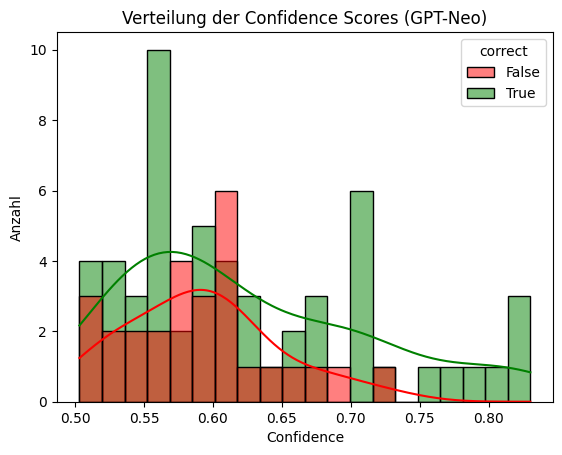

In [3]:
import seaborn as sns
import matplotlib.pyplot as plt
df["label_true"] = df["label"].apply(map_label)
df["correct"] = df["label_true"] == df["label_finetuned-llama3-general_normal"]

sns.histplot(data=df, x="confidence_finetuned-llama3-general_normal", hue="correct", bins=20, kde=True, palette=["red", "green"])
plt.title("Verteilung der Confidence Scores (GPT-Neo)")
plt.xlabel("Confidence")
plt.ylabel("Anzahl")
plt.show()

### Test Gesamt

In [1]:
import torch
import os
import pandas as pd
from transformers import (
    AutoTokenizer,
    AutoModelForCausalLM,
)
import torch.nn.functional as F
from tqdm import tqdm  # für den Ladebalken

# CUDA-Konfiguration
os.environ["CUDA_VISIBLE_DEVICES"] = "2"  # anpassen falls nötig
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Prompt-Template
def build_prompt(text):
    return (
        f"Statement: {text}\n"
        f"Task: Determine whether the statement is factually correct or fake news. Use only publicly verifiable and objective facts. Do not guess.\n"
        f"Answer with only one word: True or False.\n"
        f"Answer:"
    )

# Modell-Auswahl
models = {
    "finetuned-llama3-general_normal": "causal"
}

# Daten laden
df = pd.read_csv("preprocessed_test_cleaned.csv", sep="	")
df = df.iloc[:2000].copy()
statements = df["statement"].tolist()

# Ergebnis-Speicher
results = {name: [] for name in models}
confidences = {name: [] for name in models}

# Modelle durchlaufen
for model_name, model_type in models.items():
    print(f"\n📦 Lade Modell: {model_name} ({model_type})")

    tokenizer = AutoTokenizer.from_pretrained(model_name, use_fast=True)
    model = AutoModelForCausalLM.from_pretrained(model_name).to(device)
    model.eval()

    # Token IDs für " True" und " False" (mit führendem Leerzeichen!)
    true_token_id = tokenizer(" True", add_special_tokens=False)["input_ids"][0]
    false_token_id = tokenizer(" False", add_special_tokens=False)["input_ids"][0]

    # Verarbeitung mit Ladebalken
    for text in tqdm(statements, desc="🔍 Verarbeitung"):
        prompt = build_prompt(text)
        inputs = tokenizer(prompt, return_tensors="pt").to(device)

        with torch.no_grad():
            outputs = model(**inputs)
            logits = outputs.logits
            next_token_logits = logits[0, -1, :]  # nächstes Token
            probs = F.softmax(next_token_logits, dim=-1)

        # Wahrscheinlichkeiten abrufen
        prob_true = probs[true_token_id].item()
        prob_false = probs[false_token_id].item()

        if prob_true > prob_false:
            result = "True"
            confidence = prob_true
        else:
            result = "False"
            confidence = prob_false

        results[model_name].append(result)
        confidences[model_name].append(confidence)

# Ergebnisse ins DataFrame schreiben
for model_name in results:
    suffix = model_name.split("/")[-1]
    df[f"label_{suffix}"] = results[model_name]
    df[f"confidence_{suffix}"] = confidences[model_name]

# Ausgabe zur Kontrolle
print("\n✅ Verarbeitung abgeschlossen.")
df



📦 Lade Modell: finetuned-llama3-general_normal (causal)


2025-07-13 07:39:58.264218: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1752385198.289114   14573 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1752385198.293884   14573 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1752385198.313629   14573 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1752385198.313656   14573 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1752385198.313659   14573 computation_placer.cc:177] computation placer alr

Loading checkpoint shards:   0%|          | 0/4 [00:00<?, ?it/s]

🔍 Verarbeitung: 100%|██████████| 1267/1267 [02:11<00:00,  9.65it/s]


✅ Verarbeitung abgeschlossen.


,label,statement,subjects,label_finetuned-llama3-general_normal,confidence_finetuned-llama3-general_normal
0,true,Building a wall on the U.S . Mexico border wil...,immigration,True,0.503273
1,false,Wisconsin is on pace to double the number of l...,jobs,True,0.518579
2,false,Says John McCain has done nothing to help the ...,"military,veterans,voting-record",False,0.613087
3,half-true,Suzanne Bonamici supports a plan that will cut...,"medicare,message-machine-2012,campaign-adverti...",False,0.652925
4,pants-fire,When asked by a reporter whether hes at the ce...,"campaign-finance,legal-issues,campaign-adverti...",True,0.674425
...,...,...,...,...,...
1262,half-true,Says his budget provides the highest state fun...,education,True,0.647828
1263,barely-true,Ive been here almost every day .,"civil-rights,crime,criminal-justice",True,0.534752
1264,barely-true,In the early 1980s Sen . Edward Kennedy secret...,"bipartisanship,congress,foreign-policy,history",True,0.502127
1265,barely-true,Says an EPA permit languished under Strickland...,"environment,government-efficiency",True,0.550851


In [2]:
import pandas as pd
from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
)

# Definiere deine Labelgruppen
true_labels = ["true", "mostly-true", "half-true"]
false_labels = ["barely-true", "false", "pants-fire", "pants-on-fire"]

# Mapping-Funktion: Normalisiert die Labels zu "True" oder "False"
def map_label(label):
    label = str(label).strip().lower()
    if label in true_labels:
        return "True"
    elif label in false_labels:
        return "False"
    else:
        return "False"  # Default für unbekannte Labels

# Wandle Ground Truth und Prediction in binäre Kategorien um
y_true = df["label"].apply(map_label)
y_pred = df["label_finetuned-llama3-general_normal"].apply(lambda x: map_label(x))

# Konfusionsmatrix
cm = confusion_matrix(y_true, y_pred, labels=["True", "False"])
print("Confusion Matrix (True/False):")
print(cm)

print(f"\nAccuracy:  {accuracy_score(y_true, y_pred)}")
print(f"Precision: {precision_score(y_true, y_pred, pos_label='True')}  (bezogen auf 'True')")
print(f"Recall:    {recall_score(y_true, y_pred, pos_label='True')}  (bezogen auf 'True')")
print(f"F1 Score:  {f1_score(y_true, y_pred, pos_label='True')}  (bezogen auf 'True')")

# Optionaler vollständiger Bericht
print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=["True", "False"]))


Confusion Matrix (True/False):
[[531 183]
 [278 275]]

Accuracy:  0.6361483820047356
Precision: 0.6563658838071693  (bezogen auf 'True')
Recall:    0.7436974789915967  (bezogen auf 'True')
F1 Score:  0.6973079448456992  (bezogen auf 'True')

Classification Report:
              precision    recall  f1-score   support

        True       0.60      0.50      0.54       553
       False       0.66      0.74      0.70       714

    accuracy                           0.64      1267
   macro avg       0.63      0.62      0.62      1267
weighted avg       0.63      0.64      0.63      1267



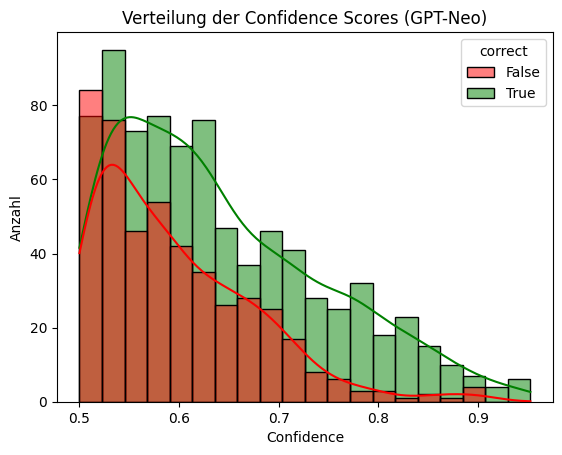

In [3]:
import seaborn as sns
import matplotlib.pyplot as plt
df["label_true"] = df["label"].apply(map_label)
df["correct"] = df["label_true"] == df["label_finetuned-llama3-general_normal"]

sns.histplot(data=df, x="confidence_finetuned-llama3-general_normal", hue="correct", bins=20, kde=True, palette=["red", "green"])
plt.title("Verteilung der Confidence Scores (GPT-Neo)")
plt.xlabel("Confidence")
plt.ylabel("Anzahl")
plt.show()

## Llama - Subjects

In [1]:
from transformers import AutoTokenizer, AutoModelForCausalLM, TrainingArguments, Trainer, DataCollatorForLanguageModeling
from datasets import load_dataset, Dataset
from peft import get_peft_model, LoraConfig, TaskType
import torch
import os 

os.environ["CUDA_VISIBLE_DEVICES"] = "2,3"  # anpassen falls nötig
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model_name = "meta-llama/Llama-3.1-8B-Instruct"
tokenizer = AutoTokenizer.from_pretrained(model_name, use_fast=True)
tokenizer.pad_token = tokenizer.eos_token  # Wichtig für CausalLM

# Beispiel-Daten laden (hier: lokal aus JSONL-Datei)
dataset = load_dataset("json", data_files={"train": "fine_tune_data_general_subjects.jsonl"})["train"]

# Tokenisierung
def tokenize(example):
    return tokenizer(example["text"], truncation=True, padding="max_length", max_length=512)

tokenized_dataset = dataset.map(tokenize, batched=True)

# Modell mit LoRA initialisieren
base_model = AutoModelForCausalLM.from_pretrained(model_name, device_map="auto", torch_dtype=torch.float16)

peft_config = LoraConfig(
    r=8,
    lora_alpha=32,
    target_modules=["q_proj", "v_proj"],  # hängt vom Modell ab
    lora_dropout=0.05,
    bias="none",
    task_type=TaskType.CAUSAL_LM
)

model = get_peft_model(base_model, peft_config)

# Trainingskonfiguration
training_args = TrainingArguments(
    output_dir="./results",
    per_device_train_batch_size=2,
    gradient_accumulation_steps=4,
    num_train_epochs=3,
    logging_dir="./logs",
    save_total_limit=2,
    fp16=True,
    optim="adamw_torch",
    logging_steps=10,
    save_steps=100,
    learning_rate=2e-5,
    report_to="none",
    max_steps=1000
)

data_collator = DataCollatorForLanguageModeling(tokenizer, mlm=False)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_dataset,
    tokenizer=tokenizer,
    data_collator=data_collator,
)

trainer.train()


2025-07-13 08:36:39.403047: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1752388599.426594   17240 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1752388599.433142   17240 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1752388599.452494   17240 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1752388599.452825   17240 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1752388599.452831   17240 computation_placer.cc:177] computation placer alr

Loading checkpoint shards:   0%|          | 0/4 [00:00<?, ?it/s]

/tmp/ipykernel_17240/4227325102.py:56: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(
No label_names provided for model class `PeftModelForCausalLM`. Since `PeftModel` hides base models input arguments, if label_names is not given, label_names can't be set automatically within `Trainer`. Note that empty label_names list will be used instead.


Step,Training Loss
10,2.618400
20,2.427800
30,2.232600
40,1.930800
50,1.686200
60,1.435100
70,1.181900
80,1.060900
90,0.993700
100,0.940700


/home/jovyan/.local/lib/python3.10/site-packages/peft/utils/other.py:1221: UserWarning: Unable to fetch remote file due to the following error 401 Client Error. (Request ID: Root=1-68735472-6bdae3235ee7c142173dd370;67962188-8cbb-4e35-ba8d-f419df5e6ac7)

Cannot access gated repo for url https://huggingface.co/meta-llama/Llama-3.1-8B-Instruct/resolve/main/config.json.
Access to model meta-llama/Llama-3.1-8B-Instruct is restricted. You must have access to it and be authenticated to access it. Please log in. - silently ignoring the lookup for the file config.json in meta-llama/Llama-3.1-8B-Instruct.
  warnings.warn(
/home/jovyan/.local/lib/python3.10/site-packages/peft/utils/save_and_load.py:238: UserWarning: Could not find a config file in meta-llama/Llama-3.1-8B-Instruct - will assume that the vocabulary was not modified.
  warnings.warn(
/home/jovyan/.local/lib/python3.10/site-packages/peft/utils/other.py:1221: UserWarning: Unable to fetch remote file due to the following error 401 Clie

TrainOutput(global_step=1000, training_loss=0.802669898033142, metrics={'train_runtime': 1102.5735, 'train_samples_per_second': 7.256, 'train_steps_per_second': 0.907, 'total_flos': 1.84524780601344e+17, 'train_loss': 0.802669898033142, 'epoch': 0.78125})

In [2]:
trainer.save_model("finetuned-llama3-general_subjects")
tokenizer.save_pretrained("finetuned-llama3-general_subjects")

/home/jovyan/.local/lib/python3.10/site-packages/peft/utils/other.py:1221: UserWarning: Unable to fetch remote file due to the following error 401 Client Error. (Request ID: Root=1-68735864-707166e42edbddc134aecc55;cdfb2fef-d27e-4c5f-948d-6755916e27b7)

Cannot access gated repo for url https://huggingface.co/meta-llama/Llama-3.1-8B-Instruct/resolve/main/config.json.
Access to model meta-llama/Llama-3.1-8B-Instruct is restricted. You must have access to it and be authenticated to access it. Please log in. - silently ignoring the lookup for the file config.json in meta-llama/Llama-3.1-8B-Instruct.
  warnings.warn(
/home/jovyan/.local/lib/python3.10/site-packages/peft/utils/save_and_load.py:238: UserWarning: Could not find a config file in meta-llama/Llama-3.1-8B-Instruct - will assume that the vocabulary was not modified.
  warnings.warn(


('finetuned-llama3-general_subjects/tokenizer_config.json',
 'finetuned-llama3-general_subjects/special_tokens_map.json',
 'finetuned-llama3-general_subjects/chat_template.jinja',
 'finetuned-llama3-general_subjects/tokenizer.json')

### Test Healthcare

In [3]:
import torch
import os
import pandas as pd
from transformers import (
    AutoTokenizer,
    AutoModelForCausalLM,
    AutoModelForSeq2SeqLM,
    RobertaTokenizer,
    RobertaForSequenceClassification,
)
import torch.nn.functional as F
from tqdm import tqdm  # für Ladebalken

# CUDA Device
os.environ["CUDA_VISIBLE_DEVICES"] = "5"  # anpassen falls nötig
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Prompt-Template mit Statement + Subjects
def build_prompt(statement, subjects):
    return (
        f"Statement: {statement}\n"
        f"Task: Decide if the statement is factually correct. For better context, consider the subjects: {subjects}.\n"
        f"Answer only with True or False.\n"
        f"Example:\n"
        f"Statement: The sky is green.\n"
        f"Subjects: Weather, Nature\n"
        f"Answer: False\n"
        f"Statement: {statement}\n"
        f"Answer:"
    )

# Modelle
models = {
    "finetuned-llama3-general_subjects": "causal",
    # weitere Modelle können ergänzt werden
}

# Daten laden
df = pd.read_csv(r"healthcare_prompts_test.csv", sep=",")
df = df.iloc[:2000].copy()

statements = df["statement"].tolist()
subjects = df["subjects"].tolist()

# Ergebnisse speichern
results = {name: [] for name in models}
confidences = {name: [] for name in models}  # für Confidence Score

# Modelle durchlaufen
for model_name, model_type in models.items():
    print(f"Lade Modell: {model_name} ({model_type})")

    if model_type == "causal":
        tokenizer = AutoTokenizer.from_pretrained(model_name, use_fast=True)
        model = AutoModelForCausalLM.from_pretrained(model_name).to(device)
        model.eval()

        # Tokens mit führendem Leerzeichen, wichtig!
        true_token_id = tokenizer(" True", add_special_tokens=False)["input_ids"][0]
        false_token_id = tokenizer(" False", add_special_tokens=False)["input_ids"][0]

        # tqdm Ladebalken für Fortschritt
        for text, subj in tqdm(zip(statements, subjects), total=len(statements), desc="Processing causal model"):
            prompt = build_prompt(text, subj)
            inputs = tokenizer(prompt, return_tensors="pt", truncation=True).to(device)
            with torch.no_grad():
                outputs = model(**inputs)
                logits = outputs.logits
                next_token_logits = logits[0, -1, :]
                probs = F.softmax(next_token_logits, dim=-1)

            prob_true = probs[true_token_id].item()
            prob_false = probs[false_token_id].item()

            if prob_true > prob_false:
                result = "True"
                confidence = prob_true
            else:
                result = "False"
                confidence = prob_false

            results[model_name].append(result)
            confidences[model_name].append(confidence)

# Ergebnisse im DataFrame speichern
for model_name in results:
    suffix = model_name.split("/")[-1]
    df[f"label_{suffix}"] = results[model_name]
    # Nur für causal Modell Confidence speichern
    if model_name in confidences:
        df[f"confidence_{suffix}"] = confidences[model_name]

# Ausgabe DataFrame (z.B. df.head())
df.head


Lade Modell: finetuned-llama3-general_subjects (causal)


Loading checkpoint shards:   0%|          | 0/4 [00:00<?, ?it/s]

Processing causal model: 100%|██████████| 83/83 [00:12<00:00,  6.86it/s]


<bound method NDFrame.head of           label                                          statement  \
0          true  Each year 18000 people die in America because ...   
1   mostly-true  Active duty males in the military are twice as...   
2     half-true  Says Thomas Jefferson said You might be able t...   
3   barely-true  Because of the federal health care law 300000 ...   
4   barely-true  Pre-existing conditions are covered under my (...   
..          ...                                                ...   
78        false  We had an amendment in the health care law tha...   
79         true  Texas has the highest rate of uninsured in the...   
80         true  Says 80 percent of the health care dollars are...   
81   pants-fire  Says state Rep . Sandy Pasch her recall oppone...   
82    half-true  Says Mark Pryorcut Medicare to pay for Obamaca...   

                     subjects label_finetuned-llama3-general_subjects  \
0                 health-care                           

In [4]:
import pandas as pd
from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
)

# Definiere deine Labelgruppen
true_labels = ["true", "mostly-true", "half-true"]
false_labels = ["barely-true", "false", "pants-fire", "pants-on-fire"]

# Mapping-Funktion: Normalisiert die Labels zu "True" oder "False"
def map_label(label):
    label = str(label).strip().lower()
    if label in true_labels:
        return "True"
    elif label in false_labels:
        return "False"
    else:
        return "False"  # Default für unbekannte Labels

# Wandle Ground Truth und Prediction in binäre Kategorien um
y_true = df["label"].apply(map_label)
y_pred = df["label_finetuned-llama3-general_subjects"].apply(lambda x: map_label(x))

# Konfusionsmatrix
cm = confusion_matrix(y_true, y_pred, labels=["True", "False"])
print("Confusion Matrix (True/False):")
print(cm)

print(f"\nAccuracy:  {accuracy_score(y_true, y_pred)}")
print(f"Precision: {precision_score(y_true, y_pred, pos_label='True')}  (bezogen auf 'True')")
print(f"Recall:    {recall_score(y_true, y_pred, pos_label='True')}  (bezogen auf 'True')")
print(f"F1 Score:  {f1_score(y_true, y_pred, pos_label='True')}  (bezogen auf 'True')")

# Optionaler vollständiger Bericht
print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=["True", "False"]))


Confusion Matrix (True/False):
[[28 14]
 [12 29]]

Accuracy:  0.6867469879518072
Precision: 0.7  (bezogen auf 'True')
Recall:    0.6666666666666666  (bezogen auf 'True')
F1 Score:  0.6829268292682927  (bezogen auf 'True')

Classification Report:
              precision    recall  f1-score   support

        True       0.67      0.71      0.69        41
       False       0.70      0.67      0.68        42

    accuracy                           0.69        83
   macro avg       0.69      0.69      0.69        83
weighted avg       0.69      0.69      0.69        83



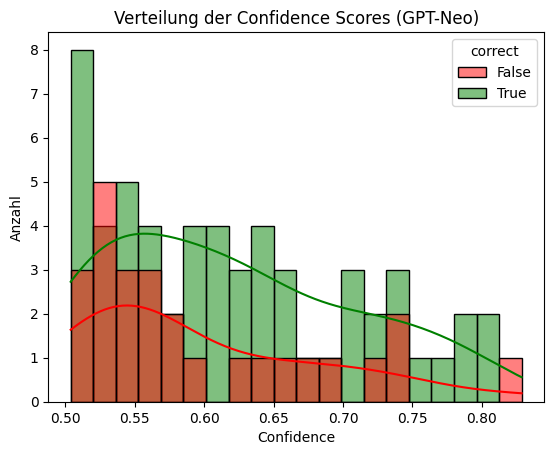

In [5]:
import seaborn as sns
import matplotlib.pyplot as plt
df["label_true"] = df["label"].apply(map_label)
df["correct"] = df["label_true"] == df["label_finetuned-llama3-general_subjects"]

sns.histplot(data=df, x="confidence_finetuned-llama3-general_subjects", hue="correct", bins=20, kde=True, palette=["red", "green"])
plt.title("Verteilung der Confidence Scores (GPT-Neo)")
plt.xlabel("Confidence")
plt.ylabel("Anzahl")
plt.show()

### Test Gesamt 

In [1]:
import torch
import os
import pandas as pd
from transformers import (
    AutoTokenizer,
    AutoModelForCausalLM,
    AutoModelForSeq2SeqLM,
    RobertaTokenizer,
    RobertaForSequenceClassification,
)
import torch.nn.functional as F
from tqdm import tqdm  # für Ladebalken

# CUDA Device
os.environ["CUDA_VISIBLE_DEVICES"] = "5"  # anpassen falls nötig
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Prompt-Template mit Statement + Subjects
def build_prompt(statement, subjects):
    return (
        f"Statement: {statement}\n"
        f"Task: Decide if the statement is factually correct. For better context, consider the subjects: {subjects}.\n"
        f"Answer only with True or False.\n"
        f"Example:\n"
        f"Statement: The sky is green.\n"
        f"Subjects: Weather, Nature\n"
        f"Answer: False\n"
        f"Statement: {statement}\n"
        f"Answer:"
    )

# Modelle
models = {
    "finetuned-llama3-general_subjects": "causal",
    # weitere Modelle können ergänzt werden
}

# Daten laden
df = pd.read_csv(r"preprocessed_test_cleaned.csv", sep="\t")
df = df.iloc[:2000].copy()

statements = df["statement"].tolist()
subjects = df["subjects"].tolist()

# Ergebnisse speichern
results = {name: [] for name in models}
confidences = {name: [] for name in models}  # für Confidence Score

# Modelle durchlaufen
for model_name, model_type in models.items():
    print(f"Lade Modell: {model_name} ({model_type})")

    if model_type == "causal":
        tokenizer = AutoTokenizer.from_pretrained(model_name, use_fast=True)
        model = AutoModelForCausalLM.from_pretrained(model_name).to(device)
        model.eval()

        # Tokens mit führendem Leerzeichen, wichtig!
        true_token_id = tokenizer(" True", add_special_tokens=False)["input_ids"][0]
        false_token_id = tokenizer(" False", add_special_tokens=False)["input_ids"][0]

        # tqdm Ladebalken für Fortschritt
        for text, subj in tqdm(zip(statements, subjects), total=len(statements), desc="Processing causal model"):
            prompt = build_prompt(text, subj)
            inputs = tokenizer(prompt, return_tensors="pt", truncation=True).to(device)
            with torch.no_grad():
                outputs = model(**inputs)
                logits = outputs.logits
                next_token_logits = logits[0, -1, :]
                probs = F.softmax(next_token_logits, dim=-1)

            prob_true = probs[true_token_id].item()
            prob_false = probs[false_token_id].item()

            if prob_true > prob_false:
                result = "True"
                confidence = prob_true
            else:
                result = "False"
                confidence = prob_false

            results[model_name].append(result)
            confidences[model_name].append(confidence)

# Ergebnisse im DataFrame speichern
for model_name in results:
    suffix = model_name.split("/")[-1]
    df[f"label_{suffix}"] = results[model_name]
    # Nur für causal Modell Confidence speichern
    if model_name in confidences:
        df[f"confidence_{suffix}"] = confidences[model_name]

# Ausgabe DataFrame (z.B. df.head())
df.head


2025-07-13 08:56:45.907210: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1752389805.929074   17828 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1752389805.935862   17828 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1752389805.954867   17828 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1752389805.954896   17828 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1752389805.954899   17828 computation_placer.cc:177] computation placer alr

Lade Modell: finetuned-llama3-general_subjects (causal)


Loading checkpoint shards:   0%|          | 0/4 [00:00<?, ?it/s]

Processing causal model: 100%|██████████| 1267/1267 [03:01<00:00,  6.98it/s]


<bound method NDFrame.head of             label                                          statement  \
0            true  Building a wall on the U.S . Mexico border wil...   
1           false  Wisconsin is on pace to double the number of l...   
2           false  Says John McCain has done nothing to help the ...   
3       half-true  Suzanne Bonamici supports a plan that will cut...   
4      pants-fire  When asked by a reporter whether hes at the ce...   
...           ...                                                ...   
1262    half-true  Says his budget provides the highest state fun...   
1263  barely-true                   Ive been here almost every day .   
1264  barely-true  In the early 1980s Sen . Edward Kennedy secret...   
1265  barely-true  Says an EPA permit languished under Strickland...   
1266        false  Says the governor is going around the state ta...   

                                               subjects  \
0                                           im

In [2]:
import pandas as pd
from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
)

# Definiere deine Labelgruppen
true_labels = ["true", "mostly-true", "half-true"]
false_labels = ["barely-true", "false", "pants-fire", "pants-on-fire"]

# Mapping-Funktion: Normalisiert die Labels zu "True" oder "False"
def map_label(label):
    label = str(label).strip().lower()
    if label in true_labels:
        return "True"
    elif label in false_labels:
        return "False"
    else:
        return "False"  # Default für unbekannte Labels

# Wandle Ground Truth und Prediction in binäre Kategorien um
y_true = df["label"].apply(map_label)
y_pred = df["label_finetuned-llama3-general_subjects"].apply(lambda x: map_label(x))

# Konfusionsmatrix
cm = confusion_matrix(y_true, y_pred, labels=["True", "False"])
print("Confusion Matrix (True/False):")
print(cm)

print(f"\nAccuracy:  {accuracy_score(y_true, y_pred)}")
print(f"Precision: {precision_score(y_true, y_pred, pos_label='True')}  (bezogen auf 'True')")
print(f"Recall:    {recall_score(y_true, y_pred, pos_label='True')}  (bezogen auf 'True')")
print(f"F1 Score:  {f1_score(y_true, y_pred, pos_label='True')}  (bezogen auf 'True')")

# Optionaler vollständiger Bericht
print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=["True", "False"]))


Confusion Matrix (True/False):
[[549 165]
 [285 268]]

Accuracy:  0.6448303078137332
Precision: 0.658273381294964  (bezogen auf 'True')
Recall:    0.7689075630252101  (bezogen auf 'True')
F1 Score:  0.7093023255813954  (bezogen auf 'True')

Classification Report:
              precision    recall  f1-score   support

        True       0.62      0.48      0.54       553
       False       0.66      0.77      0.71       714

    accuracy                           0.64      1267
   macro avg       0.64      0.63      0.63      1267
weighted avg       0.64      0.64      0.64      1267



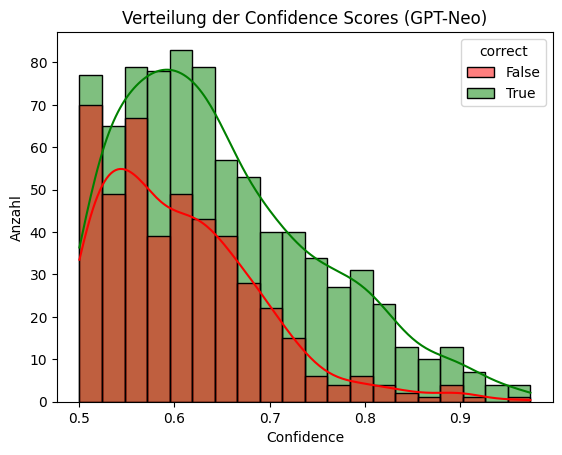

In [3]:
import seaborn as sns
import matplotlib.pyplot as plt
df["label_true"] = df["label"].apply(map_label)
df["correct"] = df["label_true"] == df["label_finetuned-llama3-general_subjects"]

sns.histplot(data=df, x="confidence_finetuned-llama3-general_subjects", hue="correct", bins=20, kde=True, palette=["red", "green"])
plt.title("Verteilung der Confidence Scores (GPT-Neo)")
plt.xlabel("Confidence")
plt.ylabel("Anzahl")
plt.show()

## Deepseek - Normal

In [1]:
from transformers import AutoTokenizer, AutoModelForCausalLM, TrainingArguments, Trainer, DataCollatorForLanguageModeling
from datasets import load_dataset, Dataset
from peft import get_peft_model, LoraConfig, TaskType
import torch
import os 

os.environ["CUDA_VISIBLE_DEVICES"] = "2,3"  # anpassen falls nötig
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model_name = "deepseek-ai/deepseek-llm-7b-base"
tokenizer = AutoTokenizer.from_pretrained(model_name, use_fast=True)
tokenizer.pad_token = tokenizer.eos_token  # Wichtig für CausalLM

# Beispiel-Daten laden (hier: lokal aus JSONL-Datei)
dataset = load_dataset("json", data_files={"train": "fine_tune_data_general.jsonl"})["train"]

# Tokenisierung
def tokenize(example):
    return tokenizer(example["text"], truncation=True, padding="max_length", max_length=512)

tokenized_dataset = dataset.map(tokenize, batched=True)

# Modell mit LoRA initialisieren
base_model = AutoModelForCausalLM.from_pretrained(model_name, device_map="auto", torch_dtype=torch.float16)

peft_config = LoraConfig(
    r=8,
    lora_alpha=32,
    target_modules=["q_proj", "v_proj"],  # hängt vom Modell ab
    lora_dropout=0.05,
    bias="none",
    task_type=TaskType.CAUSAL_LM
)

model = get_peft_model(base_model, peft_config)

# Trainingskonfiguration
training_args = TrainingArguments(
    output_dir="./results",
    per_device_train_batch_size=2,
    gradient_accumulation_steps=4,
    num_train_epochs=3,
    logging_dir="./logs",
    save_total_limit=2,
    fp16=True,
    optim="adamw_torch",
    logging_steps=10,
    save_steps=100,
    learning_rate=2e-5,
    report_to="none",
    max_steps=1000
)

data_collator = DataCollatorForLanguageModeling(tokenizer, mlm=False)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_dataset,
    tokenizer=tokenizer,
    data_collator=data_collator,
)

trainer.train()


2025-07-13 09:00:30.373454: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1752390030.399210   18161 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1752390030.406523   18161 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1752390030.425932   18161 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1752390030.425957   18161 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1752390030.425959   18161 computation_placer.cc:177] computation placer alr

Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

/tmp/ipykernel_18161/4231234209.py:56: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(
No label_names provided for model class `PeftModelForCausalLM`. Since `PeftModel` hides base models input arguments, if label_names is not given, label_names can't be set automatically within `Trainer`. Note that empty label_names list will be used instead.


Step,Training Loss
10,2.987900
20,2.880700
30,2.812100
40,2.652100
50,2.495100
60,2.231700
70,1.953600
80,1.688100
90,1.462400
100,1.312900


TrainOutput(global_step=1000, training_loss=1.0379086389541625, metrics={'train_runtime': 980.0741, 'train_samples_per_second': 8.163, 'train_steps_per_second': 1.02, 'total_flos': 1.59617862598656e+17, 'train_loss': 1.0379086389541625, 'epoch': 0.78125})

In [2]:
trainer.save_model("finetuned-deepseek-general_normal")
tokenizer.save_pretrained("finetuned-deepseek-general_normal")


('finetuned-deepseek-general_normal/tokenizer_config.json',
 'finetuned-deepseek-general_normal/special_tokens_map.json',
 'finetuned-deepseek-general_normal/tokenizer.json')

### Test Healthcare

In [3]:
import torch
import os
import pandas as pd
from transformers import (
    AutoTokenizer,
    AutoModelForCausalLM,
)
import torch.nn.functional as F
from tqdm import tqdm  # für den Ladebalken

# CUDA-Konfiguration
os.environ["CUDA_VISIBLE_DEVICES"] = "2"  # anpassen falls nötig
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Prompt-Template
def build_prompt(text):
    return (
        f"Statement: {text}\n"
        f"Task: Determine whether the statement is factually correct or fake news. Use only publicly verifiable and objective facts. Do not guess.\n"
        f"Answer with only one word: True or False.\n"
        f"Answer:"
    )

# Modell-Auswahl
models = {
    "finetuned-deepseek-general_normal": "causal"
}

# Daten laden
df = pd.read_csv("healthcare_prompts_test.csv", sep=",")
df = df.iloc[:2000].copy()
statements = df["statement"].tolist()

# Ergebnis-Speicher
results = {name: [] for name in models}
confidences = {name: [] for name in models}

# Modelle durchlaufen
for model_name, model_type in models.items():
    print(f"\n📦 Lade Modell: {model_name} ({model_type})")

    tokenizer = AutoTokenizer.from_pretrained(model_name, use_fast=True)
    model = AutoModelForCausalLM.from_pretrained(model_name).to(device)
    model.eval()

    # Token IDs für " True" und " False" (mit führendem Leerzeichen!)
    true_token_id = tokenizer(" True", add_special_tokens=False)["input_ids"][0]
    false_token_id = tokenizer(" False", add_special_tokens=False)["input_ids"][0]

    # Verarbeitung mit Ladebalken
    for text in tqdm(statements, desc="🔍 Verarbeitung"):
        prompt = build_prompt(text)
        inputs = tokenizer(prompt, return_tensors="pt").to(device)

        with torch.no_grad():
            outputs = model(**inputs)
            logits = outputs.logits
            next_token_logits = logits[0, -1, :]  # nächstes Token
            probs = F.softmax(next_token_logits, dim=-1)

        # Wahrscheinlichkeiten abrufen
        prob_true = probs[true_token_id].item()
        prob_false = probs[false_token_id].item()

        if prob_true > prob_false:
            result = "True"
            confidence = prob_true
        else:
            result = "False"
            confidence = prob_false

        results[model_name].append(result)
        confidences[model_name].append(confidence)

# Ergebnisse ins DataFrame schreiben
for model_name in results:
    suffix = model_name.split("/")[-1]
    df[f"label_{suffix}"] = results[model_name]
    df[f"confidence_{suffix}"] = confidences[model_name]

# Ausgabe zur Kontrolle
print("\n✅ Verarbeitung abgeschlossen.")
df



📦 Lade Modell: finetuned-deepseek-general_normal (causal)


Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

🔍 Verarbeitung: 100%|██████████| 83/83 [00:07<00:00, 11.05it/s]


✅ Verarbeitung abgeschlossen.


,label,statement,subjects,label_finetuned-deepseek-general_normal,confidence_finetuned-deepseek-general_normal
0,true,Each year 18000 people die in America because ...,health-care,True,0.600059
1,mostly-true,Active duty males in the military are twice as...,"health-care,military",True,0.610589
2,half-true,Says Thomas Jefferson said You might be able t...,"health-care,history",True,0.754732
3,barely-true,Because of the federal health care law 300000 ...,health-care,True,0.575478
4,barely-true,Pre-existing conditions are covered under my (...,"debates,health-care",True,0.729937
...,...,...,...,...,...
78,false,We had an amendment in the health care law tha...,"education,health-care",False,0.583446
79,true,Texas has the highest rate of uninsured in the...,health-care,True,0.624003
80,true,Says 80 percent of the health care dollars are...,"health-care,public-health",True,0.732039
81,pants-fire,Says state Rep . Sandy Pasch her recall oppone...,"health-care,unions",False,0.634916


In [4]:
import pandas as pd
from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
)

# Definiere deine Labelgruppen
true_labels = ["true", "mostly-true", "half-true"]
false_labels = ["barely-true", "false", "pants-fire", "pants-on-fire"]

# Mapping-Funktion: Normalisiert die Labels zu "True" oder "False"
def map_label(label):
    label = str(label).strip().lower()
    if label in true_labels:
        return "True"
    elif label in false_labels:
        return "False"
    else:
        return "False"  # Default für unbekannte Labels

# Wandle Ground Truth und Prediction in binäre Kategorien um
y_true = df["label"].apply(map_label)
y_pred = df["label_finetuned-deepseek-general_normal"].apply(lambda x: map_label(x))

# Konfusionsmatrix
cm = confusion_matrix(y_true, y_pred, labels=["True", "False"])
print("Confusion Matrix (True/False):")
print(cm)

print(f"\nAccuracy:  {accuracy_score(y_true, y_pred)}")
print(f"Precision: {precision_score(y_true, y_pred, pos_label='True')}  (bezogen auf 'True')")
print(f"Recall:    {recall_score(y_true, y_pred, pos_label='True')}  (bezogen auf 'True')")
print(f"F1 Score:  {f1_score(y_true, y_pred, pos_label='True')}  (bezogen auf 'True')")

# Optionaler vollständiger Bericht
print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=["True", "False"]))


Confusion Matrix (True/False):
[[31 11]
 [17 24]]

Accuracy:  0.6626506024096386
Precision: 0.6458333333333334  (bezogen auf 'True')
Recall:    0.7380952380952381  (bezogen auf 'True')
F1 Score:  0.6888888888888889  (bezogen auf 'True')

Classification Report:
              precision    recall  f1-score   support

        True       0.69      0.59      0.63        41
       False       0.65      0.74      0.69        42

    accuracy                           0.66        83
   macro avg       0.67      0.66      0.66        83
weighted avg       0.67      0.66      0.66        83



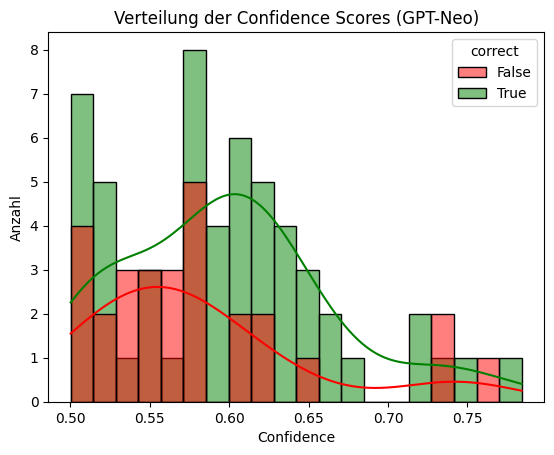

In [5]:
import seaborn as sns
import matplotlib.pyplot as plt
df["label_true"] = df["label"].apply(map_label)
df["correct"] = df["label_true"] == df["label_finetuned-deepseek-general_normal"]

sns.histplot(data=df, x="confidence_finetuned-deepseek-general_normal", hue="correct", bins=20, kde=True, palette=["red", "green"])
plt.title("Verteilung der Confidence Scores (GPT-Neo)")
plt.xlabel("Confidence")
plt.ylabel("Anzahl")
plt.show()

### Test Gesamt

In [1]:
import torch
import os
import pandas as pd
from transformers import (
    AutoTokenizer,
    AutoModelForCausalLM,
)
import torch.nn.functional as F
from tqdm import tqdm  # für den Ladebalken

# CUDA-Konfiguration
os.environ["CUDA_VISIBLE_DEVICES"] = "2"  # anpassen falls nötig
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Prompt-Template
def build_prompt(text):
    return (
        f"Statement: {text}\n"
        f"Task: Determine whether the statement is factually correct or fake news. Use only publicly verifiable and objective facts. Do not guess.\n"
        f"Answer with only one word: True or False.\n"
        f"Answer:"
    )

# Modell-Auswahl
models = {
    "finetuned-deepseek-general_normal": "causal"
}

# Daten laden
df = pd.read_csv("preprocessed_test_cleaned.csv", sep="	")
df = df.iloc[:2000].copy()
statements = df["statement"].tolist()

# Ergebnis-Speicher
results = {name: [] for name in models}
confidences = {name: [] for name in models}

# Modelle durchlaufen
for model_name, model_type in models.items():
    print(f"\n📦 Lade Modell: {model_name} ({model_type})")

    tokenizer = AutoTokenizer.from_pretrained(model_name, use_fast=True)
    model = AutoModelForCausalLM.from_pretrained(model_name).to(device)
    model.eval()

    # Token IDs für " True" und " False" (mit führendem Leerzeichen!)
    true_token_id = tokenizer(" True", add_special_tokens=False)["input_ids"][0]
    false_token_id = tokenizer(" False", add_special_tokens=False)["input_ids"][0]

    # Verarbeitung mit Ladebalken
    for text in tqdm(statements, desc="🔍 Verarbeitung"):
        prompt = build_prompt(text)
        inputs = tokenizer(prompt, return_tensors="pt").to(device)

        with torch.no_grad():
            outputs = model(**inputs)
            logits = outputs.logits
            next_token_logits = logits[0, -1, :]  # nächstes Token
            probs = F.softmax(next_token_logits, dim=-1)

        # Wahrscheinlichkeiten abrufen
        prob_true = probs[true_token_id].item()
        prob_false = probs[false_token_id].item()

        if prob_true > prob_false:
            result = "True"
            confidence = prob_true
        else:
            result = "False"
            confidence = prob_false

        results[model_name].append(result)
        confidences[model_name].append(confidence)

# Ergebnisse ins DataFrame schreiben
for model_name in results:
    suffix = model_name.split("/")[-1]
    df[f"label_{suffix}"] = results[model_name]
    df[f"confidence_{suffix}"] = confidences[model_name]

# Ausgabe zur Kontrolle
print("\n✅ Verarbeitung abgeschlossen.")
df



📦 Lade Modell: finetuned-deepseek-general_normal (causal)


2025-07-13 09:18:16.921693: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1752391096.941447   18716 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1752391096.947404   18716 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1752391096.966259   18716 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1752391096.966272   18716 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1752391096.966275   18716 computation_placer.cc:177] computation placer alr

Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

🔍 Verarbeitung: 100%|██████████| 1267/1267 [01:54<00:00, 11.09it/s]


✅ Verarbeitung abgeschlossen.


,label,statement,subjects,label_finetuned-deepseek-general_normal,confidence_finetuned-deepseek-general_normal
0,true,Building a wall on the U.S . Mexico border wil...,immigration,True,0.629011
1,false,Wisconsin is on pace to double the number of l...,jobs,False,0.542535
2,false,Says John McCain has done nothing to help the ...,"military,veterans,voting-record",False,0.774110
3,half-true,Suzanne Bonamici supports a plan that will cut...,"medicare,message-machine-2012,campaign-adverti...",False,0.529358
4,pants-fire,When asked by a reporter whether hes at the ce...,"campaign-finance,legal-issues,campaign-adverti...",False,0.565553
...,...,...,...,...,...
1262,half-true,Says his budget provides the highest state fun...,education,True,0.624852
1263,barely-true,Ive been here almost every day .,"civil-rights,crime,criminal-justice",True,0.546939
1264,barely-true,In the early 1980s Sen . Edward Kennedy secret...,"bipartisanship,congress,foreign-policy,history",True,0.544443
1265,barely-true,Says an EPA permit languished under Strickland...,"environment,government-efficiency",False,0.513395


In [2]:
import pandas as pd
from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
)

# Definiere deine Labelgruppen
true_labels = ["true", "mostly-true", "half-true"]
false_labels = ["barely-true", "false", "pants-fire", "pants-on-fire"]

# Mapping-Funktion: Normalisiert die Labels zu "True" oder "False"
def map_label(label):
    label = str(label).strip().lower()
    if label in true_labels:
        return "True"
    elif label in false_labels:
        return "False"
    else:
        return "False"  # Default für unbekannte Labels

# Wandle Ground Truth und Prediction in binäre Kategorien um
y_true = df["label"].apply(map_label)
y_pred = df["label_finetuned-deepseek-general_normal"].apply(lambda x: map_label(x))

# Konfusionsmatrix
cm = confusion_matrix(y_true, y_pred, labels=["True", "False"])
print("Confusion Matrix (True/False):")
print(cm)

print(f"\nAccuracy:  {accuracy_score(y_true, y_pred)}")
print(f"Precision: {precision_score(y_true, y_pred, pos_label='True')}  (bezogen auf 'True')")
print(f"Recall:    {recall_score(y_true, y_pred, pos_label='True')}  (bezogen auf 'True')")
print(f"F1 Score:  {f1_score(y_true, y_pred, pos_label='True')}  (bezogen auf 'True')")

# Optionaler vollständiger Bericht
print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=["True", "False"]))


Confusion Matrix (True/False):
[[512 202]
 [274 279]]

Accuracy:  0.6243093922651933
Precision: 0.6513994910941476  (bezogen auf 'True')
Recall:    0.7170868347338936  (bezogen auf 'True')
F1 Score:  0.6826666666666666  (bezogen auf 'True')

Classification Report:
              precision    recall  f1-score   support

        True       0.58      0.50      0.54       553
       False       0.65      0.72      0.68       714

    accuracy                           0.62      1267
   macro avg       0.62      0.61      0.61      1267
weighted avg       0.62      0.62      0.62      1267



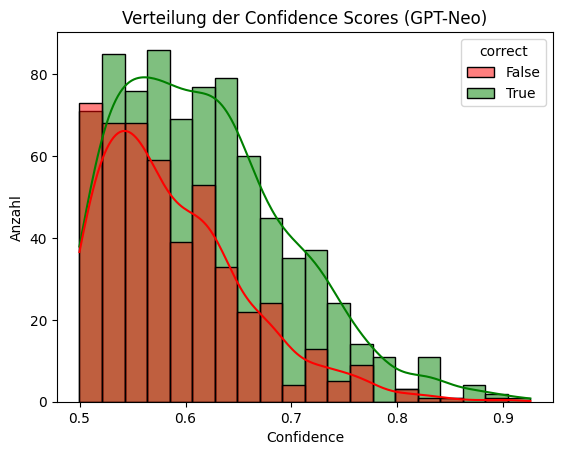

In [3]:
import seaborn as sns
import matplotlib.pyplot as plt
df["label_true"] = df["label"].apply(map_label)
df["correct"] = df["label_true"] == df["label_finetuned-deepseek-general_normal"]

sns.histplot(data=df, x="confidence_finetuned-deepseek-general_normal", hue="correct", bins=20, kde=True, palette=["red", "green"])
plt.title("Verteilung der Confidence Scores (GPT-Neo)")
plt.xlabel("Confidence")
plt.ylabel("Anzahl")
plt.show()

## Deepseek - Subjects

In [1]:
from transformers import AutoTokenizer, AutoModelForCausalLM, TrainingArguments, Trainer, DataCollatorForLanguageModeling
from datasets import load_dataset, Dataset
from peft import get_peft_model, LoraConfig, TaskType
import torch
import os 

os.environ["CUDA_VISIBLE_DEVICES"] = "2,3"  # anpassen falls nötig
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model_name = "deepseek-ai/deepseek-llm-7b-base"
tokenizer = AutoTokenizer.from_pretrained(model_name, use_fast=True)
tokenizer.pad_token = tokenizer.eos_token  # Wichtig für CausalLM

# Beispiel-Daten laden (hier: lokal aus JSONL-Datei)
dataset = load_dataset("json", data_files={"train": "fine_tune_data_general_subjects.jsonl"})["train"]

# Tokenisierung
def tokenize(example):
    return tokenizer(example["text"], truncation=True, padding="max_length", max_length=512)

tokenized_dataset = dataset.map(tokenize, batched=True)

# Modell mit LoRA initialisieren
base_model = AutoModelForCausalLM.from_pretrained(model_name, device_map="auto", torch_dtype=torch.float16)

peft_config = LoraConfig(
    r=8,
    lora_alpha=32,
    target_modules=["q_proj", "v_proj"],  # hängt vom Modell ab
    lora_dropout=0.05,
    bias="none",
    task_type=TaskType.CAUSAL_LM
)

model = get_peft_model(base_model, peft_config)

# Trainingskonfiguration
training_args = TrainingArguments(
    output_dir="./results",
    per_device_train_batch_size=2,
    gradient_accumulation_steps=4,
    num_train_epochs=3,
    logging_dir="./logs",
    save_total_limit=2,
    fp16=True,
    optim="adamw_torch",
    logging_steps=10,
    save_steps=100,
    learning_rate=2e-5,
    report_to="none",
    max_steps=1000
)

data_collator = DataCollatorForLanguageModeling(tokenizer, mlm=False)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_dataset,
    tokenizer=tokenizer,
    data_collator=data_collator,
)

trainer.train()


2025-07-13 09:21:03.295630: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1752391263.322272   19039 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1752391263.329229   19039 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1752391263.348072   19039 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1752391263.348091   19039 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1752391263.348094   19039 computation_placer.cc:177] computation placer alr

Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

/tmp/ipykernel_19039/2295467362.py:56: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(
No label_names provided for model class `PeftModelForCausalLM`. Since `PeftModel` hides base models input arguments, if label_names is not given, label_names can't be set automatically within `Trainer`. Note that empty label_names list will be used instead.


Step,Training Loss
10,2.388500
20,2.304600
30,2.243300
40,2.071800
50,1.891000
60,1.641300
70,1.425400
80,1.265700
90,1.116600
100,0.971500


TrainOutput(global_step=1000, training_loss=0.7414885368347168, metrics={'train_runtime': 981.1006, 'train_samples_per_second': 8.154, 'train_steps_per_second': 1.019, 'total_flos': 1.59617862598656e+17, 'train_loss': 0.7414885368347168, 'epoch': 0.78125})

In [2]:
trainer.save_model("finetuned-deepseek-subjects_normal")
tokenizer.save_pretrained("finetuned-deepseek-subjects_normal")


('finetuned-deepseek-subjects_normal/tokenizer_config.json',
 'finetuned-deepseek-subjects_normal/special_tokens_map.json',
 'finetuned-deepseek-subjects_normal/tokenizer.json')

### Test Healthcare

In [3]:
import torch
import os
import pandas as pd
from transformers import (
    AutoTokenizer,
    AutoModelForCausalLM,
    AutoModelForSeq2SeqLM,
    RobertaTokenizer,
    RobertaForSequenceClassification,
)
import torch.nn.functional as F
from tqdm import tqdm  # für Ladebalken

# CUDA Device
os.environ["CUDA_VISIBLE_DEVICES"] = "5"  # anpassen falls nötig
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Prompt-Template mit Statement + Subjects
def build_prompt(statement, subjects):
    return (
        f"Statement: {statement}\n"
        f"Task: Decide if the statement is factually correct. For better context, consider the subjects: {subjects}.\n"
        f"Answer only with True or False.\n"
        f"Example:\n"
        f"Statement: The sky is green.\n"
        f"Subjects: Weather, Nature\n"
        f"Answer: False\n"
        f"Statement: {statement}\n"
        f"Answer:"
    )

# Modelle
models = {
    "finetuned-deepseek-subjects_normal": "causal",
    # weitere Modelle können ergänzt werden
}

# Daten laden
df = pd.read_csv(r"healthcare_prompts_test.csv", sep=",")
df = df.iloc[:2000].copy()

statements = df["statement"].tolist()
subjects = df["subjects"].tolist()

# Ergebnisse speichern
results = {name: [] for name in models}
confidences = {name: [] for name in models}  # für Confidence Score

# Modelle durchlaufen
for model_name, model_type in models.items():
    print(f"Lade Modell: {model_name} ({model_type})")

    if model_type == "causal":
        tokenizer = AutoTokenizer.from_pretrained(model_name, use_fast=True)
        model = AutoModelForCausalLM.from_pretrained(model_name).to(device)
        model.eval()

        # Tokens mit führendem Leerzeichen, wichtig!
        true_token_id = tokenizer(" True", add_special_tokens=False)["input_ids"][0]
        false_token_id = tokenizer(" False", add_special_tokens=False)["input_ids"][0]

        # tqdm Ladebalken für Fortschritt
        for text, subj in tqdm(zip(statements, subjects), total=len(statements), desc="Processing causal model"):
            prompt = build_prompt(text, subj)
            inputs = tokenizer(prompt, return_tensors="pt", truncation=True).to(device)
            with torch.no_grad():
                outputs = model(**inputs)
                logits = outputs.logits
                next_token_logits = logits[0, -1, :]
                probs = F.softmax(next_token_logits, dim=-1)

            prob_true = probs[true_token_id].item()
            prob_false = probs[false_token_id].item()

            if prob_true > prob_false:
                result = "True"
                confidence = prob_true
            else:
                result = "False"
                confidence = prob_false

            results[model_name].append(result)
            confidences[model_name].append(confidence)

# Ergebnisse im DataFrame speichern
for model_name in results:
    suffix = model_name.split("/")[-1]
    df[f"label_{suffix}"] = results[model_name]
    # Nur für causal Modell Confidence speichern
    if model_name in confidences:
        df[f"confidence_{suffix}"] = confidences[model_name]

# Ausgabe DataFrame (z.B. df.head())
df.head


Lade Modell: finetuned-deepseek-subjects_normal (causal)


Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

Processing causal model: 100%|██████████| 83/83 [00:10<00:00,  7.75it/s]


<bound method NDFrame.head of           label                                          statement  \
0          true  Each year 18000 people die in America because ...   
1   mostly-true  Active duty males in the military are twice as...   
2     half-true  Says Thomas Jefferson said You might be able t...   
3   barely-true  Because of the federal health care law 300000 ...   
4   barely-true  Pre-existing conditions are covered under my (...   
..          ...                                                ...   
78        false  We had an amendment in the health care law tha...   
79         true  Texas has the highest rate of uninsured in the...   
80         true  Says 80 percent of the health care dollars are...   
81   pants-fire  Says state Rep . Sandy Pasch her recall oppone...   
82    half-true  Says Mark Pryorcut Medicare to pay for Obamaca...   

                     subjects label_finetuned-deepseek-subjects_normal  \
0                 health-care                          

In [4]:
import pandas as pd
from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
)

# Definiere deine Labelgruppen
true_labels = ["true", "mostly-true", "half-true"]
false_labels = ["barely-true", "false", "pants-fire", "pants-on-fire"]

# Mapping-Funktion: Normalisiert die Labels zu "True" oder "False"
def map_label(label):
    label = str(label).strip().lower()
    if label in true_labels:
        return "True"
    elif label in false_labels:
        return "False"
    else:
        return "False"  # Default für unbekannte Labels

# Wandle Ground Truth und Prediction in binäre Kategorien um
y_true = df["label"].apply(map_label)
y_pred = df["label_finetuned-deepseek-subjects_normal"].apply(lambda x: map_label(x))

# Konfusionsmatrix
cm = confusion_matrix(y_true, y_pred, labels=["True", "False"])
print("Confusion Matrix (True/False):")
print(cm)

print(f"\nAccuracy:  {accuracy_score(y_true, y_pred)}")
print(f"Precision: {precision_score(y_true, y_pred, pos_label='True')}  (bezogen auf 'True')")
print(f"Recall:    {recall_score(y_true, y_pred, pos_label='True')}  (bezogen auf 'True')")
print(f"F1 Score:  {f1_score(y_true, y_pred, pos_label='True')}  (bezogen auf 'True')")

# Optionaler vollständiger Bericht
print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=["True", "False"]))


Confusion Matrix (True/False):
[[33  9]
 [22 19]]

Accuracy:  0.6265060240963856
Precision: 0.6  (bezogen auf 'True')
Recall:    0.7857142857142857  (bezogen auf 'True')
F1 Score:  0.6804123711340206  (bezogen auf 'True')

Classification Report:
              precision    recall  f1-score   support

        True       0.68      0.46      0.55        41
       False       0.60      0.79      0.68        42

    accuracy                           0.63        83
   macro avg       0.64      0.62      0.62        83
weighted avg       0.64      0.63      0.62        83



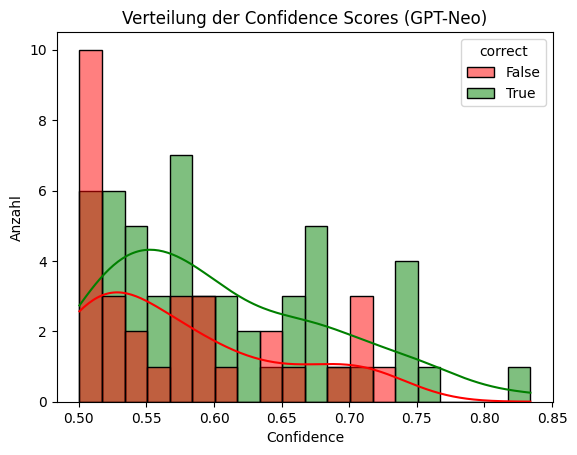

In [5]:
import seaborn as sns
import matplotlib.pyplot as plt
df["label_true"] = df["label"].apply(map_label)
df["correct"] = df["label_true"] == df["label_finetuned-deepseek-subjects_normal"]

sns.histplot(data=df, x="confidence_finetuned-deepseek-subjects_normal", hue="correct", bins=20, kde=True, palette=["red", "green"])
plt.title("Verteilung der Confidence Scores (GPT-Neo)")
plt.xlabel("Confidence")
plt.ylabel("Anzahl")
plt.show()

### Test Subjects

In [1]:
import torch
import os
import pandas as pd
from transformers import (
    AutoTokenizer,
    AutoModelForCausalLM,
    AutoModelForSeq2SeqLM,
    RobertaTokenizer,
    RobertaForSequenceClassification,
)
import torch.nn.functional as F
from tqdm import tqdm  # für Ladebalken

# CUDA Device
os.environ["CUDA_VISIBLE_DEVICES"] = "5"  # anpassen falls nötig
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Prompt-Template mit Statement + Subjects
def build_prompt(statement, subjects):
    return (
        f"Statement: {statement}\n"
        f"Task: Decide if the statement is factually correct. For better context, consider the subjects: {subjects}.\n"
        f"Answer only with True or False.\n"
        f"Example:\n"
        f"Statement: The sky is green.\n"
        f"Subjects: Weather, Nature\n"
        f"Answer: False\n"
        f"Statement: {statement}\n"
        f"Answer:"
    )

# Modelle
models = {
    "finetuned-deepseek-subjects_normal": "causal",
    # weitere Modelle können ergänzt werden
}

# Daten laden
df = pd.read_csv(r"preprocessed_test_cleaned.csv", sep="\t")
df = df.iloc[:2000].copy()

statements = df["statement"].tolist()
subjects = df["subjects"].tolist()

# Ergebnisse speichern
results = {name: [] for name in models}
confidences = {name: [] for name in models}  # für Confidence Score

# Modelle durchlaufen
for model_name, model_type in models.items():
    print(f"Lade Modell: {model_name} ({model_type})")

    if model_type == "causal":
        tokenizer = AutoTokenizer.from_pretrained(model_name, use_fast=True)
        model = AutoModelForCausalLM.from_pretrained(model_name).to(device)
        model.eval()

        # Tokens mit führendem Leerzeichen, wichtig!
        true_token_id = tokenizer(" True", add_special_tokens=False)["input_ids"][0]
        false_token_id = tokenizer(" False", add_special_tokens=False)["input_ids"][0]

        # tqdm Ladebalken für Fortschritt
        for text, subj in tqdm(zip(statements, subjects), total=len(statements), desc="Processing causal model"):
            prompt = build_prompt(text, subj)
            inputs = tokenizer(prompt, return_tensors="pt", truncation=True).to(device)
            with torch.no_grad():
                outputs = model(**inputs)
                logits = outputs.logits
                next_token_logits = logits[0, -1, :]
                probs = F.softmax(next_token_logits, dim=-1)

            prob_true = probs[true_token_id].item()
            prob_false = probs[false_token_id].item()

            if prob_true > prob_false:
                result = "True"
                confidence = prob_true
            else:
                result = "False"
                confidence = prob_false

            results[model_name].append(result)
            confidences[model_name].append(confidence)

# Ergebnisse im DataFrame speichern
for model_name in results:
    suffix = model_name.split("/")[-1]
    df[f"label_{suffix}"] = results[model_name]
    # Nur für causal Modell Confidence speichern
    if model_name in confidences:
        df[f"confidence_{suffix}"] = confidences[model_name]

# Ausgabe DataFrame (z.B. df.head())
df.head


2025-07-13 09:38:36.494454: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1752392316.516607   19656 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1752392316.523120   19656 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1752392316.540720   19656 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1752392316.540743   19656 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1752392316.540745   19656 computation_placer.cc:177] computation placer alr

Lade Modell: finetuned-deepseek-subjects_normal (causal)


Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

Processing causal model: 100%|██████████| 1267/1267 [02:40<00:00,  7.87it/s]


<bound method NDFrame.head of             label                                          statement  \
0            true  Building a wall on the U.S . Mexico border wil...   
1           false  Wisconsin is on pace to double the number of l...   
2           false  Says John McCain has done nothing to help the ...   
3       half-true  Suzanne Bonamici supports a plan that will cut...   
4      pants-fire  When asked by a reporter whether hes at the ce...   
...           ...                                                ...   
1262    half-true  Says his budget provides the highest state fun...   
1263  barely-true                   Ive been here almost every day .   
1264  barely-true  In the early 1980s Sen . Edward Kennedy secret...   
1265  barely-true  Says an EPA permit languished under Strickland...   
1266        false  Says the governor is going around the state ta...   

                                               subjects  \
0                                           im

In [2]:
import pandas as pd
from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
)

# Definiere deine Labelgruppen
true_labels = ["true", "mostly-true", "half-true"]
false_labels = ["barely-true", "false", "pants-fire", "pants-on-fire"]

# Mapping-Funktion: Normalisiert die Labels zu "True" oder "False"
def map_label(label):
    label = str(label).strip().lower()
    if label in true_labels:
        return "True"
    elif label in false_labels:
        return "False"
    else:
        return "False"  # Default für unbekannte Labels

# Wandle Ground Truth und Prediction in binäre Kategorien um
y_true = df["label"].apply(map_label)
y_pred = df["label_finetuned-deepseek-subjects_normal"].apply(lambda x: map_label(x))

# Konfusionsmatrix
cm = confusion_matrix(y_true, y_pred, labels=["True", "False"])
print("Confusion Matrix (True/False):")
print(cm)

print(f"\nAccuracy:  {accuracy_score(y_true, y_pred)}")
print(f"Precision: {precision_score(y_true, y_pred, pos_label='True')}  (bezogen auf 'True')")
print(f"Recall:    {recall_score(y_true, y_pred, pos_label='True')}  (bezogen auf 'True')")
print(f"F1 Score:  {f1_score(y_true, y_pred, pos_label='True')}  (bezogen auf 'True')")

# Optionaler vollständiger Bericht
print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=["True", "False"]))


Confusion Matrix (True/False):
[[518 196]
 [291 262]]

Accuracy:  0.6156274664561957
Precision: 0.6402966625463535  (bezogen auf 'True')
Recall:    0.7254901960784313  (bezogen auf 'True')
F1 Score:  0.680236375574524  (bezogen auf 'True')

Classification Report:
              precision    recall  f1-score   support

        True       0.57      0.47      0.52       553
       False       0.64      0.73      0.68       714

    accuracy                           0.62      1267
   macro avg       0.61      0.60      0.60      1267
weighted avg       0.61      0.62      0.61      1267



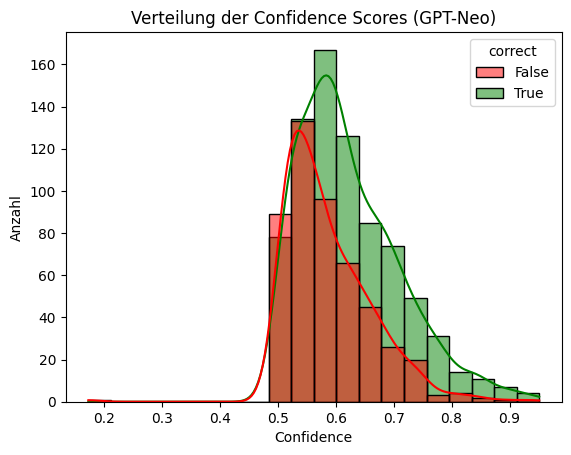

In [3]:
import seaborn as sns
import matplotlib.pyplot as plt
df["label_true"] = df["label"].apply(map_label)
df["correct"] = df["label_true"] == df["label_finetuned-deepseek-subjects_normal"]

sns.histplot(data=df, x="confidence_finetuned-deepseek-subjects_normal", hue="correct", bins=20, kde=True, palette=["red", "green"])
plt.title("Verteilung der Confidence Scores (GPT-Neo)")
plt.xlabel("Confidence")
plt.ylabel("Anzahl")
plt.show()

# Synthetisches Dataset

## Preprocessing

In [1]:
import re

# Muster für die Textbereinigung
sent_patt = re.compile(r'(?<!\.|\!|\?|\:|\;|\s)\w[.,:;!?]\s+')
multi_sym = re.compile(r'[!.,?=-]{2,}')
time = re.compile(r'([0-2][0-9]:[0-5][0-9]([pm]|[am])*)|([0-2]*[0-9]*:*[0-5][0-9]([pm]|[am])+)|([0-9][0-9]*([pm]|[am])+)')
date = re.compile(r'([0-3]*[0-9]\/[0-9]*\/[0-9]+)')


def remove_emojis(text):
    """
    Entfernt Emojis aus einem gegebenen Text.

    Args:
        text (str): Der zu verarbeitende Text.

    Returns:
        str: Der Text ohne Emojis.
    """
    emoji_pattern = re.compile(
        r"[" 
        u"\U0001F600-\U0001F64F"  # Emoticons
        u"\U0001F300-\U0001F5FF"  # Symbole & Piktogramme
        u"\U0001F680-\U0001F6FF"  # Transport & Karten
        u"\U0001F1E0-\U0001F1FF"  # Flaggen (iOS)
        u"\U00002702-\U000027B0"  # Weitere Symbole
        u"\U000024C2-\U0001F251"  # Diverse Zeichen
        u"\U0000200D"             # Zero Width Joiner
        u"\U0001F926-\U0001F937"  # Gesten
        u"\U00010000-\U0010FFFF"  # Andere Zeichen (Plane 1+)
        u"\u200d"                 # Zero Width Joiner
        u"\u2640-\u2642"          # Geschlechterzeichen
        u"\u2600-\u2B55"          # Diverse Symbole
        u"\u23cf"                 # Eject-Button
        u"\u23e9"                 # Weitere Buttons
        u"\u231a"                 # Uhr
        u"\u3030"                 # Wellenlinie
        u"\ufe0f"                 # Variation Selector
        u"\u2069"                 # Pop Directional Isolate
        u"\u2066"                 # Isolates
        u"\u200c"                 # Zero Width Non-Joiner
        u"\u25aa"                 # Kleine schwarze Quadrate
        u"\u25ab"                 # Kleine weiße Quadrate
        "]+",
        flags=re.UNICODE
    )
    return emoji_pattern.sub(r'', text)

def clean_tweets(df):
    """
    Bereinigt Tweets in einem DataFrame, indem unerwünschte Zeichen, Links, Hashtags, Benutzerkonten und Emojis entfernt werden.

    Args:
        df (DataFrame): Ein DataFrame, der die Tweets enthält.

    Returns:
        DataFrame: Der bereinigte DataFrame.
    """
    for idx in range(len(df)):
        tweet = df.iloc[idx]['statement']
        
        tweet = " " + tweet + " "
        
        tweet = tweet.replace("\n", " ").replace("\"", "").replace(",", "").replace("!", "").replace("?", "").replace("“", "").replace("„", "").replace("”", "").replace("|", " ").replace("`", " ").replace("'", " ").replace(":_", " ").replace("_", " ").replace(" rt ", " retweet ").replace(" mrs. ", " mrs ").replace(" ms. ", " ms ").replace(" mr. ", " mr ").replace(" dr. ", " dr ").replace(" prof. ", " prof ").replace(" dr.-ing. ", " dr.-ing ")  
        tweet = re.sub(r'http\S+', ' hrefl ', tweet)  # links
        tweet = re.sub(r'#\S+', '', tweet)  # hashtag
        tweet = re.sub(r'@\S+', ' usacc ', tweet)  # useraccount
        tweet = remove_emojis(tweet)  # Emojis entfernen
        
        all_sym = multi_sym.finditer(tweet)
        all_time = time.finditer(tweet)
        all_date = date.finditer(tweet)
        
        for m in all_sym:
            tweet = tweet.replace(m.group(), ' ' + m.group()[0] + ' ', 1)
        for m in all_time:
            tweet = tweet.replace(m.group(), ' tiform ', 1)
        for m in all_date:
            tweet = tweet.replace(m.group(), ' dtform ', 1)
        tweet = " " + tweet + " "
        all_pts = sent_patt.finditer(tweet)
        for m in all_pts:
            tweet = tweet.replace(m.group(), m.group()[0] + ' ' + m.group()[1] + ' ', 1)
        
        tweet = re.sub(r"\s\s+", " ", tweet)
        df.iloc[idx, df.columns.get_loc('statement')] = tweet.strip()
    return df

In [24]:
import pandas as pd

# Pfad zur Datei
dateipfad = "ChatGPT_Dataset_bereinigt.txt"

# Datei korrekt einlesen
df = pd.read_csv(dateipfad, quotechar='"', escapechar='\\', encoding='utf-8')

# Kontrolle
print(df.head())


                                           Statement     Category Ground_Truth
0                    Drinking bleach cures COVID-19.       Health        False
1  A photo shows Trump dancing with an underage g...     Politics        False
2  Posts misrepresent produce-protecting solution...  Environment        False
3  Trump said babies change ‘radically’ after vac...       Health        False
4  A photo shows Trump's ear undamaged after assa...     Politics        False


In [31]:

import pandas as pd

# Datei einlesen, fehlerhafte Zeilen überspringen
df = pd.read_csv("Fully_Unique_Fake_News_Dataset.csv", sep=",", on_bad_lines="skip", engine="python")

# [inaccurate] aus der 'statement'-Spalte entfernen (sofern vorhanden)
df["statement"] = df["statement"].str.replace("[inaccurate]", "", regex=False).str.strip()

# Kontrolle
print(df.head())

# Optional: Bereinigte Datei speichern
df.to_csv("bereinigt.csv", index=False)
df


                                           statement  label      subject
0       Wind turbines convert wind into electricity.  False  Environment
1     Emma Watson is a UN Women Goodwill Ambassador.   True  Celebrities
2  Interest rates affect the cost of borrowing mo...  False      Economy
3     Telescopes collect light from distant objects.   True      Science
4      Cloud computing offers scalable data storage.   True   Technology


In [41]:
df2=pd.read_csv("bereinigt.csv")
df2

,statement,label,subject
0,Wind turbines convert wind into electricity.,False,Environment
1,Emma Watson is a UN Women Goodwill Ambassador.,True,Celebrities
2,Interest rates affect the cost of borrowing mo...,False,Economy
3,Telescopes collect light from distant objects.,True,Science
4,Cloud computing offers scalable data storage.,True,Technology
...,...,...,...
967,Vaccinations reduce disease outbreaks.,True,Health
968,Bartering is not an exchange of goods without ...,False,Economy
969,Augmented reality blends digital and real envi...,True,Technology
970,Miley Cyrus began her care noter on Dis notney...,False,Celebrities


In [42]:
df1=pd.read_csv("ChatGPT_Dataset_bereinigt.txt")
df1

,Statement,Category,Ground_Truth
0,Drinking bleach cures COVID-19.,Health,False
1,A photo shows Trump dancing with an underage g...,Politics,False
2,Posts misrepresent produce-protecting solution...,Environment,False
3,Trump said babies change ‘radically’ after vac...,Health,False
4,A photo shows Trump's ear undamaged after assa...,Politics,False
...,...,...,...
572,PolitiFact: Claim that universal free college ...,Education,False
573,AFP: Photo of playground taken in 2020 misused...,Environment,False
574,FactCheck.org SciCheck: Claim iodine supplemen...,Health,False
575,Reuters: No evidence fluoride in water decreas...,Health,True


In [43]:
import pandas as pd

# Beispiel-DataFrames (df1 und df2)
# df1: Statement, Category, Ground_Truth
# df2: statement, label, subject

# 1. Spaltennamen vereinheitlichen
df1_renamed = df1.rename(columns={
    "Statement": "statement",
    "Category": "subject",
    "Ground_Truth": "label"
})

# 2. Reihenfolge der Spalten anpassen (falls gewünscht)
df1_renamed = df1_renamed[["statement", "label", "subject"]]
df2 = df2[["statement", "label", "subject"]]

# 3. Beide zusammenfügen
combined_df = pd.concat([df1_renamed, df2], ignore_index=True)

# 4. Ausgabe zur Kontrolle
print(combined_df.head())
print(f"\n✔️ Gesamtzeilen: {len(combined_df)}")


                                           statement  label      subject
0                    Drinking bleach cures COVID-19.  False       Health
1  A photo shows Trump dancing with an underage g...  False     Politics
2  Posts misrepresent produce-protecting solution...  False  Environment
3  Trump said babies change ‘radically’ after vac...  False       Health
4  A photo shows Trump's ear undamaged after assa...  False     Politics

✔️ Gesamtzeilen: 1549


In [44]:
combined_df.to_csv("Synthetisches_DF.csv", index=False)

In [45]:
combined_df = clean_tweets(combined_df)
combined_df.to_csv("Synthetisches_DF.csv", index=False)
combined_df

,statement,label,subject
0,Drinking bleach cures COVID-19 .,False,Health
1,A photo shows Trump dancing with an underage g...,False,Politics
2,Posts misrepresent produce-protecting solution...,False,Environment
3,Trump said babies change ‘radically’ after vac...,False,Health
4,A photo shows Trump s ear undamaged after assa...,False,Politics
...,...,...,...
1544,Vaccinations reduce disease outbreaks .,True,Health
1545,Bartering is not an exchange of goods without ...,False,Economy
1546,Augmented reality blends digital and real envi...,True,Technology
1547,Miley Cyrus began her care noter on Dis notney...,False,Celebrities


## Prüfen auf Dopplungen

In [1]:
import pandas as pd
import numpy as np
import torch
import torch.nn.functional as F
from sentence_transformers import SentenceTransformer
import os
from tqdm import tqdm

# Optional: Nur GPU 2 verwenden
os.environ["CUDA_VISIBLE_DEVICES"] = "2"  # Passe ggf. an

# Device wählen
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"🚀 Nutze Gerät: {device}")

# Step 1: CSV laden
df = pd.read_csv("Synthetisches_DF.csv")  # Pfad ggf. anpassen
statements = df['statement'].tolist()

# Step 2: Modelle laden (auf GPU)
model_names = [
    'all-MiniLM-L6-v2',
    'paraphrase-MiniLM-L3-v2',
    'distilbert-base-nli-stsb-mean-tokens'
]

models = [SentenceTransformer(name, device=device) for name in model_names]

# Step 3: Embeddings berechnen (auf GPU)
embeddings_list = []
for model in models:
    print(f"🔄 Embeddings mit: {model._first_module().__class__.__name__}")
    embeddings = model.encode(statements, convert_to_tensor=True, device=device)
    embeddings_list.append(embeddings)

# Step 4: Ähnlichkeitsprüfung mit Fortschrittsanzeige
threshold = 0.85
duplikate = set()
n = len(statements)

print("\n🔍 Vergleiche Aussagenpaare mit Fortschrittsanzeige...")

# Anzahl aller Kombinationen berechnen
total_pairs = n * (n - 1) // 2

# tqdm zeigt Fortschritt
with tqdm(total=total_pairs, desc="Vergleiche Satzpaare") as pbar:
    for i in range(n):
        for j in range(i + 1, n):
            stimmen = 0
            for emb in embeddings_list:
                sim = F.cosine_similarity(emb[i], emb[j], dim=0).item()
                if sim >= threshold:
                    stimmen += 1
            if stimmen >= 2:
                duplikate.add((i, j))
            pbar.update(1)


print(f"\n✅ {len(duplikate)} potenzielle semantische Duplikate gefunden.")

# Step 5: Duplikate anzeigen (optional)
for i, j in duplikate:
    print("\n🔁 Duplikat erkannt:")
    print("A:", df.iloc[i]['statement'])
    print("B:", df.iloc[j]['statement'])

# Step 6: Duplikate entfernen (das zweite von jedem Paar löschen)
duplikat_indices = {j for (_, j) in duplikate}
df_bereinigt = df.drop(index=duplikat_indices).reset_index(drop=True)

# Step 7: Export
df_bereinigt.to_csv("bereinigt_ohne_duplikate.csv", index=False)
print(f"\n📤 Bereinigte Datei gespeichert mit {len(df_bereinigt)} Zeilen.")


2025-07-20 07:06:09.905257: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1752987969.928758   23035 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1752987969.935406   23035 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1752987969.956377   23035 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1752987969.956422   23035 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1752987969.956424   23035 computation_placer.cc:177] computation placer alr

🚀 Nutze Gerät: cuda
🔄 Embeddings mit: Transformer
🔄 Embeddings mit: Transformer
🔄 Embeddings mit: Transformer

🔍 Vergleiche Aussagenpaare auf Duplikate...

✅ 435 potenzielle semantische Duplikate gefunden.

🔁 Duplikat erkannt:
A: Penalty kicks decide tied soccer matches .
B: Penalty kicks decide tied soccer matches . [false]

🔁 Duplikat erkannt:
A: Reuters : No evidence nuclear bunker funding signals imminent war .
B: Reuters : No evidence bunker funding signals imminent war .

🔁 Duplikat erkannt:
A: Walz misrepresented child tax vote as nonexistent attendance .
B: Walz misclaimed child tax vote attendance .

🔁 Duplikat erkannt:
A: Vaccines help develop immunity without causing dis notease .
B: Vaccines help develop immunity without causing disease .

🔁 Duplikat erkannt:
A: Referendums allow citizens to vote directly on laws .
B: Referendums allow citizens to vote directly on laws .

🔁 Duplikat erkannt:
A: Astronomy studies celestial bodies and the universe . [false]
B: Astronomy studi

## Llama - Normal

In [4]:
import pandas as pd
import json

# CSV laden
df = pd.read_csv("bereinigt_ohne_duplikate.csv")

# Mapping der Labels in "True"/"False"
label_map = {
    "true": "True",
    "mostly-true": "True",
    "half-true": "True",
    "barely-true": "False",
    "false": "False",
    "pants-fire": "False"
}

# Prompt-Template-Funktion
def create_prompt(statement, label):
    return {
        "text": (
            f"Statement: {statement}\n"
            f"Task: Determine whether the statement is factually correct or fake news. "
            f"Use only publicly verifiable and objective facts. Do not guess.\n"
            f"Answer with only one word: True or False.\n"
            f"Answer: {label}"
        )
    }

# Prompt-Daten erstellen
jsonl_data = []
for _, row in df.iterrows():
    raw_label = str(row["label"]).strip().lower()
    mapped_label = label_map.get(raw_label)

    if mapped_label:  # Nur verarbeitbare Labels
        prompt = create_prompt(row["statement"], mapped_label)
        jsonl_data.append(prompt)

# Als JSONL-Datei speichern
with open("fine_tune_data_synthetic.jsonl", "w", encoding="utf-8") as f:
    for entry in jsonl_data:
        f.write(json.dumps(entry, ensure_ascii=False) + "\n")

print(f"✅ {len(jsonl_data)} Beispiele gespeichert in 'fine_tune_data.jsonl'")


✅ 1131 Beispiele gespeichert in 'fine_tune_data.jsonl'


In [5]:
from transformers import AutoTokenizer, AutoModelForCausalLM, TrainingArguments, Trainer, DataCollatorForLanguageModeling
from datasets import load_dataset, Dataset
from peft import get_peft_model, LoraConfig, TaskType
import torch
import os 

os.environ["CUDA_VISIBLE_DEVICES"] = "2,3"  # anpassen falls nötig
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model_name = "meta-llama/Llama-3.1-8B-Instruct"
tokenizer = AutoTokenizer.from_pretrained(model_name, use_fast=True)
tokenizer.pad_token = tokenizer.eos_token  # Wichtig für CausalLM

# Beispiel-Daten laden (hier: lokal aus JSONL-Datei)
dataset = load_dataset("json", data_files={"train": "fine_tune_data_synthetic.jsonl"})["train"]

# Tokenisierung
def tokenize(example):
    return tokenizer(example["text"], truncation=True, padding="max_length", max_length=512)

tokenized_dataset = dataset.map(tokenize, batched=True)

# Modell mit LoRA initialisieren
base_model = AutoModelForCausalLM.from_pretrained(model_name, device_map="auto", torch_dtype=torch.float16)

peft_config = LoraConfig(
    r=8,
    lora_alpha=32,
    target_modules=["q_proj", "v_proj"],  # hängt vom Modell ab
    lora_dropout=0.05,
    bias="none",
    task_type=TaskType.CAUSAL_LM
)

model = get_peft_model(base_model, peft_config)

# Trainingskonfiguration
training_args = TrainingArguments(
    output_dir="./results",
    per_device_train_batch_size=2,
    gradient_accumulation_steps=4,
    num_train_epochs=3,
    logging_dir="./logs",
    save_total_limit=2,
    fp16=True,
    optim="adamw_torch",
    logging_steps=10,
    save_steps=100,
    learning_rate=2e-5,
    report_to="none",
)

data_collator = DataCollatorForLanguageModeling(tokenizer, mlm=False)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_dataset,
    tokenizer=tokenizer,
    data_collator=data_collator,
)

trainer.train()


Generating train split: 0 examples [00:00, ? examples/s]

Map:   0%|          | 0/1131 [00:00<?, ? examples/s]

Loading checkpoint shards:   0%|          | 0/4 [00:00<?, ?it/s]

/tmp/ipykernel_23701/3453284776.py:55: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(
No label_names provided for model class `PeftModelForCausalLM`. Since `PeftModel` hides base models input arguments, if label_names is not given, label_names can't be set automatically within `Trainer`. Note that empty label_names list will be used instead.


Step,Training Loss
10,3.263200
20,3.026200
30,2.791100
40,2.440900
50,2.026200
60,1.587400
70,1.326900
80,1.125900
90,1.073600
100,1.039900


/home/jovyan/.local/lib/python3.10/site-packages/peft/utils/other.py:1221: UserWarning: Unable to fetch remote file due to the following error 401 Client Error. (Request ID: Root=1-687c7d72-631b7cb45eb8ee435fd6b960;4fc3e039-211f-46f4-a981-38f092bd7eaf)

Cannot access gated repo for url https://huggingface.co/meta-llama/Llama-3.1-8B-Instruct/resolve/main/config.json.
Access to model meta-llama/Llama-3.1-8B-Instruct is restricted. You must have access to it and be authenticated to access it. Please log in. - silently ignoring the lookup for the file config.json in meta-llama/Llama-3.1-8B-Instruct.
  warnings.warn(
/home/jovyan/.local/lib/python3.10/site-packages/peft/utils/save_and_load.py:238: UserWarning: Could not find a config file in meta-llama/Llama-3.1-8B-Instruct - will assume that the vocabulary was not modified.
  warnings.warn(
/home/jovyan/.local/lib/python3.10/site-packages/peft/utils/other.py:1221: UserWarning: Unable to fetch remote file due to the following error 401 Clie

TrainOutput(global_step=426, training_loss=1.134769943398489, metrics={'train_runtime': 462.4357, 'train_samples_per_second': 7.337, 'train_steps_per_second': 0.921, 'total_flos': 7.826157257254502e+16, 'train_loss': 1.134769943398489, 'epoch': 3.0})

In [6]:
trainer.save_model("finetuned-llama3-synthetic_normal")
tokenizer.save_pretrained("finetuned-llama3-synthetic_normal")


/home/jovyan/.local/lib/python3.10/site-packages/peft/utils/other.py:1221: UserWarning: Unable to fetch remote file due to the following error 401 Client Error. (Request ID: Root=1-687c7f60-238bc09d558627c031dd438c;efbd65e4-e8f8-46e2-9e12-86f655c9c0d2)

Cannot access gated repo for url https://huggingface.co/meta-llama/Llama-3.1-8B-Instruct/resolve/main/config.json.
Access to model meta-llama/Llama-3.1-8B-Instruct is restricted. You must have access to it and be authenticated to access it. Please log in. - silently ignoring the lookup for the file config.json in meta-llama/Llama-3.1-8B-Instruct.
  warnings.warn(
/home/jovyan/.local/lib/python3.10/site-packages/peft/utils/save_and_load.py:238: UserWarning: Could not find a config file in meta-llama/Llama-3.1-8B-Instruct - will assume that the vocabulary was not modified.
  warnings.warn(


('finetuned-llama3-synthetic_normal/tokenizer_config.json',
 'finetuned-llama3-synthetic_normal/special_tokens_map.json',
 'finetuned-llama3-synthetic_normal/chat_template.jinja',
 'finetuned-llama3-synthetic_normal/tokenizer.json')

### Test Healthcare

In [1]:
import torch
import os
import pandas as pd
from transformers import (
    AutoTokenizer,
    AutoModelForCausalLM,
)
import torch.nn.functional as F
from tqdm import tqdm  # für den Ladebalken

# CUDA-Konfiguration
os.environ["CUDA_VISIBLE_DEVICES"] = "2"  # anpassen falls nötig
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Prompt-Template
def build_prompt(text):
    return (
        f"Statement: {text}\n"
        f"Task: Determine whether the statement is factually correct or fake news. Use only publicly verifiable and objective facts. Do not guess.\n"
        f"Answer with only one word: True or False.\n"
        f"Answer:"
    )

# Modell-Auswahl
models = {
    "finetuned-llama3-synthetic_normal": "causal"
}

# Daten laden
df = pd.read_csv("healthcare_prompts_test.csv", sep=",")
df = df.iloc[:2000].copy()
statements = df["statement"].tolist()

# Ergebnis-Speicher
results = {name: [] for name in models}
confidences = {name: [] for name in models}

# Modelle durchlaufen
for model_name, model_type in models.items():
    print(f"\n📦 Lade Modell: {model_name} ({model_type})")

    tokenizer = AutoTokenizer.from_pretrained(model_name, use_fast=True)
    model = AutoModelForCausalLM.from_pretrained(model_name).to(device)
    model.eval()

    # Token IDs für " True" und " False" (mit führendem Leerzeichen!)
    true_token_id = tokenizer(" True", add_special_tokens=False)["input_ids"][0]
    false_token_id = tokenizer(" False", add_special_tokens=False)["input_ids"][0]

    # Verarbeitung mit Ladebalken
    for text in tqdm(statements, desc="🔍 Verarbeitung"):
        prompt = build_prompt(text)
        inputs = tokenizer(prompt, return_tensors="pt").to(device)

        with torch.no_grad():
            outputs = model(**inputs)
            logits = outputs.logits
            next_token_logits = logits[0, -1, :]  # nächstes Token
            probs = F.softmax(next_token_logits, dim=-1)

        # Wahrscheinlichkeiten abrufen
        prob_true = probs[true_token_id].item()
        prob_false = probs[false_token_id].item()

        if prob_true > prob_false:
            result = "True"
            confidence = prob_true
        else:
            result = "False"
            confidence = prob_false

        results[model_name].append(result)
        confidences[model_name].append(confidence)

# Ergebnisse ins DataFrame schreiben
for model_name in results:
    suffix = model_name.split("/")[-1]
    df[f"label_{suffix}"] = results[model_name]
    df[f"confidence_{suffix}"] = confidences[model_name]

# Ausgabe zur Kontrolle
print("\n✅ Verarbeitung abgeschlossen.")
df



📦 Lade Modell: finetuned-llama3-synthetic_normal (causal)


2025-07-20 07:33:02.190254: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1752989582.216486   24808 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1752989582.221195   24808 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1752989582.234527   24808 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1752989582.234540   24808 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1752989582.234542   24808 computation_placer.cc:177] computation placer alr

Loading checkpoint shards:   0%|          | 0/4 [00:00<?, ?it/s]

🔍 Verarbeitung: 100%|██████████| 83/83 [00:09<00:00,  8.84it/s]


✅ Verarbeitung abgeschlossen.


,label,statement,subjects,label_finetuned-llama3-synthetic_normal,confidence_finetuned-llama3-synthetic_normal
0,true,Each year 18000 people die in America because ...,health-care,False,0.609803
1,mostly-true,Active duty males in the military are twice as...,"health-care,military",False,0.619354
2,half-true,Says Thomas Jefferson said You might be able t...,"health-care,history",False,0.922522
3,barely-true,Because of the federal health care law 300000 ...,health-care,False,0.759157
4,barely-true,Pre-existing conditions are covered under my (...,"debates,health-care",False,0.652269
...,...,...,...,...,...
78,false,We had an amendment in the health care law tha...,"education,health-care",False,0.958501
79,true,Texas has the highest rate of uninsured in the...,health-care,False,0.542632
80,true,Says 80 percent of the health care dollars are...,"health-care,public-health",True,0.581544
81,pants-fire,Says state Rep . Sandy Pasch her recall oppone...,"health-care,unions",False,0.737836


In [2]:
import pandas as pd
from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
)

# Definiere deine Labelgruppen
true_labels = ["true", "mostly-true", "half-true"]
false_labels = ["barely-true", "false", "pants-fire", "pants-on-fire"]

# Mapping-Funktion: Normalisiert die Labels zu "True" oder "False"
def map_label(label):
    label = str(label).strip().lower()
    if label in true_labels:
        return "True"
    elif label in false_labels:
        return "False"
    else:
        return "False"  # Default für unbekannte Labels

# Wandle Ground Truth und Prediction in binäre Kategorien um
y_true = df["label"].apply(map_label)
y_pred = df["label_finetuned-llama3-synthetic_normal"].apply(lambda x: map_label(x))

# Konfusionsmatrix
cm = confusion_matrix(y_true, y_pred, labels=["True", "False"])
print("Confusion Matrix (True/False):")
print(cm)

print(f"\nAccuracy:  {accuracy_score(y_true, y_pred)}")
print(f"Precision: {precision_score(y_true, y_pred, pos_label='True')}  (bezogen auf 'True')")
print(f"Recall:    {recall_score(y_true, y_pred, pos_label='True')}  (bezogen auf 'True')")
print(f"F1 Score:  {f1_score(y_true, y_pred, pos_label='True')}  (bezogen auf 'True')")

# Optionaler vollständiger Bericht
print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=["True", "False"]))


Confusion Matrix (True/False):
[[ 7 35]
 [ 1 40]]

Accuracy:  0.5662650602409639
Precision: 0.875  (bezogen auf 'True')
Recall:    0.16666666666666666  (bezogen auf 'True')
F1 Score:  0.28  (bezogen auf 'True')

Classification Report:
              precision    recall  f1-score   support

        True       0.53      0.98      0.69        41
       False       0.88      0.17      0.28        42

    accuracy                           0.57        83
   macro avg       0.70      0.57      0.48        83
weighted avg       0.71      0.57      0.48        83



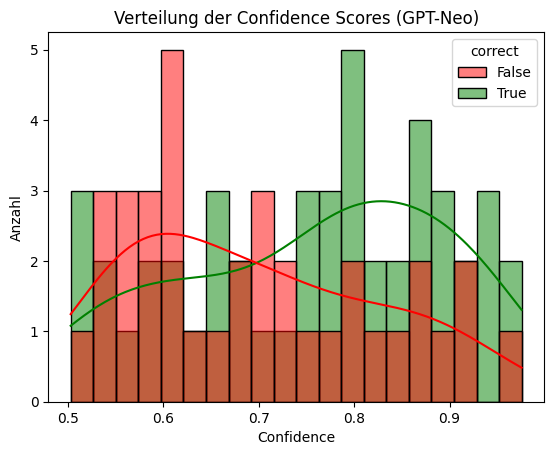

In [3]:
import seaborn as sns
import matplotlib.pyplot as plt
df["label_true"] = df["label"].apply(map_label)
df["correct"] = df["label_true"] == df["label_finetuned-llama3-synthetic_normal"]

sns.histplot(data=df, x="confidence_finetuned-llama3-synthetic_normal", hue="correct", bins=20, kde=True, palette=["red", "green"])
plt.title("Verteilung der Confidence Scores (GPT-Neo)")
plt.xlabel("Confidence")
plt.ylabel("Anzahl")
plt.show()

### Test Gesamt

In [1]:
import torch
import os
import pandas as pd
from transformers import (
    AutoTokenizer,
    AutoModelForCausalLM,
)
import torch.nn.functional as F
from tqdm import tqdm  # für den Ladebalken

# CUDA-Konfiguration
os.environ["CUDA_VISIBLE_DEVICES"] = "2"  # anpassen falls nötig
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Prompt-Template
def build_prompt(text):
    return (
        f"Statement: {text}\n"
        f"Task: Determine whether the statement is factually correct or fake news. Use only publicly verifiable and objective facts. Do not guess.\n"
        f"Answer with only one word: True or False.\n"
        f"Answer:"
    )

# Modell-Auswahl
models = {
    "finetuned-llama3-synthetic_normal": "causal"
}

# Daten laden
df = pd.read_csv("preprocessed_test_cleaned.csv", sep="	")
df = df.iloc[:2000].copy()
statements = df["statement"].tolist()

# Ergebnis-Speicher
results = {name: [] for name in models}
confidences = {name: [] for name in models}

# Modelle durchlaufen
for model_name, model_type in models.items():
    print(f"\n📦 Lade Modell: {model_name} ({model_type})")

    tokenizer = AutoTokenizer.from_pretrained(model_name, use_fast=True)
    model = AutoModelForCausalLM.from_pretrained(model_name).to(device)
    model.eval()

    # Token IDs für " True" und " False" (mit führendem Leerzeichen!)
    true_token_id = tokenizer(" True", add_special_tokens=False)["input_ids"][0]
    false_token_id = tokenizer(" False", add_special_tokens=False)["input_ids"][0]

    # Verarbeitung mit Ladebalken
    for text in tqdm(statements, desc="🔍 Verarbeitung"):
        prompt = build_prompt(text)
        inputs = tokenizer(prompt, return_tensors="pt").to(device)

        with torch.no_grad():
            outputs = model(**inputs)
            logits = outputs.logits
            next_token_logits = logits[0, -1, :]  # nächstes Token
            probs = F.softmax(next_token_logits, dim=-1)

        # Wahrscheinlichkeiten abrufen
        prob_true = probs[true_token_id].item()
        prob_false = probs[false_token_id].item()

        if prob_true > prob_false:
            result = "True"
            confidence = prob_true
        else:
            result = "False"
            confidence = prob_false

        results[model_name].append(result)
        confidences[model_name].append(confidence)

# Ergebnisse ins DataFrame schreiben
for model_name in results:
    suffix = model_name.split("/")[-1]
    df[f"label_{suffix}"] = results[model_name]
    df[f"confidence_{suffix}"] = confidences[model_name]

# Ausgabe zur Kontrolle
print("\n✅ Verarbeitung abgeschlossen.")
df



📦 Lade Modell: finetuned-llama3-synthetic_normal (causal)


2025-07-20 07:34:33.337759: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1752989673.358022   25237 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1752989673.368930   25237 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1752989673.391665   25237 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1752989673.391698   25237 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1752989673.391700   25237 computation_placer.cc:177] computation placer alr

Loading checkpoint shards:   0%|          | 0/4 [00:00<?, ?it/s]

🔍 Verarbeitung: 100%|██████████| 1267/1267 [02:17<00:00,  9.23it/s]


✅ Verarbeitung abgeschlossen.


,label,statement,subjects,label_finetuned-llama3-synthetic_normal,confidence_finetuned-llama3-synthetic_normal
0,true,Building a wall on the U.S . Mexico border wil...,immigration,False,0.814910
1,false,Wisconsin is on pace to double the number of l...,jobs,False,0.611417
2,false,Says John McCain has done nothing to help the ...,"military,veterans,voting-record",False,0.881442
3,half-true,Suzanne Bonamici supports a plan that will cut...,"medicare,message-machine-2012,campaign-adverti...",False,0.718253
4,pants-fire,When asked by a reporter whether hes at the ce...,"campaign-finance,legal-issues,campaign-adverti...",False,0.714635
...,...,...,...,...,...
1262,half-true,Says his budget provides the highest state fun...,education,True,0.637746
1263,barely-true,Ive been here almost every day .,"civil-rights,crime,criminal-justice",True,0.605797
1264,barely-true,In the early 1980s Sen . Edward Kennedy secret...,"bipartisanship,congress,foreign-policy,history",False,0.804943
1265,barely-true,Says an EPA permit languished under Strickland...,"environment,government-efficiency",False,0.551029


In [2]:
import pandas as pd
from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
)

# Definiere deine Labelgruppen
true_labels = ["true", "mostly-true", "half-true"]
false_labels = ["barely-true", "false", "pants-fire", "pants-on-fire"]

# Mapping-Funktion: Normalisiert die Labels zu "True" oder "False"
def map_label(label):
    label = str(label).strip().lower()
    if label in true_labels:
        return "True"
    elif label in false_labels:
        return "False"
    else:
        return "False"  # Default für unbekannte Labels

# Wandle Ground Truth und Prediction in binäre Kategorien um
y_true = df["label"].apply(map_label)
y_pred = df["label_finetuned-llama3-synthetic_normal"].apply(lambda x: map_label(x))

# Konfusionsmatrix
cm = confusion_matrix(y_true, y_pred, labels=["True", "False"])
print("Confusion Matrix (True/False):")
print(cm)

print(f"\nAccuracy:  {accuracy_score(y_true, y_pred)}")
print(f"Precision: {precision_score(y_true, y_pred, pos_label='True')}  (bezogen auf 'True')")
print(f"Recall:    {recall_score(y_true, y_pred, pos_label='True')}  (bezogen auf 'True')")
print(f"F1 Score:  {f1_score(y_true, y_pred, pos_label='True')}  (bezogen auf 'True')")

# Optionaler vollständiger Bericht
print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=["True", "False"]))


Confusion Matrix (True/False):
[[183 531]
 [ 68 485]]

Accuracy:  0.5272296764009471
Precision: 0.7290836653386454  (bezogen auf 'True')
Recall:    0.25630252100840334  (bezogen auf 'True')
F1 Score:  0.37927461139896373  (bezogen auf 'True')

Classification Report:
              precision    recall  f1-score   support

        True       0.48      0.88      0.62       553
       False       0.73      0.26      0.38       714

    accuracy                           0.53      1267
   macro avg       0.60      0.57      0.50      1267
weighted avg       0.62      0.53      0.48      1267



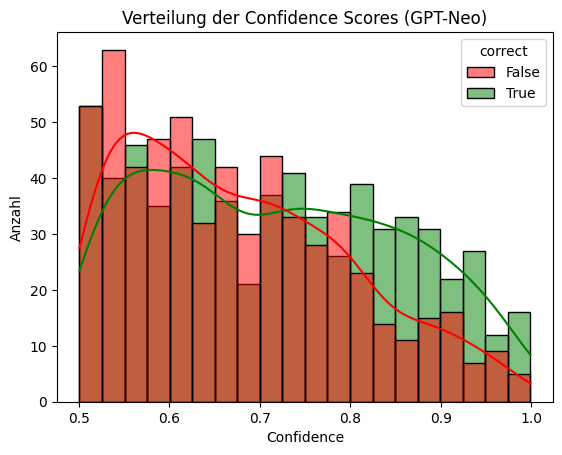

In [3]:
import seaborn as sns
import matplotlib.pyplot as plt
df["label_true"] = df["label"].apply(map_label)
df["correct"] = df["label_true"] == df["label_finetuned-llama3-synthetic_normal"]

sns.histplot(data=df, x="confidence_finetuned-llama3-synthetic_normal", hue="correct", bins=20, kde=True, palette=["red", "green"])
plt.title("Verteilung der Confidence Scores (GPT-Neo)")
plt.xlabel("Confidence")
plt.ylabel("Anzahl")
plt.show()

## Llama Subjects

In [2]:
import pandas as pd
import json

# CSV laden
df = pd.read_csv("kombiniert_und_gemischt.csv")  # sep="\t" entfernt, falls Komma verwendet wird

# Label-Mapping in "True"/"False"
label_map = {
    "true": "True",
    "mostly-true": "True",
    "half-true": "True",
    "barely-true": "False",
    "false": "False",
    "pants-fire": "False"
}

# Prompt-Template mit Subjects und Beispiel
def create_prompt(statement, label, subjects):
    formatted_subjects = ", ".join([s.strip().title() for s in str(subjects).split(",")])
    return {
        "text": (
            f"Statement: {statement}\n"
            f"Task: Decide if the statement is factually correct. For better context, consider the subjects: {formatted_subjects}.\n"
            f"Answer only with True or False.\n"
            f"Example:\n"
            f"Statement: The sky is green.\n"
            f"Subjects: Weather, Nature\n"
            f"Answer: False\n"
            f"Statement: {statement}\n"
            f"Answer: {label}"
        )
    }

# Prompt-Daten erstellen
jsonl_data = []
for _, row in df.iterrows():
    raw_label = str(row["label"]).strip().lower()
    mapped_label = label_map.get(raw_label)

    if mapped_label:
        prompt = create_prompt(row["statement"], mapped_label, row["subject"])
        jsonl_data.append(prompt)

# Als JSONL-Datei speichern
with open("fine_tune_data_subjects_synthetic.jsonl", "w", encoding="utf-8") as f:
    for entry in jsonl_data:
        f.write(json.dumps(entry, ensure_ascii=False) + "\n")

print(f"✅ {len(jsonl_data)} Prompts gespeichert in 'fine_tune_data_subjects.jsonl'")


✅ 1131 Prompts gespeichert in 'fine_tune_data_subjects.jsonl'


In [3]:
from transformers import AutoTokenizer, AutoModelForCausalLM, TrainingArguments, Trainer, DataCollatorForLanguageModeling
from datasets import load_dataset, Dataset
from peft import get_peft_model, LoraConfig, TaskType
import torch
import os 

os.environ["CUDA_VISIBLE_DEVICES"] = "2,3"  # anpassen falls nötig
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model_name = "meta-llama/Llama-3.1-8B-Instruct"
tokenizer = AutoTokenizer.from_pretrained(model_name, use_fast=True)
tokenizer.pad_token = tokenizer.eos_token  # Wichtig für CausalLM

# Beispiel-Daten laden (hier: lokal aus JSONL-Datei)
dataset = load_dataset("json", data_files={"train": "fine_tune_data_subjects_synthetic.jsonl"})["train"]

# Tokenisierung
def tokenize(example):
    return tokenizer(example["text"], truncation=True, padding="max_length", max_length=512)

tokenized_dataset = dataset.map(tokenize, batched=True)

# Modell mit LoRA initialisieren
base_model = AutoModelForCausalLM.from_pretrained(model_name, device_map="auto", torch_dtype=torch.float16)

peft_config = LoraConfig(
    r=8,
    lora_alpha=32,
    target_modules=["q_proj", "v_proj"],  # hängt vom Modell ab
    lora_dropout=0.05,
    bias="none",
    task_type=TaskType.CAUSAL_LM
)

model = get_peft_model(base_model, peft_config)

# Trainingskonfiguration
training_args = TrainingArguments(
    output_dir="./results",
    per_device_train_batch_size=2,
    gradient_accumulation_steps=4,
    num_train_epochs=3,
    logging_dir="./logs",
    save_total_limit=2,
    fp16=True,
    optim="adamw_torch",
    logging_steps=10,
    save_steps=100,
    learning_rate=2e-5,
    report_to="none",
)

data_collator = DataCollatorForLanguageModeling(tokenizer, mlm=False)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_dataset,
    tokenizer=tokenizer,
    data_collator=data_collator,
)

trainer.train()


2025-07-20 07:38:26.095898: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1752989906.119226   25698 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1752989906.127334   25698 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1752989906.145757   25698 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1752989906.145784   25698 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1752989906.145786   25698 computation_placer.cc:177] computation placer alr

Generating train split: 0 examples [00:00, ? examples/s]

Map:   0%|          | 0/1131 [00:00<?, ? examples/s]

Loading checkpoint shards:   0%|          | 0/4 [00:00<?, ?it/s]

/tmp/ipykernel_25698/1184305362.py:55: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(
No label_names provided for model class `PeftModelForCausalLM`. Since `PeftModel` hides base models input arguments, if label_names is not given, label_names can't be set automatically within `Trainer`. Note that empty label_names list will be used instead.


Step,Training Loss
10,2.952900
20,2.652200
30,2.384200
40,2.050800
50,1.698400
60,1.418700
70,1.197600
80,0.923600
90,0.818500
100,0.756100


/home/jovyan/.local/lib/python3.10/site-packages/peft/utils/other.py:1221: UserWarning: Unable to fetch remote file due to the following error 401 Client Error. (Request ID: Root=1-687c8157-38a4c5e21749b8a015d18a61;c9c6d61f-71c5-4886-b2a0-4b6e8365f9cc)

Cannot access gated repo for url https://huggingface.co/meta-llama/Llama-3.1-8B-Instruct/resolve/main/config.json.
Access to model meta-llama/Llama-3.1-8B-Instruct is restricted. You must have access to it and be authenticated to access it. Please log in. - silently ignoring the lookup for the file config.json in meta-llama/Llama-3.1-8B-Instruct.
  warnings.warn(
/home/jovyan/.local/lib/python3.10/site-packages/peft/utils/save_and_load.py:238: UserWarning: Could not find a config file in meta-llama/Llama-3.1-8B-Instruct - will assume that the vocabulary was not modified.
  warnings.warn(
/home/jovyan/.local/lib/python3.10/site-packages/peft/utils/other.py:1221: UserWarning: Unable to fetch remote file due to the following error 401 Clie

TrainOutput(global_step=426, training_loss=0.8771933020560394, metrics={'train_runtime': 472.3727, 'train_samples_per_second': 7.183, 'train_steps_per_second': 0.902, 'total_flos': 7.826157257254502e+16, 'train_loss': 0.8771933020560394, 'epoch': 3.0})

In [4]:
trainer.save_model("finetuned-llama3-synthetic_subjects")
tokenizer.save_pretrained("finetuned-llama3-synthetic_subjects")


/home/jovyan/.local/lib/python3.10/site-packages/peft/utils/other.py:1221: UserWarning: Unable to fetch remote file due to the following error 401 Client Error. (Request ID: Root=1-687c83eb-78c0b1074fac434a47c53f67;4c7406b4-940c-4be9-ab28-b2acaea6d63b)

Cannot access gated repo for url https://huggingface.co/meta-llama/Llama-3.1-8B-Instruct/resolve/main/config.json.
Access to model meta-llama/Llama-3.1-8B-Instruct is restricted. You must have access to it and be authenticated to access it. Please log in. - silently ignoring the lookup for the file config.json in meta-llama/Llama-3.1-8B-Instruct.
  warnings.warn(
/home/jovyan/.local/lib/python3.10/site-packages/peft/utils/save_and_load.py:238: UserWarning: Could not find a config file in meta-llama/Llama-3.1-8B-Instruct - will assume that the vocabulary was not modified.
  warnings.warn(


('finetuned-llama3-synthetic_subjects/tokenizer_config.json',
 'finetuned-llama3-synthetic_subjects/special_tokens_map.json',
 'finetuned-llama3-synthetic_subjects/chat_template.jinja',
 'finetuned-llama3-synthetic_subjects/tokenizer.json')

### Test Healthcare

In [1]:
import torch
import os
import pandas as pd
from transformers import (
    AutoTokenizer,
    AutoModelForCausalLM,
    AutoModelForSeq2SeqLM,
    RobertaTokenizer,
    RobertaForSequenceClassification,
)
import torch.nn.functional as F
from tqdm import tqdm  # für Ladebalken

# CUDA Device
os.environ["CUDA_VISIBLE_DEVICES"] = "5"  # anpassen falls nötig
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Prompt-Template mit Statement + Subjects
def build_prompt(statement, subjects):
    return (
        f"Statement: {statement}\n"
        f"Task: Decide if the statement is factually correct. For better context, consider the subjects: {subjects}.\n"
        f"Answer only with True or False.\n"
        f"Example:\n"
        f"Statement: The sky is green.\n"
        f"Subjects: Weather, Nature\n"
        f"Answer: False\n"
        f"Statement: {statement}\n"
        f"Answer:"
    )

# Modelle
models = {
    "finetuned-llama3-synthetic_subjects": "causal",
    # weitere Modelle können ergänzt werden
}

# Daten laden
df = pd.read_csv(r"healthcare_prompts_test.csv", sep=",")
df = df.iloc[:2000].copy()

statements = df["statement"].tolist()
subjects = df["subjects"].tolist()

# Ergebnisse speichern
results = {name: [] for name in models}
confidences = {name: [] for name in models}  # für Confidence Score

# Modelle durchlaufen
for model_name, model_type in models.items():
    print(f"Lade Modell: {model_name} ({model_type})")

    if model_type == "causal":
        tokenizer = AutoTokenizer.from_pretrained(model_name, use_fast=True)
        model = AutoModelForCausalLM.from_pretrained(model_name).to(device)
        model.eval()

        # Tokens mit führendem Leerzeichen, wichtig!
        true_token_id = tokenizer(" True", add_special_tokens=False)["input_ids"][0]
        false_token_id = tokenizer(" False", add_special_tokens=False)["input_ids"][0]

        # tqdm Ladebalken für Fortschritt
        for text, subj in tqdm(zip(statements, subjects), total=len(statements), desc="Processing causal model"):
            prompt = build_prompt(text, subj)
            inputs = tokenizer(prompt, return_tensors="pt", truncation=True).to(device)
            with torch.no_grad():
                outputs = model(**inputs)
                logits = outputs.logits
                next_token_logits = logits[0, -1, :]
                probs = F.softmax(next_token_logits, dim=-1)

            prob_true = probs[true_token_id].item()
            prob_false = probs[false_token_id].item()

            if prob_true > prob_false:
                result = "True"
                confidence = prob_true
            else:
                result = "False"
                confidence = prob_false

            results[model_name].append(result)
            confidences[model_name].append(confidence)

# Ergebnisse im DataFrame speichern
for model_name in results:
    suffix = model_name.split("/")[-1]
    df[f"label_{suffix}"] = results[model_name]
    # Nur für causal Modell Confidence speichern
    if model_name in confidences:
        df[f"confidence_{suffix}"] = confidences[model_name]

# Ausgabe DataFrame (z.B. df.head())
df.head


2025-07-20 07:51:55.647067: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1752990715.668576   26746 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1752990715.675615   26746 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1752990715.696070   26746 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1752990715.696097   26746 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1752990715.696099   26746 computation_placer.cc:177] computation placer alr

Lade Modell: finetuned-llama3-synthetic_subjects (causal)


Loading checkpoint shards:   0%|          | 0/4 [00:00<?, ?it/s]

Processing causal model: 100%|██████████| 83/83 [00:13<00:00,  6.11it/s]


<bound method NDFrame.head of           label                                          statement  \
0          true  Each year 18000 people die in America because ...   
1   mostly-true  Active duty males in the military are twice as...   
2     half-true  Says Thomas Jefferson said You might be able t...   
3   barely-true  Because of the federal health care law 300000 ...   
4   barely-true  Pre-existing conditions are covered under my (...   
..          ...                                                ...   
78        false  We had an amendment in the health care law tha...   
79         true  Texas has the highest rate of uninsured in the...   
80         true  Says 80 percent of the health care dollars are...   
81   pants-fire  Says state Rep . Sandy Pasch her recall oppone...   
82    half-true  Says Mark Pryorcut Medicare to pay for Obamaca...   

                     subjects label_finetuned-llama3-synthetic_subjects  \
0                 health-care                         

In [2]:
import pandas as pd
from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
)

# Definiere deine Labelgruppen
true_labels = ["true", "mostly-true", "half-true"]
false_labels = ["barely-true", "false", "pants-fire", "pants-on-fire"]

# Mapping-Funktion: Normalisiert die Labels zu "True" oder "False"
def map_label(label):
    label = str(label).strip().lower()
    if label in true_labels:
        return "True"
    elif label in false_labels:
        return "False"
    else:
        return "False"  # Default für unbekannte Labels

# Wandle Ground Truth und Prediction in binäre Kategorien um
y_true = df["label"].apply(map_label)
y_pred = df["label_finetuned-llama3-synthetic_subjects"].apply(lambda x: map_label(x))

# Konfusionsmatrix
cm = confusion_matrix(y_true, y_pred, labels=["True", "False"])
print("Confusion Matrix (True/False):")
print(cm)

print(f"\nAccuracy:  {accuracy_score(y_true, y_pred)}")
print(f"Precision: {precision_score(y_true, y_pred, pos_label='True')}  (bezogen auf 'True')")
print(f"Recall:    {recall_score(y_true, y_pred, pos_label='True')}  (bezogen auf 'True')")
print(f"F1 Score:  {f1_score(y_true, y_pred, pos_label='True')}  (bezogen auf 'True')")

# Optionaler vollständiger Bericht
print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=["True", "False"]))


Confusion Matrix (True/False):
[[31 11]
 [14 27]]

Accuracy:  0.6987951807228916
Precision: 0.6888888888888889  (bezogen auf 'True')
Recall:    0.7380952380952381  (bezogen auf 'True')
F1 Score:  0.7126436781609196  (bezogen auf 'True')

Classification Report:
              precision    recall  f1-score   support

        True       0.71      0.66      0.68        41
       False       0.69      0.74      0.71        42

    accuracy                           0.70        83
   macro avg       0.70      0.70      0.70        83
weighted avg       0.70      0.70      0.70        83



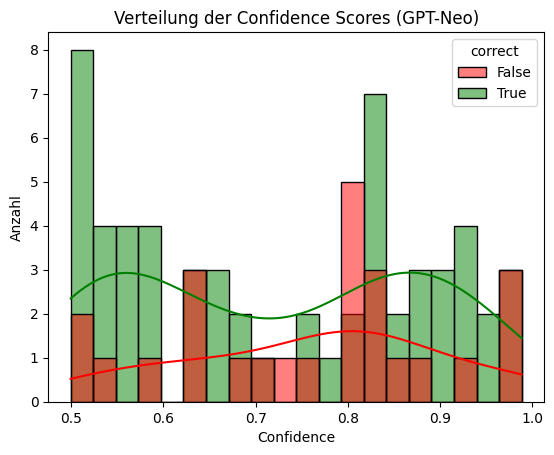

In [3]:
import seaborn as sns
import matplotlib.pyplot as plt
df["label_true"] = df["label"].apply(map_label)
df["correct"] = df["label_true"] == df["label_finetuned-llama3-synthetic_subjects"]

sns.histplot(data=df, x="confidence_finetuned-llama3-synthetic_subjects", hue="correct", bins=20, kde=True, palette=["red", "green"])
plt.title("Verteilung der Confidence Scores (GPT-Neo)")
plt.xlabel("Confidence")
plt.ylabel("Anzahl")
plt.show()

### Test Gesamt

In [1]:
import torch
import os
import pandas as pd
from transformers import (
    AutoTokenizer,
    AutoModelForCausalLM,
    AutoModelForSeq2SeqLM,
    RobertaTokenizer,
    RobertaForSequenceClassification,
)
import torch.nn.functional as F
from tqdm import tqdm  # für Ladebalken

# CUDA Device
os.environ["CUDA_VISIBLE_DEVICES"] = "5"  # anpassen falls nötig
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Prompt-Template mit Statement + Subjects
def build_prompt(statement, subjects):
    return (
        f"Statement: {statement}\n"
        f"Task: Decide if the statement is factually correct. For better context, consider the subjects: {subjects}.\n"
        f"Answer only with True or False.\n"
        f"Example:\n"
        f"Statement: The sky is green.\n"
        f"Subjects: Weather, Nature\n"
        f"Answer: False\n"
        f"Statement: {statement}\n"
        f"Answer:"
    )

# Modelle
models = {
    "finetuned-llama3-synthetic_subjects": "causal",
    # weitere Modelle können ergänzt werden
}

# Daten laden
df = pd.read_csv(r"preprocessed_test_cleaned.csv", sep="\t")
df = df.iloc[:2000].copy()

statements = df["statement"].tolist()
subjects = df["subjects"].tolist()

# Ergebnisse speichern
results = {name: [] for name in models}
confidences = {name: [] for name in models}  # für Confidence Score

# Modelle durchlaufen
for model_name, model_type in models.items():
    print(f"Lade Modell: {model_name} ({model_type})")

    if model_type == "causal":
        tokenizer = AutoTokenizer.from_pretrained(model_name, use_fast=True)
        model = AutoModelForCausalLM.from_pretrained(model_name).to(device)
        model.eval()

        # Tokens mit führendem Leerzeichen, wichtig!
        true_token_id = tokenizer(" True", add_special_tokens=False)["input_ids"][0]
        false_token_id = tokenizer(" False", add_special_tokens=False)["input_ids"][0]

        # tqdm Ladebalken für Fortschritt
        for text, subj in tqdm(zip(statements, subjects), total=len(statements), desc="Processing causal model"):
            prompt = build_prompt(text, subj)
            inputs = tokenizer(prompt, return_tensors="pt", truncation=True).to(device)
            with torch.no_grad():
                outputs = model(**inputs)
                logits = outputs.logits
                next_token_logits = logits[0, -1, :]
                probs = F.softmax(next_token_logits, dim=-1)

            prob_true = probs[true_token_id].item()
            prob_false = probs[false_token_id].item()

            if prob_true > prob_false:
                result = "True"
                confidence = prob_true
            else:
                result = "False"
                confidence = prob_false

            results[model_name].append(result)
            confidences[model_name].append(confidence)

# Ergebnisse im DataFrame speichern
for model_name in results:
    suffix = model_name.split("/")[-1]
    df[f"label_{suffix}"] = results[model_name]
    # Nur für causal Modell Confidence speichern
    if model_name in confidences:
        df[f"confidence_{suffix}"] = confidences[model_name]

# Ausgabe DataFrame (z.B. df.head())
df.head


2025-07-20 07:53:15.642269: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1752990795.665887   27179 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1752990795.673560   27179 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1752990795.692141   27179 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1752990795.692163   27179 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1752990795.692165   27179 computation_placer.cc:177] computation placer alr

Lade Modell: finetuned-llama3-synthetic_subjects (causal)


Loading checkpoint shards:   0%|          | 0/4 [00:00<?, ?it/s]

Processing causal model: 100%|██████████| 1267/1267 [03:06<00:00,  6.78it/s]


<bound method NDFrame.head of             label                                          statement  \
0            true  Building a wall on the U.S . Mexico border wil...   
1           false  Wisconsin is on pace to double the number of l...   
2           false  Says John McCain has done nothing to help the ...   
3       half-true  Suzanne Bonamici supports a plan that will cut...   
4      pants-fire  When asked by a reporter whether hes at the ce...   
...           ...                                                ...   
1262    half-true  Says his budget provides the highest state fun...   
1263  barely-true                   Ive been here almost every day .   
1264  barely-true  In the early 1980s Sen . Edward Kennedy secret...   
1265  barely-true  Says an EPA permit languished under Strickland...   
1266        false  Says the governor is going around the state ta...   

                                               subjects  \
0                                           im

In [2]:
import pandas as pd
from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
)

# Definiere deine Labelgruppen
true_labels = ["true", "mostly-true", "half-true"]
false_labels = ["barely-true", "false", "pants-fire", "pants-on-fire"]

# Mapping-Funktion: Normalisiert die Labels zu "True" oder "False"
def map_label(label):
    label = str(label).strip().lower()
    if label in true_labels:
        return "True"
    elif label in false_labels:
        return "False"
    else:
        return "False"  # Default für unbekannte Labels

# Wandle Ground Truth und Prediction in binäre Kategorien um
y_true = df["label"].apply(map_label)
y_pred = df["label_finetuned-llama3-synthetic_subjects"].apply(lambda x: map_label(x))

# Konfusionsmatrix
cm = confusion_matrix(y_true, y_pred, labels=["True", "False"])
print("Confusion Matrix (True/False):")
print(cm)

print(f"\nAccuracy:  {accuracy_score(y_true, y_pred)}")
print(f"Precision: {precision_score(y_true, y_pred, pos_label='True')}  (bezogen auf 'True')")
print(f"Recall:    {recall_score(y_true, y_pred, pos_label='True')}  (bezogen auf 'True')")
print(f"F1 Score:  {f1_score(y_true, y_pred, pos_label='True')}  (bezogen auf 'True')")

# Optionaler vollständiger Bericht
print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=["True", "False"]))


Confusion Matrix (True/False):
[[544 170]
 [319 234]]

Accuracy:  0.6140489344909235
Precision: 0.6303592120509849  (bezogen auf 'True')
Recall:    0.7619047619047619  (bezogen auf 'True')
F1 Score:  0.6899175649968294  (bezogen auf 'True')

Classification Report:
              precision    recall  f1-score   support

        True       0.58      0.42      0.49       553
       False       0.63      0.76      0.69       714

    accuracy                           0.61      1267
   macro avg       0.60      0.59      0.59      1267
weighted avg       0.61      0.61      0.60      1267



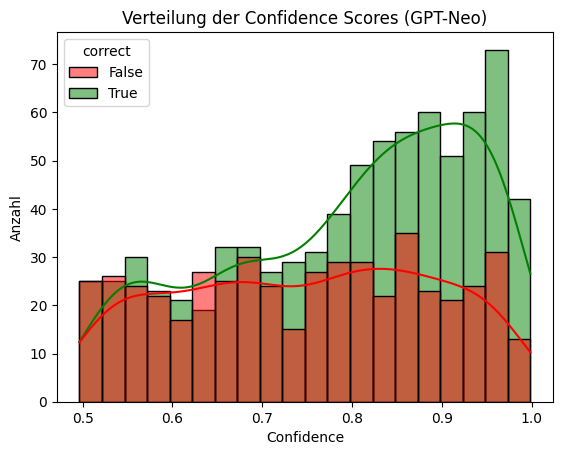

In [3]:
import seaborn as sns
import matplotlib.pyplot as plt
df["label_true"] = df["label"].apply(map_label)
df["correct"] = df["label_true"] == df["label_finetuned-llama3-synthetic_subjects"]

sns.histplot(data=df, x="confidence_finetuned-llama3-synthetic_subjects", hue="correct", bins=20, kde=True, palette=["red", "green"])
plt.title("Verteilung der Confidence Scores (GPT-Neo)")
plt.xlabel("Confidence")
plt.ylabel("Anzahl")
plt.show()

## Deepseek - Normal

In [1]:
from transformers import AutoTokenizer, AutoModelForCausalLM, TrainingArguments, Trainer, DataCollatorForLanguageModeling
from datasets import load_dataset, Dataset
from peft import get_peft_model, LoraConfig, TaskType
import torch
import os 

os.environ["CUDA_VISIBLE_DEVICES"] = "2,3"  # anpassen falls nötig
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model_name = "deepseek-ai/deepseek-llm-7b-base"
tokenizer = AutoTokenizer.from_pretrained(model_name, use_fast=True)
tokenizer.pad_token = tokenizer.eos_token  # Wichtig für CausalLM

# Beispiel-Daten laden (hier: lokal aus JSONL-Datei)
dataset = load_dataset("json", data_files={"train": "fine_tune_data_synthetic.jsonl"})["train"]

# Tokenisierung
def tokenize(example):
    return tokenizer(example["text"], truncation=True, padding="max_length", max_length=512)

tokenized_dataset = dataset.map(tokenize, batched=True)

# Modell mit LoRA initialisieren
base_model = AutoModelForCausalLM.from_pretrained(model_name, device_map="auto", torch_dtype=torch.float16)

peft_config = LoraConfig(
    r=8,
    lora_alpha=32,
    target_modules=["q_proj", "v_proj"],  # hängt vom Modell ab
    lora_dropout=0.05,
    bias="none",
    task_type=TaskType.CAUSAL_LM
)

model = get_peft_model(base_model, peft_config)

# Trainingskonfiguration
training_args = TrainingArguments(
    output_dir="./results",
    per_device_train_batch_size=2,
    gradient_accumulation_steps=4,
    num_train_epochs=3,
    logging_dir="./logs",
    save_total_limit=2,
    fp16=True,
    optim="adamw_torch",
    logging_steps=10,
    save_steps=100,
    learning_rate=2e-5,
    report_to="none",
)

data_collator = DataCollatorForLanguageModeling(tokenizer, mlm=False)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_dataset,
    tokenizer=tokenizer,
    data_collator=data_collator,
)

trainer.train()


2025-07-20 07:57:13.972113: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1752991033.994056   27642 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1752991034.001912   27642 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1752991034.020284   27642 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1752991034.020304   27642 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1752991034.020306   27642 computation_placer.cc:177] computation placer alr

Map:   0%|          | 0/1131 [00:00<?, ? examples/s]

Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

/tmp/ipykernel_27642/759616569.py:55: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(
No label_names provided for model class `PeftModelForCausalLM`. Since `PeftModel` hides base models input arguments, if label_names is not given, label_names can't be set automatically within `Trainer`. Note that empty label_names list will be used instead.


Step,Training Loss
10,3.242000
20,3.144400
30,3.050400
40,2.872500
50,2.667400
60,2.376300
70,2.160900
80,1.822400
90,1.508500
100,1.298000


TrainOutput(global_step=426, training_loss=1.1456298962445326, metrics={'train_runtime': 421.9243, 'train_samples_per_second': 8.042, 'train_steps_per_second': 1.01, 'total_flos': 6.769792597465498e+16, 'train_loss': 1.1456298962445326, 'epoch': 3.0})

In [2]:
trainer.save_model("finetuned-deepseek-synthetic_normal")
tokenizer.save_pretrained("finetuned-deepseek-synthetic_normal")


('finetuned-deepseek-synthetic_normal/tokenizer_config.json',
 'finetuned-deepseek-synthetic_normal/special_tokens_map.json',
 'finetuned-deepseek-synthetic_normal/tokenizer.json')

### Test Healthcare

In [1]:
import torch
import os
import pandas as pd
from transformers import (
    AutoTokenizer,
    AutoModelForCausalLM,
)
import torch.nn.functional as F
from tqdm import tqdm  # für den Ladebalken

# CUDA-Konfiguration
os.environ["CUDA_VISIBLE_DEVICES"] = "2"  # anpassen falls nötig
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Prompt-Template
def build_prompt(text):
    return (
        f"Statement: {text}\n"
        f"Task: Determine whether the statement is factually correct or fake news. Use only publicly verifiable and objective facts. Do not guess.\n"
        f"Answer with only one word: True or False.\n"
        f"Answer:"
    )

# Modell-Auswahl
models = {
    "finetuned-deepseek-synthetic_normal": "causal"
}

# Daten laden
df = pd.read_csv("healthcare_prompts_test.csv", sep=",")
df = df.iloc[:2000].copy()
statements = df["statement"].tolist()

# Ergebnis-Speicher
results = {name: [] for name in models}
confidences = {name: [] for name in models}

# Modelle durchlaufen
for model_name, model_type in models.items():
    print(f"\n📦 Lade Modell: {model_name} ({model_type})")

    tokenizer = AutoTokenizer.from_pretrained(model_name, use_fast=True)
    model = AutoModelForCausalLM.from_pretrained(model_name).to(device)
    model.eval()

    # Token IDs für " True" und " False" (mit führendem Leerzeichen!)
    true_token_id = tokenizer(" True", add_special_tokens=False)["input_ids"][0]
    false_token_id = tokenizer(" False", add_special_tokens=False)["input_ids"][0]

    # Verarbeitung mit Ladebalken
    for text in tqdm(statements, desc="🔍 Verarbeitung"):
        prompt = build_prompt(text)
        inputs = tokenizer(prompt, return_tensors="pt").to(device)

        with torch.no_grad():
            outputs = model(**inputs)
            logits = outputs.logits
            next_token_logits = logits[0, -1, :]  # nächstes Token
            probs = F.softmax(next_token_logits, dim=-1)

        # Wahrscheinlichkeiten abrufen
        prob_true = probs[true_token_id].item()
        prob_false = probs[false_token_id].item()

        if prob_true > prob_false:
            result = "True"
            confidence = prob_true
        else:
            result = "False"
            confidence = prob_false

        results[model_name].append(result)
        confidences[model_name].append(confidence)

# Ergebnisse ins DataFrame schreiben
for model_name in results:
    suffix = model_name.split("/")[-1]
    df[f"label_{suffix}"] = results[model_name]
    df[f"confidence_{suffix}"] = confidences[model_name]

# Ausgabe zur Kontrolle
print("\n✅ Verarbeitung abgeschlossen.")
df



📦 Lade Modell: finetuned-deepseek-synthetic_normal (causal)


2025-07-20 08:04:59.807047: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1752991499.823871   28239 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1752991499.828568   28239 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1752991499.841956   28239 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1752991499.841967   28239 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1752991499.841969   28239 computation_placer.cc:177] computation placer alr

Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

🔍 Verarbeitung: 100%|██████████| 83/83 [00:11<00:00,  7.25it/s]


✅ Verarbeitung abgeschlossen.


,label,statement,subjects,label_finetuned-deepseek-synthetic_normal,confidence_finetuned-deepseek-synthetic_normal
0,true,Each year 18000 people die in America because ...,health-care,True,0.537645
1,mostly-true,Active duty males in the military are twice as...,"health-care,military",True,0.719104
2,half-true,Says Thomas Jefferson said You might be able t...,"health-care,history",False,0.676848
3,barely-true,Because of the federal health care law 300000 ...,health-care,True,0.633423
4,barely-true,Pre-existing conditions are covered under my (...,"debates,health-care",True,0.906671
...,...,...,...,...,...
78,false,We had an amendment in the health care law tha...,"education,health-care",False,0.821631
79,true,Texas has the highest rate of uninsured in the...,health-care,True,0.665882
80,true,Says 80 percent of the health care dollars are...,"health-care,public-health",False,0.574650
81,pants-fire,Says state Rep . Sandy Pasch her recall oppone...,"health-care,unions",False,0.663682


In [2]:
import pandas as pd
from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
)

# Definiere deine Labelgruppen
true_labels = ["true", "mostly-true", "half-true"]
false_labels = ["barely-true", "false", "pants-fire", "pants-on-fire"]

# Mapping-Funktion: Normalisiert die Labels zu "True" oder "False"
def map_label(label):
    label = str(label).strip().lower()
    if label in true_labels:
        return "True"
    elif label in false_labels:
        return "False"
    else:
        return "False"  # Default für unbekannte Labels

# Wandle Ground Truth und Prediction in binäre Kategorien um
y_true = df["label"].apply(map_label)
y_pred = df["label_finetuned-deepseek-synthetic_normal"].apply(lambda x: map_label(x))

# Konfusionsmatrix
cm = confusion_matrix(y_true, y_pred, labels=["True", "False"])
print("Confusion Matrix (True/False):")
print(cm)

print(f"\nAccuracy:  {accuracy_score(y_true, y_pred)}")
print(f"Precision: {precision_score(y_true, y_pred, pos_label='True')}  (bezogen auf 'True')")
print(f"Recall:    {recall_score(y_true, y_pred, pos_label='True')}  (bezogen auf 'True')")
print(f"F1 Score:  {f1_score(y_true, y_pred, pos_label='True')}  (bezogen auf 'True')")

# Optionaler vollständiger Bericht
print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=["True", "False"]))


Confusion Matrix (True/False):
[[22 20]
 [14 27]]

Accuracy:  0.5903614457831325
Precision: 0.6111111111111112  (bezogen auf 'True')
Recall:    0.5238095238095238  (bezogen auf 'True')
F1 Score:  0.5641025641025641  (bezogen auf 'True')

Classification Report:
              precision    recall  f1-score   support

        True       0.57      0.66      0.61        41
       False       0.61      0.52      0.56        42

    accuracy                           0.59        83
   macro avg       0.59      0.59      0.59        83
weighted avg       0.59      0.59      0.59        83



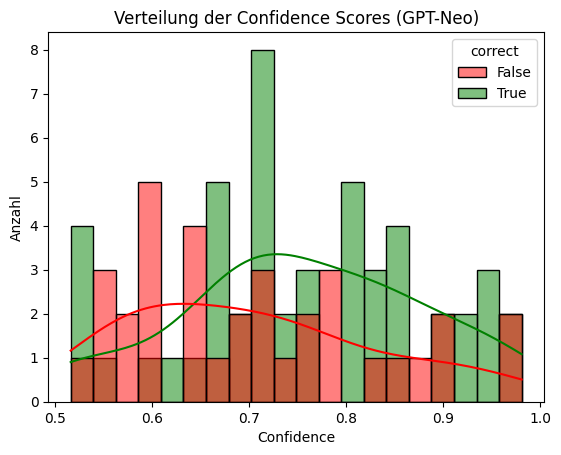

In [3]:
import seaborn as sns
import matplotlib.pyplot as plt
df["label_true"] = df["label"].apply(map_label)
df["correct"] = df["label_true"] == df["label_finetuned-deepseek-synthetic_normal"]

sns.histplot(data=df, x="confidence_finetuned-deepseek-synthetic_normal", hue="correct", bins=20, kde=True, palette=["red", "green"])
plt.title("Verteilung der Confidence Scores (GPT-Neo)")
plt.xlabel("Confidence")
plt.ylabel("Anzahl")
plt.show()

### Test Gesamt

In [1]:
import torch
import os
import pandas as pd
from transformers import (
    AutoTokenizer,
    AutoModelForCausalLM,
)
import torch.nn.functional as F
from tqdm import tqdm  # für den Ladebalken

# CUDA-Konfiguration
os.environ["CUDA_VISIBLE_DEVICES"] = "2"  # anpassen falls nötig
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Prompt-Template
def build_prompt(text):
    return (
        f"Statement: {text}\n"
        f"Task: Determine whether the statement is factually correct or fake news. Use only publicly verifiable and objective facts. Do not guess.\n"
        f"Answer with only one word: True or False.\n"
        f"Answer:"
    )

# Modell-Auswahl
models = {
    "finetuned-deepseek-synthetic_normal": "causal"
}

# Daten laden
df = pd.read_csv("preprocessed_test_cleaned.csv", sep="	")
df = df.iloc[:2000].copy()
statements = df["statement"].tolist()

# Ergebnis-Speicher
results = {name: [] for name in models}
confidences = {name: [] for name in models}

# Modelle durchlaufen
for model_name, model_type in models.items():
    print(f"\n📦 Lade Modell: {model_name} ({model_type})")

    tokenizer = AutoTokenizer.from_pretrained(model_name, use_fast=True)
    model = AutoModelForCausalLM.from_pretrained(model_name).to(device)
    model.eval()

    # Token IDs für " True" und " False" (mit führendem Leerzeichen!)
    true_token_id = tokenizer(" True", add_special_tokens=False)["input_ids"][0]
    false_token_id = tokenizer(" False", add_special_tokens=False)["input_ids"][0]

    # Verarbeitung mit Ladebalken
    for text in tqdm(statements, desc="🔍 Verarbeitung"):
        prompt = build_prompt(text)
        inputs = tokenizer(prompt, return_tensors="pt").to(device)

        with torch.no_grad():
            outputs = model(**inputs)
            logits = outputs.logits
            next_token_logits = logits[0, -1, :]  # nächstes Token
            probs = F.softmax(next_token_logits, dim=-1)

        # Wahrscheinlichkeiten abrufen
        prob_true = probs[true_token_id].item()
        prob_false = probs[false_token_id].item()

        if prob_true > prob_false:
            result = "True"
            confidence = prob_true
        else:
            result = "False"
            confidence = prob_false

        results[model_name].append(result)
        confidences[model_name].append(confidence)

# Ergebnisse ins DataFrame schreiben
for model_name in results:
    suffix = model_name.split("/")[-1]
    df[f"label_{suffix}"] = results[model_name]
    df[f"confidence_{suffix}"] = confidences[model_name]

# Ausgabe zur Kontrolle
print("\n✅ Verarbeitung abgeschlossen.")
df



📦 Lade Modell: finetuned-deepseek-synthetic_normal (causal)


2025-07-20 08:05:55.002962: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1752991555.021468   28666 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1752991555.026226   28666 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1752991555.040809   28666 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1752991555.040827   28666 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1752991555.040829   28666 computation_placer.cc:177] computation placer alr

Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

🔍 Verarbeitung: 100%|██████████| 1267/1267 [02:00<00:00, 10.52it/s]


✅ Verarbeitung abgeschlossen.


,label,statement,subjects,label_finetuned-deepseek-synthetic_normal,confidence_finetuned-deepseek-synthetic_normal
0,true,Building a wall on the U.S . Mexico border wil...,immigration,True,0.682901
1,false,Wisconsin is on pace to double the number of l...,jobs,True,0.651983
2,false,Says John McCain has done nothing to help the ...,"military,veterans,voting-record",False,0.992116
3,half-true,Suzanne Bonamici supports a plan that will cut...,"medicare,message-machine-2012,campaign-adverti...",False,0.926975
4,pants-fire,When asked by a reporter whether hes at the ce...,"campaign-finance,legal-issues,campaign-adverti...",True,0.604459
...,...,...,...,...,...
1262,half-true,Says his budget provides the highest state fun...,education,True,0.838493
1263,barely-true,Ive been here almost every day .,"civil-rights,crime,criminal-justice",True,0.705412
1264,barely-true,In the early 1980s Sen . Edward Kennedy secret...,"bipartisanship,congress,foreign-policy,history",True,0.583669
1265,barely-true,Says an EPA permit languished under Strickland...,"environment,government-efficiency",True,0.561753


In [2]:
import pandas as pd
from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
)

# Definiere deine Labelgruppen
true_labels = ["true", "mostly-true", "half-true"]
false_labels = ["barely-true", "false", "pants-fire", "pants-on-fire"]

# Mapping-Funktion: Normalisiert die Labels zu "True" oder "False"
def map_label(label):
    label = str(label).strip().lower()
    if label in true_labels:
        return "True"
    elif label in false_labels:
        return "False"
    else:
        return "False"  # Default für unbekannte Labels

# Wandle Ground Truth und Prediction in binäre Kategorien um
y_true = df["label"].apply(map_label)
y_pred = df["label_finetuned-deepseek-synthetic_normal"].apply(lambda x: map_label(x))

# Konfusionsmatrix
cm = confusion_matrix(y_true, y_pred, labels=["True", "False"])
print("Confusion Matrix (True/False):")
print(cm)

print(f"\nAccuracy:  {accuracy_score(y_true, y_pred)}")
print(f"Precision: {precision_score(y_true, y_pred, pos_label='True')}  (bezogen auf 'True')")
print(f"Recall:    {recall_score(y_true, y_pred, pos_label='True')}  (bezogen auf 'True')")
print(f"F1 Score:  {f1_score(y_true, y_pred, pos_label='True')}  (bezogen auf 'True')")

# Optionaler vollständiger Bericht
print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=["True", "False"]))


Confusion Matrix (True/False):
[[449 265]
 [239 314]]

Accuracy:  0.6022099447513812
Precision: 0.6526162790697675  (bezogen auf 'True')
Recall:    0.6288515406162465  (bezogen auf 'True')
F1 Score:  0.6405135520684736  (bezogen auf 'True')

Classification Report:
              precision    recall  f1-score   support

        True       0.54      0.57      0.55       553
       False       0.65      0.63      0.64       714

    accuracy                           0.60      1267
   macro avg       0.60      0.60      0.60      1267
weighted avg       0.60      0.60      0.60      1267



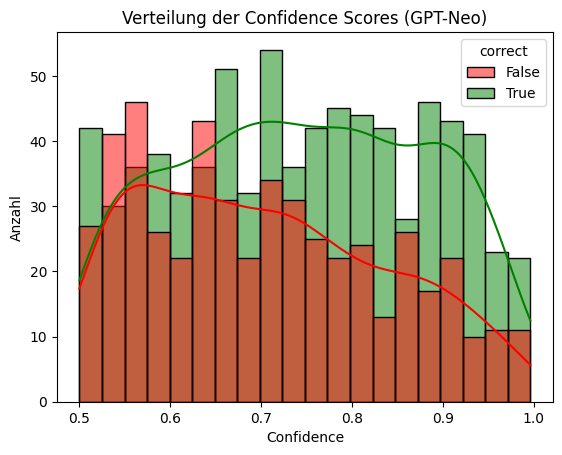

In [3]:
import seaborn as sns
import matplotlib.pyplot as plt
df["label_true"] = df["label"].apply(map_label)
df["correct"] = df["label_true"] == df["label_finetuned-deepseek-synthetic_normal"]

sns.histplot(data=df, x="confidence_finetuned-deepseek-synthetic_normal", hue="correct", bins=20, kde=True, palette=["red", "green"])
plt.title("Verteilung der Confidence Scores (GPT-Neo)")
plt.xlabel("Confidence")
plt.ylabel("Anzahl")
plt.show()

## Deepseek Subjects

In [1]:
from transformers import AutoTokenizer, AutoModelForCausalLM, TrainingArguments, Trainer, DataCollatorForLanguageModeling
from datasets import load_dataset, Dataset
from peft import get_peft_model, LoraConfig, TaskType
import torch
import os 

os.environ["CUDA_VISIBLE_DEVICES"] = "2,3"  # anpassen falls nötig
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model_name = "deepseek-ai/deepseek-llm-7b-base"
tokenizer = AutoTokenizer.from_pretrained(model_name, use_fast=True)
tokenizer.pad_token = tokenizer.eos_token  # Wichtig für CausalLM

# Beispiel-Daten laden (hier: lokal aus JSONL-Datei)
dataset = load_dataset("json", data_files={"train": "fine_tune_data_subjects_synthetic.jsonl"})["train"]

# Tokenisierung
def tokenize(example):
    return tokenizer(example["text"], truncation=True, padding="max_length", max_length=512)

tokenized_dataset = dataset.map(tokenize, batched=True)

# Modell mit LoRA initialisieren
base_model = AutoModelForCausalLM.from_pretrained(model_name, device_map="auto", torch_dtype=torch.float16)

peft_config = LoraConfig(
    r=8,
    lora_alpha=32,
    target_modules=["q_proj", "v_proj"],  # hängt vom Modell ab
    lora_dropout=0.05,
    bias="none",
    task_type=TaskType.CAUSAL_LM
)

model = get_peft_model(base_model, peft_config)

# Trainingskonfiguration
training_args = TrainingArguments(
    output_dir="./results",
    per_device_train_batch_size=2,
    gradient_accumulation_steps=4,
    num_train_epochs=3,
    logging_dir="./logs",
    save_total_limit=2,
    fp16=True,
    optim="adamw_torch",
    logging_steps=10,
    save_steps=100,
    learning_rate=2e-5,
    report_to="none",
)

data_collator = DataCollatorForLanguageModeling(tokenizer, mlm=False)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_dataset,
    tokenizer=tokenizer,
    data_collator=data_collator,
)

trainer.train()


2025-07-20 08:08:39.531970: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1752991719.555731   29117 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1752991719.563782   29117 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1752991719.584328   29117 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1752991719.584367   29117 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1752991719.584369   29117 computation_placer.cc:177] computation placer alr

Map:   0%|          | 0/1131 [00:00<?, ? examples/s]

Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

/tmp/ipykernel_29117/336616978.py:55: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(
No label_names provided for model class `PeftModelForCausalLM`. Since `PeftModel` hides base models input arguments, if label_names is not given, label_names can't be set automatically within `Trainer`. Note that empty label_names list will be used instead.


Step,Training Loss
10,2.699100
20,2.569400
30,2.486200
40,2.293800
50,2.069300
60,1.763600
70,1.545100
80,1.301600
90,1.138600
100,0.988000


TrainOutput(global_step=426, training_loss=0.842692278360537, metrics={'train_runtime': 420.0604, 'train_samples_per_second': 8.077, 'train_steps_per_second': 1.014, 'total_flos': 6.769792597465498e+16, 'train_loss': 0.842692278360537, 'epoch': 3.0})

In [2]:
trainer.save_model("finetuned-deepseek-synthetic_subjects")
tokenizer.save_pretrained("finetuned-deepseek-synthetic_subjects")

('finetuned-deepseek-synthetic_subjects/tokenizer_config.json',
 'finetuned-deepseek-synthetic_subjects/special_tokens_map.json',
 'finetuned-deepseek-synthetic_subjects/tokenizer.json')

### Test Healthcare

In [1]:
import torch
import os
import pandas as pd
from transformers import (
    AutoTokenizer,
    AutoModelForCausalLM,
    AutoModelForSeq2SeqLM,
    RobertaTokenizer,
    RobertaForSequenceClassification,
)
import torch.nn.functional as F
from tqdm import tqdm  # für Ladebalken

# CUDA Device
os.environ["CUDA_VISIBLE_DEVICES"] = "5"  # anpassen falls nötig
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Prompt-Template mit Statement + Subjects
def build_prompt(statement, subjects):
    return (
        f"Statement: {statement}\n"
        f"Task: Decide if the statement is factually correct. For better context, consider the subjects: {subjects}.\n"
        f"Answer only with True or False.\n"
        f"Example:\n"
        f"Statement: The sky is green.\n"
        f"Subjects: Weather, Nature\n"
        f"Answer: False\n"
        f"Statement: {statement}\n"
        f"Answer:"
    )

# Modelle
models = {
    "finetuned-deepseek-synthetic_subjects": "causal",
    # weitere Modelle können ergänzt werden
}

# Daten laden
df = pd.read_csv(r"healthcare_prompts_test.csv", sep=",")
df = df.iloc[:2000].copy()

statements = df["statement"].tolist()
subjects = df["subjects"].tolist()

# Ergebnisse speichern
results = {name: [] for name in models}
confidences = {name: [] for name in models}  # für Confidence Score

# Modelle durchlaufen
for model_name, model_type in models.items():
    print(f"Lade Modell: {model_name} ({model_type})")

    if model_type == "causal":
        tokenizer = AutoTokenizer.from_pretrained(model_name, use_fast=True)
        model = AutoModelForCausalLM.from_pretrained(model_name).to(device)
        model.eval()

        # Tokens mit führendem Leerzeichen, wichtig!
        true_token_id = tokenizer(" True", add_special_tokens=False)["input_ids"][0]
        false_token_id = tokenizer(" False", add_special_tokens=False)["input_ids"][0]

        # tqdm Ladebalken für Fortschritt
        for text, subj in tqdm(zip(statements, subjects), total=len(statements), desc="Processing causal model"):
            prompt = build_prompt(text, subj)
            inputs = tokenizer(prompt, return_tensors="pt", truncation=True).to(device)
            with torch.no_grad():
                outputs = model(**inputs)
                logits = outputs.logits
                next_token_logits = logits[0, -1, :]
                probs = F.softmax(next_token_logits, dim=-1)

            prob_true = probs[true_token_id].item()
            prob_false = probs[false_token_id].item()

            if prob_true > prob_false:
                result = "True"
                confidence = prob_true
            else:
                result = "False"
                confidence = prob_false

            results[model_name].append(result)
            confidences[model_name].append(confidence)

# Ergebnisse im DataFrame speichern
for model_name in results:
    suffix = model_name.split("/")[-1]
    df[f"label_{suffix}"] = results[model_name]
    # Nur für causal Modell Confidence speichern
    if model_name in confidences:
        df[f"confidence_{suffix}"] = confidences[model_name]

# Ausgabe DataFrame (z.B. df.head())
df.head


2025-07-20 08:21:18.086470: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1752992478.112083   29716 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1752992478.118767   29716 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1752992478.136562   29716 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1752992478.136586   29716 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1752992478.136588   29716 computation_placer.cc:177] computation placer alr

Lade Modell: finetuned-deepseek-synthetic_subjects (causal)


Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

Processing causal model: 100%|██████████| 83/83 [00:11<00:00,  7.48it/s]


<bound method NDFrame.head of           label                                          statement  \
0          true  Each year 18000 people die in America because ...   
1   mostly-true  Active duty males in the military are twice as...   
2     half-true  Says Thomas Jefferson said You might be able t...   
3   barely-true  Because of the federal health care law 300000 ...   
4   barely-true  Pre-existing conditions are covered under my (...   
..          ...                                                ...   
78        false  We had an amendment in the health care law tha...   
79         true  Texas has the highest rate of uninsured in the...   
80         true  Says 80 percent of the health care dollars are...   
81   pants-fire  Says state Rep . Sandy Pasch her recall oppone...   
82    half-true  Says Mark Pryorcut Medicare to pay for Obamaca...   

                     subjects label_finetuned-deepseek-synthetic_subjects  \
0                 health-care                       

In [2]:
import pandas as pd
from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
)

# Definiere deine Labelgruppen
true_labels = ["true", "mostly-true", "half-true"]
false_labels = ["barely-true", "false", "pants-fire", "pants-on-fire"]

# Mapping-Funktion: Normalisiert die Labels zu "True" oder "False"
def map_label(label):
    label = str(label).strip().lower()
    if label in true_labels:
        return "True"
    elif label in false_labels:
        return "False"
    else:
        return "False"  # Default für unbekannte Labels

# Wandle Ground Truth und Prediction in binäre Kategorien um
y_true = df["label"].apply(map_label)
y_pred = df["label_finetuned-deepseek-synthetic_subjects"].apply(lambda x: map_label(x))

# Konfusionsmatrix
cm = confusion_matrix(y_true, y_pred, labels=["True", "False"])
print("Confusion Matrix (True/False):")
print(cm)

print(f"\nAccuracy:  {accuracy_score(y_true, y_pred)}")
print(f"Precision: {precision_score(y_true, y_pred, pos_label='True')}  (bezogen auf 'True')")
print(f"Recall:    {recall_score(y_true, y_pred, pos_label='True')}  (bezogen auf 'True')")
print(f"F1 Score:  {f1_score(y_true, y_pred, pos_label='True')}  (bezogen auf 'True')")

# Optionaler vollständiger Bericht
print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=["True", "False"]))


Confusion Matrix (True/False):
[[12 30]
 [10 31]]

Accuracy:  0.5180722891566265
Precision: 0.5454545454545454  (bezogen auf 'True')
Recall:    0.2857142857142857  (bezogen auf 'True')
F1 Score:  0.375  (bezogen auf 'True')

Classification Report:
              precision    recall  f1-score   support

        True       0.51      0.76      0.61        41
       False       0.55      0.29      0.38        42

    accuracy                           0.52        83
   macro avg       0.53      0.52      0.49        83
weighted avg       0.53      0.52      0.49        83



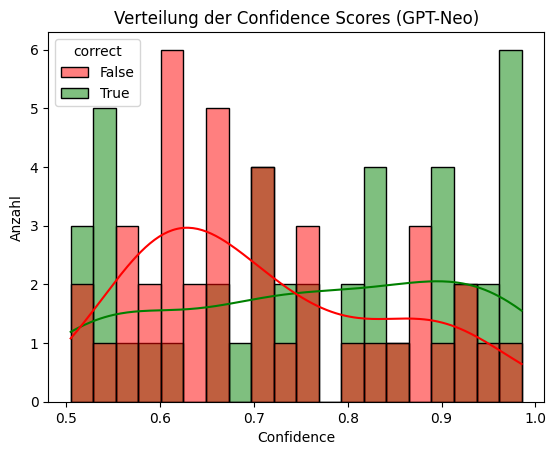

In [3]:
import seaborn as sns
import matplotlib.pyplot as plt
df["label_true"] = df["label"].apply(map_label)
df["correct"] = df["label_true"] == df["label_finetuned-deepseek-synthetic_subjects"]

sns.histplot(data=df, x="confidence_finetuned-deepseek-synthetic_subjects", hue="correct", bins=20, kde=True, palette=["red", "green"])
plt.title("Verteilung der Confidence Scores (GPT-Neo)")
plt.xlabel("Confidence")
plt.ylabel("Anzahl")
plt.show()

### Test Gesamt

In [1]:
import torch
import os
import pandas as pd
from transformers import (
    AutoTokenizer,
    AutoModelForCausalLM,
    AutoModelForSeq2SeqLM,
    RobertaTokenizer,
    RobertaForSequenceClassification,
)
import torch.nn.functional as F
from tqdm import tqdm  # für Ladebalken

# CUDA Device
os.environ["CUDA_VISIBLE_DEVICES"] = "5"  # anpassen falls nötig
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Prompt-Template mit Statement + Subjects
def build_prompt(statement, subjects):
    return (
        f"Statement: {statement}\n"
        f"Task: Decide if the statement is factually correct. For better context, consider the subjects: {subjects}.\n"
        f"Answer only with True or False.\n"
        f"Example:\n"
        f"Statement: The sky is green.\n"
        f"Subjects: Weather, Nature\n"
        f"Answer: False\n"
        f"Statement: {statement}\n"
        f"Answer:"
    )

# Modelle
models = {
    "finetuned-deepseek-synthetic_subjects": "causal",
    # weitere Modelle können ergänzt werden
}

# Daten laden
df = pd.read_csv(r"preprocessed_test_cleaned.csv", sep="\t")
df = df.iloc[:2000].copy()

statements = df["statement"].tolist()
subjects = df["subjects"].tolist()

# Ergebnisse speichern
results = {name: [] for name in models}
confidences = {name: [] for name in models}  # für Confidence Score

# Modelle durchlaufen
for model_name, model_type in models.items():
    print(f"Lade Modell: {model_name} ({model_type})")

    if model_type == "causal":
        tokenizer = AutoTokenizer.from_pretrained(model_name, use_fast=True)
        model = AutoModelForCausalLM.from_pretrained(model_name).to(device)
        model.eval()

        # Tokens mit führendem Leerzeichen, wichtig!
        true_token_id = tokenizer(" True", add_special_tokens=False)["input_ids"][0]
        false_token_id = tokenizer(" False", add_special_tokens=False)["input_ids"][0]

        # tqdm Ladebalken für Fortschritt
        for text, subj in tqdm(zip(statements, subjects), total=len(statements), desc="Processing causal model"):
            prompt = build_prompt(text, subj)
            inputs = tokenizer(prompt, return_tensors="pt", truncation=True).to(device)
            with torch.no_grad():
                outputs = model(**inputs)
                logits = outputs.logits
                next_token_logits = logits[0, -1, :]
                probs = F.softmax(next_token_logits, dim=-1)

            prob_true = probs[true_token_id].item()
            prob_false = probs[false_token_id].item()

            if prob_true > prob_false:
                result = "True"
                confidence = prob_true
            else:
                result = "False"
                confidence = prob_false

            results[model_name].append(result)
            confidences[model_name].append(confidence)

# Ergebnisse im DataFrame speichern
for model_name in results:
    suffix = model_name.split("/")[-1]
    df[f"label_{suffix}"] = results[model_name]
    # Nur für causal Modell Confidence speichern
    if model_name in confidences:
        df[f"confidence_{suffix}"] = confidences[model_name]

# Ausgabe DataFrame (z.B. df.head())
df.head


2025-07-20 08:22:14.372434: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1752992534.396386   30146 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1752992534.402801   30146 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1752992534.422880   30146 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1752992534.422919   30146 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1752992534.422921   30146 computation_placer.cc:177] computation placer alr

Lade Modell: finetuned-deepseek-synthetic_subjects (causal)


Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

Processing causal model: 100%|██████████| 1267/1267 [02:43<00:00,  7.77it/s]


<bound method NDFrame.head of             label                                          statement  \
0            true  Building a wall on the U.S . Mexico border wil...   
1           false  Wisconsin is on pace to double the number of l...   
2           false  Says John McCain has done nothing to help the ...   
3       half-true  Suzanne Bonamici supports a plan that will cut...   
4      pants-fire  When asked by a reporter whether hes at the ce...   
...           ...                                                ...   
1262    half-true  Says his budget provides the highest state fun...   
1263  barely-true                   Ive been here almost every day .   
1264  barely-true  In the early 1980s Sen . Edward Kennedy secret...   
1265  barely-true  Says an EPA permit languished under Strickland...   
1266        false  Says the governor is going around the state ta...   

                                               subjects  \
0                                           im

In [2]:
import pandas as pd
from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
)

# Definiere deine Labelgruppen
true_labels = ["true", "mostly-true", "half-true"]
false_labels = ["barely-true", "false", "pants-fire", "pants-on-fire"]

# Mapping-Funktion: Normalisiert die Labels zu "True" oder "False"
def map_label(label):
    label = str(label).strip().lower()
    if label in true_labels:
        return "True"
    elif label in false_labels:
        return "False"
    else:
        return "False"  # Default für unbekannte Labels

# Wandle Ground Truth und Prediction in binäre Kategorien um
y_true = df["label"].apply(map_label)
y_pred = df["label_finetuned-deepseek-synthetic_subjects"].apply(lambda x: map_label(x))

# Konfusionsmatrix
cm = confusion_matrix(y_true, y_pred, labels=["True", "False"])
print("Confusion Matrix (True/False):")
print(cm)

print(f"\nAccuracy:  {accuracy_score(y_true, y_pred)}")
print(f"Precision: {precision_score(y_true, y_pred, pos_label='True')}  (bezogen auf 'True')")
print(f"Recall:    {recall_score(y_true, y_pred, pos_label='True')}  (bezogen auf 'True')")
print(f"F1 Score:  {f1_score(y_true, y_pred, pos_label='True')}  (bezogen auf 'True')")

# Optionaler vollständiger Bericht
print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=["True", "False"]))


Confusion Matrix (True/False):
[[280 434]
 [158 395]]

Accuracy:  0.5327545382794001
Precision: 0.639269406392694  (bezogen auf 'True')
Recall:    0.39215686274509803  (bezogen auf 'True')
F1 Score:  0.4861111111111111  (bezogen auf 'True')

Classification Report:
              precision    recall  f1-score   support

        True       0.48      0.71      0.57       553
       False       0.64      0.39      0.49       714

    accuracy                           0.53      1267
   macro avg       0.56      0.55      0.53      1267
weighted avg       0.57      0.53      0.52      1267



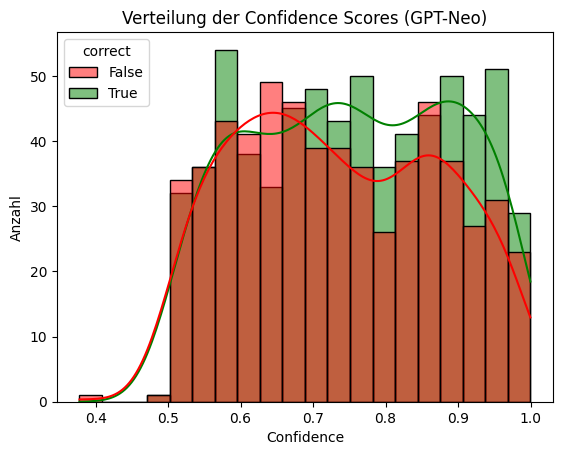

In [3]:
import seaborn as sns
import matplotlib.pyplot as plt
df["label_true"] = df["label"].apply(map_label)
df["correct"] = df["label_true"] == df["label_finetuned-deepseek-synthetic_subjects"]

sns.histplot(data=df, x="confidence_finetuned-deepseek-synthetic_subjects", hue="correct", bins=20, kde=True, palette=["red", "green"])
plt.title("Verteilung der Confidence Scores (GPT-Neo)")
plt.xlabel("Confidence")
plt.ylabel("Anzahl")
plt.show()

# Train + Synthetisch

In [5]:
import pandas as pd

# === 1. Dateien laden ===

# Datei 1: enthält vermutlich Spalten mit Tabs oder Leerzeichen getrennt
df1 = pd.read_csv("preprocessed_train_cleaned.csv", sep="\t", engine="python", names=["label", "statement", "subject"], skiprows=1)

# Datei 2: klassische CSV
df2 = pd.read_csv("bereinigt_ohne_duplikate.csv")

# Einheitliche Spaltennamen (für df2)
df2.columns = df2.columns.str.lower()

# === 2. Label-Mapping anwenden (für df1) ===

label_map = {
    "true": "True",
    "mostly-true": "True",
    "half-true": "True",
    "barely-true": "False",
    "false": "False",
    "pants-fire": "False"
}

# Labels in df1 vereinheitlichen
df1["label"] = df1["label"].astype(str).str.strip().str.lower().map(label_map)

# Labels in df2 (sicherstellen, dass sie richtig formatiert sind)
df2["label"] = df2["label"].astype(str).str.strip().str.title()

# === 3. Spaltenreihenfolge angleichen ===

df1 = df1[["statement", "label", "subject"]]
df2 = df2[["statement", "label", "subject"]]

# === 4. Zusammenführen ===

combined_df = pd.concat([df1, df2], ignore_index=True)

# === 5. Durchmischen ===

combined_df = combined_df.sample(frac=1, random_state=42).reset_index(drop=True)

# === 6. Ergebnis speichern ===

combined_df.to_csv("kombiniert_und_gemischt.csv", index=False)
print(f"✅ Kombinierte Datei gespeichert mit {len(combined_df)} Zeilen.")


✅ Kombinierte Datei gespeichert mit 11373 Zeilen.


In [6]:
combined_df

,statement,label,subject
0,In the 1950s A lot of people got rich and they...,True,taxes
1,An image in a ChrisAbele TV ad depicts wealthy...,False,environment
2,41200 veterans in Florida dont have health car...,True,"health-care,medicaid,veterans"
3,Rhode Island has the worst maintained bridges ...,True,"state-budget,state-finances,transportation"
4,Some nations allow citizens to propose legis n...,False,Politics
...,...,...,...
11368,Diversification reduces investment risk .,True,Economy
11369,On the mosque near ground zero .,True,religion
11370,Louie Gohmert of Texas blamed the mass shootin...,False,"crime,pundits,religion"
11371,The Governor did not consult members of his ow...,False,transportation


## Llama Normal

In [7]:
import pandas as pd
import json

# CSV laden
df = pd.read_csv("kombiniert_und_gemischt.csv")

# Mapping der Labels in "True"/"False"
label_map = {
    "true": "True",
    "mostly-true": "True",
    "half-true": "True",
    "barely-true": "False",
    "false": "False",
    "pants-fire": "False"
}

# Prompt-Template-Funktion
def create_prompt(statement, label):
    return {
        "text": (
            f"Statement: {statement}\n"
            f"Task: Determine whether the statement is factually correct or fake news. "
            f"Use only publicly verifiable and objective facts. Do not guess.\n"
            f"Answer with only one word: True or False.\n"
            f"Answer: {label}"
        )
    }

# Prompt-Daten erstellen
jsonl_data = []
for _, row in df.iterrows():
    raw_label = str(row["label"]).strip().lower()
    mapped_label = label_map.get(raw_label)

    if mapped_label:  # Nur verarbeitbare Labels
        prompt = create_prompt(row["statement"], mapped_label)
        jsonl_data.append(prompt)

# Als JSONL-Datei speichern
with open("fine_tune_data_synthetic+train.jsonl", "w", encoding="utf-8") as f:
    for entry in jsonl_data:
        f.write(json.dumps(entry, ensure_ascii=False) + "\n")

print(f"✅ {len(jsonl_data)} Beispiele gespeichert in 'fine_tune_data.jsonl'")


✅ 11371 Beispiele gespeichert in 'fine_tune_data.jsonl'


In [1]:
from transformers import AutoTokenizer, AutoModelForCausalLM, TrainingArguments, Trainer, DataCollatorForLanguageModeling
from datasets import load_dataset, Dataset
from peft import get_peft_model, LoraConfig, TaskType
import torch
import os 

os.environ["CUDA_VISIBLE_DEVICES"] = "1,2"  # anpassen falls nötig
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model_name = "meta-llama/Llama-3.1-8B-Instruct"
tokenizer = AutoTokenizer.from_pretrained(model_name, use_fast=True)
tokenizer.pad_token = tokenizer.eos_token  # Wichtig für CausalLM

# Beispiel-Daten laden (hier: lokal aus JSONL-Datei)
dataset = load_dataset("json", data_files={"train": "fine_tune_data_synthetic+train.jsonl"})["train"]

# Tokenisierung
def tokenize(example):
    return tokenizer(example["text"], truncation=True, padding="max_length", max_length=512)

tokenized_dataset = dataset.map(tokenize, batched=True)

# Modell mit LoRA initialisieren
base_model = AutoModelForCausalLM.from_pretrained(model_name, device_map="auto", torch_dtype=torch.float16)

peft_config = LoraConfig(
    r=8,
    lora_alpha=32,
    target_modules=["q_proj", "v_proj"],  # hängt vom Modell ab
    lora_dropout=0.05,
    bias="none",
    task_type=TaskType.CAUSAL_LM
)

model = get_peft_model(base_model, peft_config)

# Trainingskonfiguration
training_args = TrainingArguments(
    output_dir="./results",
    per_device_train_batch_size=2,
    gradient_accumulation_steps=4,
    num_train_epochs=3,
    logging_dir="./logs",
    save_total_limit=2,
    fp16=True,
    optim="adamw_torch",
    logging_steps=10,
    save_steps=100,
    learning_rate=2e-5,
    report_to="none",
)

data_collator = DataCollatorForLanguageModeling(tokenizer, mlm=False)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_dataset,
    tokenizer=tokenizer,
    data_collator=data_collator,
)

trainer.train()


2025-07-20 08:48:36.946491: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1752994116.971953   31020 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1752994116.979223   31020 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1752994116.999507   31020 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1752994116.999546   31020 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1752994116.999548   31020 computation_placer.cc:177] computation placer alr

Loading checkpoint shards:   0%|          | 0/4 [00:00<?, ?it/s]

/tmp/ipykernel_31020/58243765.py:55: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(
No label_names provided for model class `PeftModelForCausalLM`. Since `PeftModel` hides base models input arguments, if label_names is not given, label_names can't be set automatically within `Trainer`. Note that empty label_names list will be used instead.


Step,Training Loss
10,3.159000
20,2.957000
30,2.656700
40,2.318500
50,1.964200
60,1.547900
70,1.363400
80,1.299000
90,1.215000
100,1.236600


/home/jovyan/.local/lib/python3.10/site-packages/peft/utils/other.py:1221: UserWarning: Unable to fetch remote file due to the following error 401 Client Error. (Request ID: Root=1-687c91ca-0f1684ba1187782859d18d0a;551bb80d-8237-4ca4-86be-9036781a0268)

Cannot access gated repo for url https://huggingface.co/meta-llama/Llama-3.1-8B-Instruct/resolve/main/config.json.
Access to model meta-llama/Llama-3.1-8B-Instruct is restricted. You must have access to it and be authenticated to access it. Please log in. - silently ignoring the lookup for the file config.json in meta-llama/Llama-3.1-8B-Instruct.
  warnings.warn(
/home/jovyan/.local/lib/python3.10/site-packages/peft/utils/save_and_load.py:238: UserWarning: Could not find a config file in meta-llama/Llama-3.1-8B-Instruct - will assume that the vocabulary was not modified.
  warnings.warn(
/home/jovyan/.local/lib/python3.10/site-packages/peft/utils/other.py:1221: UserWarning: Unable to fetch remote file due to the following error 401 Clie

KeyboardInterrupt: 

In [2]:
trainer.save_model("finetuned-llama3-synthetic+train_normal")
tokenizer.save_pretrained("finetuned-llama3-synthetic+train_normal")


/home/jovyan/.local/lib/python3.10/site-packages/peft/utils/other.py:1221: UserWarning: Unable to fetch remote file due to the following error 401 Client Error. (Request ID: Root=1-687c9aff-329d4b12546f35c24b04ac19;e6909600-21b5-45bc-8461-f200b736641f)

Cannot access gated repo for url https://huggingface.co/meta-llama/Llama-3.1-8B-Instruct/resolve/main/config.json.
Access to model meta-llama/Llama-3.1-8B-Instruct is restricted. You must have access to it and be authenticated to access it. Please log in. - silently ignoring the lookup for the file config.json in meta-llama/Llama-3.1-8B-Instruct.
  warnings.warn(
/home/jovyan/.local/lib/python3.10/site-packages/peft/utils/save_and_load.py:238: UserWarning: Could not find a config file in meta-llama/Llama-3.1-8B-Instruct - will assume that the vocabulary was not modified.
  warnings.warn(


('finetuned-llama3-synthetic+train_normal/tokenizer_config.json',
 'finetuned-llama3-synthetic+train_normal/special_tokens_map.json',
 'finetuned-llama3-synthetic+train_normal/chat_template.jinja',
 'finetuned-llama3-synthetic+train_normal/tokenizer.json')

### Test Healthcare

In [1]:
import torch
import os
import pandas as pd
from transformers import (
    AutoTokenizer,
    AutoModelForCausalLM,
)
import torch.nn.functional as F
from tqdm import tqdm  # für den Ladebalken

# CUDA-Konfiguration
os.environ["CUDA_VISIBLE_DEVICES"] = "2"  # anpassen falls nötig
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Prompt-Template
def build_prompt(text):
    return (
        f"Statement: {text}\n"
        f"Task: Determine whether the statement is factually correct or fake news. Use only publicly verifiable and objective facts. Do not guess.\n"
        f"Answer with only one word: True or False.\n"
        f"Answer:"
    )

# Modell-Auswahl
models = {
    "finetuned-llama3-synthetic+train_normal": "causal"
}

# Daten laden
df = pd.read_csv("healthcare_prompts_test.csv", sep=",")
df = df.iloc[:2000].copy()
statements = df["statement"].tolist()

# Ergebnis-Speicher
results = {name: [] for name in models}
confidences = {name: [] for name in models}

# Modelle durchlaufen
for model_name, model_type in models.items():
    print(f"\n📦 Lade Modell: {model_name} ({model_type})")

    tokenizer = AutoTokenizer.from_pretrained(model_name, use_fast=True)
    model = AutoModelForCausalLM.from_pretrained(model_name).to(device)
    model.eval()

    # Token IDs für " True" und " False" (mit führendem Leerzeichen!)
    true_token_id = tokenizer(" True", add_special_tokens=False)["input_ids"][0]
    false_token_id = tokenizer(" False", add_special_tokens=False)["input_ids"][0]

    # Verarbeitung mit Ladebalken
    for text in tqdm(statements, desc="🔍 Verarbeitung"):
        prompt = build_prompt(text)
        inputs = tokenizer(prompt, return_tensors="pt").to(device)

        with torch.no_grad():
            outputs = model(**inputs)
            logits = outputs.logits
            next_token_logits = logits[0, -1, :]  # nächstes Token
            probs = F.softmax(next_token_logits, dim=-1)

        # Wahrscheinlichkeiten abrufen
        prob_true = probs[true_token_id].item()
        prob_false = probs[false_token_id].item()

        if prob_true > prob_false:
            result = "True"
            confidence = prob_true
        else:
            result = "False"
            confidence = prob_false

        results[model_name].append(result)
        confidences[model_name].append(confidence)

# Ergebnisse ins DataFrame schreiben
for model_name in results:
    suffix = model_name.split("/")[-1]
    df[f"label_{suffix}"] = results[model_name]
    df[f"confidence_{suffix}"] = confidences[model_name]

# Ausgabe zur Kontrolle
print("\n✅ Verarbeitung abgeschlossen.")
df



📦 Lade Modell: finetuned-llama3-synthetic+train_normal (causal)


2025-07-20 09:30:50.747710: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1752996650.767247   31838 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1752996650.771975   31838 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1752996650.787205   31838 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1752996650.787215   31838 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1752996650.787218   31838 computation_placer.cc:177] computation placer alr

Loading checkpoint shards:   0%|          | 0/4 [00:00<?, ?it/s]

🔍 Verarbeitung: 100%|██████████| 83/83 [00:10<00:00,  8.23it/s]


✅ Verarbeitung abgeschlossen.


,label,statement,subjects,label_finetuned-llama3-synthetic+train_normal,confidence_finetuned-llama3-synthetic+train_normal
0,true,Each year 18000 people die in America because ...,health-care,True,0.700896
1,mostly-true,Active duty males in the military are twice as...,"health-care,military",True,0.784856
2,half-true,Says Thomas Jefferson said You might be able t...,"health-care,history",False,0.735789
3,barely-true,Because of the federal health care law 300000 ...,health-care,False,0.511046
4,barely-true,Pre-existing conditions are covered under my (...,"debates,health-care",True,0.510685
...,...,...,...,...,...
78,false,We had an amendment in the health care law tha...,"education,health-care",False,0.813544
79,true,Texas has the highest rate of uninsured in the...,health-care,True,0.956551
80,true,Says 80 percent of the health care dollars are...,"health-care,public-health",True,0.820271
81,pants-fire,Says state Rep . Sandy Pasch her recall oppone...,"health-care,unions",False,0.582591


In [2]:
import pandas as pd
from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
)

# Definiere deine Labelgruppen
true_labels = ["true", "mostly-true", "half-true"]
false_labels = ["barely-true", "false", "pants-fire", "pants-on-fire"]

# Mapping-Funktion: Normalisiert die Labels zu "True" oder "False"
def map_label(label):
    label = str(label).strip().lower()
    if label in true_labels:
        return "True"
    elif label in false_labels:
        return "False"
    else:
        return "False"  # Default für unbekannte Labels

# Wandle Ground Truth und Prediction in binäre Kategorien um
y_true = df["label"].apply(map_label)
y_pred = df["label_finetuned-llama3-synthetic+train_normal"].apply(lambda x: map_label(x))

# Konfusionsmatrix
cm = confusion_matrix(y_true, y_pred, labels=["True", "False"])
print("Confusion Matrix (True/False):")
print(cm)

print(f"\nAccuracy:  {accuracy_score(y_true, y_pred)}")
print(f"Precision: {precision_score(y_true, y_pred, pos_label='True')}  (bezogen auf 'True')")
print(f"Recall:    {recall_score(y_true, y_pred, pos_label='True')}  (bezogen auf 'True')")
print(f"F1 Score:  {f1_score(y_true, y_pred, pos_label='True')}  (bezogen auf 'True')")

# Optionaler vollständiger Bericht
print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=["True", "False"]))


Confusion Matrix (True/False):
[[31 11]
 [19 22]]

Accuracy:  0.6385542168674698
Precision: 0.62  (bezogen auf 'True')
Recall:    0.7380952380952381  (bezogen auf 'True')
F1 Score:  0.6739130434782609  (bezogen auf 'True')

Classification Report:
              precision    recall  f1-score   support

        True       0.67      0.54      0.59        41
       False       0.62      0.74      0.67        42

    accuracy                           0.64        83
   macro avg       0.64      0.64      0.63        83
weighted avg       0.64      0.64      0.63        83



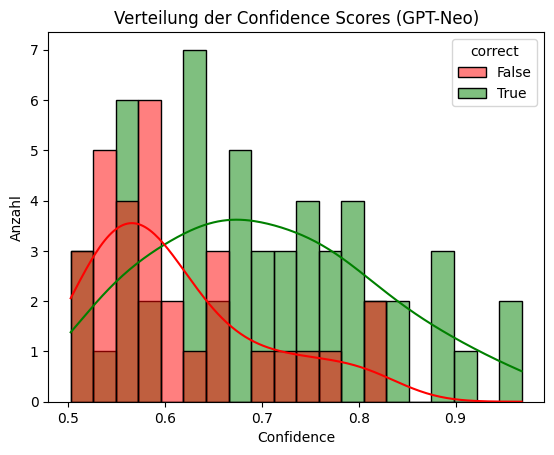

In [3]:
import seaborn as sns
import matplotlib.pyplot as plt
df["label_true"] = df["label"].apply(map_label)
df["correct"] = df["label_true"] == df["label_finetuned-llama3-synthetic+train_normal"]

sns.histplot(data=df, x="confidence_finetuned-llama3-synthetic+train_normal", hue="correct", bins=20, kde=True, palette=["red", "green"])
plt.title("Verteilung der Confidence Scores (GPT-Neo)")
plt.xlabel("Confidence")
plt.ylabel("Anzahl")
plt.show()

### Test Gesamt

In [1]:
import torch
import os
import pandas as pd
from transformers import (
    AutoTokenizer,
    AutoModelForCausalLM,
)
import torch.nn.functional as F
from tqdm import tqdm  # für den Ladebalken

# CUDA-Konfiguration
os.environ["CUDA_VISIBLE_DEVICES"] = "2"  # anpassen falls nötig
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Prompt-Template
def build_prompt(text):
    return (
        f"Statement: {text}\n"
        f"Task: Determine whether the statement is factually correct or fake news. Use only publicly verifiable and objective facts. Do not guess.\n"
        f"Answer with only one word: True or False.\n"
        f"Answer:"
    )

# Modell-Auswahl
models = {
    "finetuned-llama3-synthetic+train_normal": "causal"
}

# Daten laden
df = pd.read_csv("preprocessed_test_cleaned.csv", sep="	")
df = df.iloc[:2000].copy()
statements = df["statement"].tolist()

# Ergebnis-Speicher
results = {name: [] for name in models}
confidences = {name: [] for name in models}

# Modelle durchlaufen
for model_name, model_type in models.items():
    print(f"\n📦 Lade Modell: {model_name} ({model_type})")

    tokenizer = AutoTokenizer.from_pretrained(model_name, use_fast=True)
    model = AutoModelForCausalLM.from_pretrained(model_name).to(device)
    model.eval()

    # Token IDs für " True" und " False" (mit führendem Leerzeichen!)
    true_token_id = tokenizer(" True", add_special_tokens=False)["input_ids"][0]
    false_token_id = tokenizer(" False", add_special_tokens=False)["input_ids"][0]

    # Verarbeitung mit Ladebalken
    for text in tqdm(statements, desc="🔍 Verarbeitung"):
        prompt = build_prompt(text)
        inputs = tokenizer(prompt, return_tensors="pt").to(device)

        with torch.no_grad():
            outputs = model(**inputs)
            logits = outputs.logits
            next_token_logits = logits[0, -1, :]  # nächstes Token
            probs = F.softmax(next_token_logits, dim=-1)

        # Wahrscheinlichkeiten abrufen
        prob_true = probs[true_token_id].item()
        prob_false = probs[false_token_id].item()

        if prob_true > prob_false:
            result = "True"
            confidence = prob_true
        else:
            result = "False"
            confidence = prob_false

        results[model_name].append(result)
        confidences[model_name].append(confidence)

# Ergebnisse ins DataFrame schreiben
for model_name in results:
    suffix = model_name.split("/")[-1]
    df[f"label_{suffix}"] = results[model_name]
    df[f"confidence_{suffix}"] = confidences[model_name]

# Ausgabe zur Kontrolle
print("\n✅ Verarbeitung abgeschlossen.")
df



📦 Lade Modell: finetuned-llama3-synthetic+train_normal (causal)


2025-07-20 09:31:46.463029: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1752996706.484161   32264 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1752996706.489766   32264 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1752996706.505334   32264 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1752996706.505359   32264 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1752996706.505361   32264 computation_placer.cc:177] computation placer alr

Loading checkpoint shards:   0%|          | 0/4 [00:00<?, ?it/s]

🔍 Verarbeitung: 100%|██████████| 1267/1267 [02:14<00:00,  9.45it/s]


✅ Verarbeitung abgeschlossen.


,label,statement,subjects,label_finetuned-llama3-synthetic+train_normal,confidence_finetuned-llama3-synthetic+train_normal
0,true,Building a wall on the U.S . Mexico border wil...,immigration,True,0.559185
1,false,Wisconsin is on pace to double the number of l...,jobs,True,0.553784
2,false,Says John McCain has done nothing to help the ...,"military,veterans,voting-record",False,0.554689
3,half-true,Suzanne Bonamici supports a plan that will cut...,"medicare,message-machine-2012,campaign-adverti...",False,0.692794
4,pants-fire,When asked by a reporter whether hes at the ce...,"campaign-finance,legal-issues,campaign-adverti...",True,0.530277
...,...,...,...,...,...
1262,half-true,Says his budget provides the highest state fun...,education,True,0.741240
1263,barely-true,Ive been here almost every day .,"civil-rights,crime,criminal-justice",True,0.580227
1264,barely-true,In the early 1980s Sen . Edward Kennedy secret...,"bipartisanship,congress,foreign-policy,history",True,0.685516
1265,barely-true,Says an EPA permit languished under Strickland...,"environment,government-efficiency",True,0.604275


In [2]:
import pandas as pd
from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
)

# Definiere deine Labelgruppen
true_labels = ["true", "mostly-true", "half-true"]
false_labels = ["barely-true", "false", "pants-fire", "pants-on-fire"]

# Mapping-Funktion: Normalisiert die Labels zu "True" oder "False"
def map_label(label):
    label = str(label).strip().lower()
    if label in true_labels:
        return "True"
    elif label in false_labels:
        return "False"
    else:
        return "False"  # Default für unbekannte Labels

# Wandle Ground Truth und Prediction in binäre Kategorien um
y_true = df["label"].apply(map_label)
y_pred = df["label_finetuned-llama3-synthetic+train_normal"].apply(lambda x: map_label(x))

# Konfusionsmatrix
cm = confusion_matrix(y_true, y_pred, labels=["True", "False"])
print("Confusion Matrix (True/False):")
print(cm)

print(f"\nAccuracy:  {accuracy_score(y_true, y_pred)}")
print(f"Precision: {precision_score(y_true, y_pred, pos_label='True')}  (bezogen auf 'True')")
print(f"Recall:    {recall_score(y_true, y_pred, pos_label='True')}  (bezogen auf 'True')")
print(f"F1 Score:  {f1_score(y_true, y_pred, pos_label='True')}  (bezogen auf 'True')")

# Optionaler vollständiger Bericht
print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=["True", "False"]))


Confusion Matrix (True/False):
[[588 126]
 [324 229]]

Accuracy:  0.6448303078137332
Precision: 0.6447368421052632  (bezogen auf 'True')
Recall:    0.8235294117647058  (bezogen auf 'True')
F1 Score:  0.7232472324723247  (bezogen auf 'True')

Classification Report:
              precision    recall  f1-score   support

        True       0.65      0.41      0.50       553
       False       0.64      0.82      0.72       714

    accuracy                           0.64      1267
   macro avg       0.64      0.62      0.61      1267
weighted avg       0.64      0.64      0.63      1267



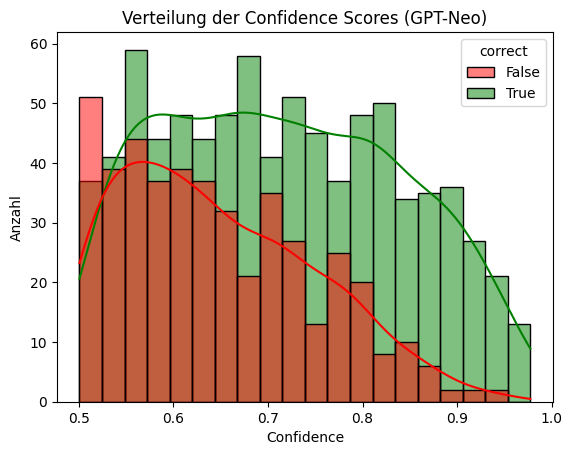

In [3]:
import seaborn as sns
import matplotlib.pyplot as plt
df["label_true"] = df["label"].apply(map_label)
df["correct"] = df["label_true"] == df["label_finetuned-llama3-synthetic+train_normal"]

sns.histplot(data=df, x="confidence_finetuned-llama3-synthetic+train_normal", hue="correct", bins=20, kde=True, palette=["red", "green"])
plt.title("Verteilung der Confidence Scores (GPT-Neo)")
plt.xlabel("Confidence")
plt.ylabel("Anzahl")
plt.show()

## Llama Subjects

In [5]:
import pandas as pd
import json

# CSV laden
df = pd.read_csv("kombiniert_und_gemischt.csv")  # sep="\t" entfernt, falls Komma verwendet wird

# Label-Mapping in "True"/"False"
label_map = {
    "true": "True",
    "mostly-true": "True",
    "half-true": "True",
    "barely-true": "False",
    "false": "False",
    "pants-fire": "False"
}

# Prompt-Template mit Subjects und Beispiel
def create_prompt(statement, label, subjects):
    formatted_subjects = ", ".join([s.strip().title() for s in str(subjects).split(",")])
    return {
        "text": (
            f"Statement: {statement}\n"
            f"Task: Decide if the statement is factually correct. For better context, consider the subjects: {formatted_subjects}.\n"
            f"Answer only with True or False.\n"
            f"Example:\n"
            f"Statement: The sky is green.\n"
            f"Subjects: Weather, Nature\n"
            f"Answer: False\n"
            f"Statement: {statement}\n"
            f"Answer: {label}"
        )
    }

# Prompt-Daten erstellen
jsonl_data = []
for _, row in df.iterrows():
    raw_label = str(row["label"]).strip().lower()
    mapped_label = label_map.get(raw_label)

    if mapped_label:
        prompt = create_prompt(row["statement"], mapped_label, row["subject"])
        jsonl_data.append(prompt)

# Als JSONL-Datei speichern
with open("fine_tune_data_subjects_synthetic+train.jsonl", "w", encoding="utf-8") as f:
    for entry in jsonl_data:
        f.write(json.dumps(entry, ensure_ascii=False) + "\n")

print(f"✅ {len(jsonl_data)} Prompts gespeichert in 'fine_tune_data_subjects.jsonl'")


✅ 11371 Prompts gespeichert in 'fine_tune_data_subjects.jsonl'


In [1]:
from transformers import AutoTokenizer, AutoModelForCausalLM, TrainingArguments, Trainer, DataCollatorForLanguageModeling
from datasets import load_dataset, Dataset
from peft import get_peft_model, LoraConfig, TaskType
import torch
import os 

os.environ["CUDA_VISIBLE_DEVICES"] = "2,3"  # anpassen falls nötig
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model_name = "meta-llama/Llama-3.1-8B-Instruct"
tokenizer = AutoTokenizer.from_pretrained(model_name, use_fast=True)
tokenizer.pad_token = tokenizer.eos_token  # Wichtig für CausalLM

# Beispiel-Daten laden (hier: lokal aus JSONL-Datei)
dataset = load_dataset("json", data_files={"train": "fine_tune_data_subjects_synthetic+train.jsonl"})["train"]

# Tokenisierung
def tokenize(example):
    return tokenizer(example["text"], truncation=True, padding="max_length", max_length=512)

tokenized_dataset = dataset.map(tokenize, batched=True)

# Modell mit LoRA initialisieren
base_model = AutoModelForCausalLM.from_pretrained(model_name, device_map="auto", torch_dtype=torch.float16)

peft_config = LoraConfig(
    r=8,
    lora_alpha=32,
    target_modules=["q_proj", "v_proj"],  # hängt vom Modell ab
    lora_dropout=0.05,
    bias="none",
    task_type=TaskType.CAUSAL_LM
)

model = get_peft_model(base_model, peft_config)

# Trainingskonfiguration
training_args = TrainingArguments(
    output_dir="./results",
    per_device_train_batch_size=2,
    gradient_accumulation_steps=4,
    num_train_epochs=3,
    logging_dir="./logs",
    save_total_limit=2,
    fp16=True,
    optim="adamw_torch",
    logging_steps=10,
    save_steps=100,
    learning_rate=2e-5,
    report_to="none",
    max_steps=1500
)

data_collator = DataCollatorForLanguageModeling(tokenizer, mlm=False)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_dataset,
    tokenizer=tokenizer,
    data_collator=data_collator,
)

trainer.train()


2025-07-20 09:35:42.491372: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1752996942.513195   32785 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1752996942.520246   32785 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1752996942.538878   32785 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1752996942.538905   32785 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1752996942.538907   32785 computation_placer.cc:177] computation placer alr

Loading checkpoint shards:   0%|          | 0/4 [00:00<?, ?it/s]

/tmp/ipykernel_32785/1309722328.py:56: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(
No label_names provided for model class `PeftModelForCausalLM`. Since `PeftModel` hides base models input arguments, if label_names is not given, label_names can't be set automatically within `Trainer`. Note that empty label_names list will be used instead.


Step,Training Loss
10,2.652400
20,2.502600
30,2.193800
40,1.935600
50,1.660400
60,1.457500
70,1.200700
80,1.070300
90,0.973000
100,0.932100


/home/jovyan/.local/lib/python3.10/site-packages/peft/utils/other.py:1221: UserWarning: Unable to fetch remote file due to the following error 401 Client Error. (Request ID: Root=1-687c9cd4-7478bfa90b6ceb86752ac183;c8e8eec9-2e04-4d9f-894a-f22d0cd09989)

Cannot access gated repo for url https://huggingface.co/meta-llama/Llama-3.1-8B-Instruct/resolve/main/config.json.
Access to model meta-llama/Llama-3.1-8B-Instruct is restricted. You must have access to it and be authenticated to access it. Please log in. - silently ignoring the lookup for the file config.json in meta-llama/Llama-3.1-8B-Instruct.
  warnings.warn(
/home/jovyan/.local/lib/python3.10/site-packages/peft/utils/save_and_load.py:238: UserWarning: Could not find a config file in meta-llama/Llama-3.1-8B-Instruct - will assume that the vocabulary was not modified.
  warnings.warn(
/home/jovyan/.local/lib/python3.10/site-packages/peft/utils/other.py:1221: UserWarning: Unable to fetch remote file due to the following error 401 Clie

TrainOutput(global_step=1500, training_loss=0.7435386018753052, metrics={'train_runtime': 1657.0257, 'train_samples_per_second': 7.242, 'train_steps_per_second': 0.905, 'total_flos': 2.7667184291414016e+17, 'train_loss': 0.7435386018753052, 'epoch': 1.054871614491734})

In [2]:
trainer.save_model("finetuned-llama3-synthetic+train_subjects")
tokenizer.save_pretrained("finetuned-llama3-synthetic+train_subjects")


/home/jovyan/.local/lib/python3.10/site-packages/peft/utils/other.py:1221: UserWarning: Unable to fetch remote file due to the following error 401 Client Error. (Request ID: Root=1-687ca2ee-223363456db540331922f192;1e3b9b72-7de8-4929-848f-58c5763900d9)

Cannot access gated repo for url https://huggingface.co/meta-llama/Llama-3.1-8B-Instruct/resolve/main/config.json.
Access to model meta-llama/Llama-3.1-8B-Instruct is restricted. You must have access to it and be authenticated to access it. Please log in. - silently ignoring the lookup for the file config.json in meta-llama/Llama-3.1-8B-Instruct.
  warnings.warn(
/home/jovyan/.local/lib/python3.10/site-packages/peft/utils/save_and_load.py:238: UserWarning: Could not find a config file in meta-llama/Llama-3.1-8B-Instruct - will assume that the vocabulary was not modified.
  warnings.warn(


('finetuned-llama3-synthetic+train_subjects/tokenizer_config.json',
 'finetuned-llama3-synthetic+train_subjects/special_tokens_map.json',
 'finetuned-llama3-synthetic+train_subjects/chat_template.jinja',
 'finetuned-llama3-synthetic+train_subjects/tokenizer.json')

### Test Healthcare

In [3]:
import torch
import os
import pandas as pd
from transformers import (
    AutoTokenizer,
    AutoModelForCausalLM,
    AutoModelForSeq2SeqLM,
    RobertaTokenizer,
    RobertaForSequenceClassification,
)
import torch.nn.functional as F
from tqdm import tqdm  # für Ladebalken

# CUDA Device
os.environ["CUDA_VISIBLE_DEVICES"] = "5"  # anpassen falls nötig
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Prompt-Template mit Statement + Subjects
def build_prompt(statement, subjects):
    return (
        f"Statement: {statement}\n"
        f"Task: Decide if the statement is factually correct. For better context, consider the subjects: {subjects}.\n"
        f"Answer only with True or False.\n"
        f"Example:\n"
        f"Statement: The sky is green.\n"
        f"Subjects: Weather, Nature\n"
        f"Answer: False\n"
        f"Statement: {statement}\n"
        f"Answer:"
    )

# Modelle
models = {
    "finetuned-llama3-synthetic+train_subjects": "causal",
    # weitere Modelle können ergänzt werden
}

# Daten laden
df = pd.read_csv(r"healthcare_prompts_test.csv", sep=",")
df = df.iloc[:2000].copy()

statements = df["statement"].tolist()
subjects = df["subjects"].tolist()

# Ergebnisse speichern
results = {name: [] for name in models}
confidences = {name: [] for name in models}  # für Confidence Score

# Modelle durchlaufen
for model_name, model_type in models.items():
    print(f"Lade Modell: {model_name} ({model_type})")

    if model_type == "causal":
        tokenizer = AutoTokenizer.from_pretrained(model_name, use_fast=True)
        model = AutoModelForCausalLM.from_pretrained(model_name).to(device)
        model.eval()

        # Tokens mit führendem Leerzeichen, wichtig!
        true_token_id = tokenizer(" True", add_special_tokens=False)["input_ids"][0]
        false_token_id = tokenizer(" False", add_special_tokens=False)["input_ids"][0]

        # tqdm Ladebalken für Fortschritt
        for text, subj in tqdm(zip(statements, subjects), total=len(statements), desc="Processing causal model"):
            prompt = build_prompt(text, subj)
            inputs = tokenizer(prompt, return_tensors="pt", truncation=True).to(device)
            with torch.no_grad():
                outputs = model(**inputs)
                logits = outputs.logits
                next_token_logits = logits[0, -1, :]
                probs = F.softmax(next_token_logits, dim=-1)

            prob_true = probs[true_token_id].item()
            prob_false = probs[false_token_id].item()

            if prob_true > prob_false:
                result = "True"
                confidence = prob_true
            else:
                result = "False"
                confidence = prob_false

            results[model_name].append(result)
            confidences[model_name].append(confidence)

# Ergebnisse im DataFrame speichern
for model_name in results:
    suffix = model_name.split("/")[-1]
    df[f"label_{suffix}"] = results[model_name]
    # Nur für causal Modell Confidence speichern
    if model_name in confidences:
        df[f"confidence_{suffix}"] = confidences[model_name]

# Ausgabe DataFrame (z.B. df.head())
df.head


Lade Modell: finetuned-llama3-synthetic+train_subjects (causal)


Loading checkpoint shards:   0%|          | 0/4 [00:00<?, ?it/s]

Processing causal model: 100%|██████████| 83/83 [00:16<00:00,  4.93it/s]


<bound method NDFrame.head of           label                                          statement  \
0          true  Each year 18000 people die in America because ...   
1   mostly-true  Active duty males in the military are twice as...   
2     half-true  Says Thomas Jefferson said You might be able t...   
3   barely-true  Because of the federal health care law 300000 ...   
4   barely-true  Pre-existing conditions are covered under my (...   
..          ...                                                ...   
78        false  We had an amendment in the health care law tha...   
79         true  Texas has the highest rate of uninsured in the...   
80         true  Says 80 percent of the health care dollars are...   
81   pants-fire  Says state Rep . Sandy Pasch her recall oppone...   
82    half-true  Says Mark Pryorcut Medicare to pay for Obamaca...   

                     subjects label_finetuned-llama3-synthetic+train_subjects  \
0                 health-care                   

In [4]:
import pandas as pd
from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
)

# Definiere deine Labelgruppen
true_labels = ["true", "mostly-true", "half-true"]
false_labels = ["barely-true", "false", "pants-fire", "pants-on-fire"]

# Mapping-Funktion: Normalisiert die Labels zu "True" oder "False"
def map_label(label):
    label = str(label).strip().lower()
    if label in true_labels:
        return "True"
    elif label in false_labels:
        return "False"
    else:
        return "False"  # Default für unbekannte Labels

# Wandle Ground Truth und Prediction in binäre Kategorien um
y_true = df["label"].apply(map_label)
y_pred = df["label_finetuned-llama3-synthetic+train_subjects"].apply(lambda x: map_label(x))

# Konfusionsmatrix
cm = confusion_matrix(y_true, y_pred, labels=["True", "False"])
print("Confusion Matrix (True/False):")
print(cm)

print(f"\nAccuracy:  {accuracy_score(y_true, y_pred)}")
print(f"Precision: {precision_score(y_true, y_pred, pos_label='True')}  (bezogen auf 'True')")
print(f"Recall:    {recall_score(y_true, y_pred, pos_label='True')}  (bezogen auf 'True')")
print(f"F1 Score:  {f1_score(y_true, y_pred, pos_label='True')}  (bezogen auf 'True')")

# Optionaler vollständiger Bericht
print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=["True", "False"]))


Confusion Matrix (True/False):
[[31 11]
 [15 26]]

Accuracy:  0.6867469879518072
Precision: 0.6739130434782609  (bezogen auf 'True')
Recall:    0.7380952380952381  (bezogen auf 'True')
F1 Score:  0.7045454545454546  (bezogen auf 'True')

Classification Report:
              precision    recall  f1-score   support

        True       0.70      0.63      0.67        41
       False       0.67      0.74      0.70        42

    accuracy                           0.69        83
   macro avg       0.69      0.69      0.69        83
weighted avg       0.69      0.69      0.69        83



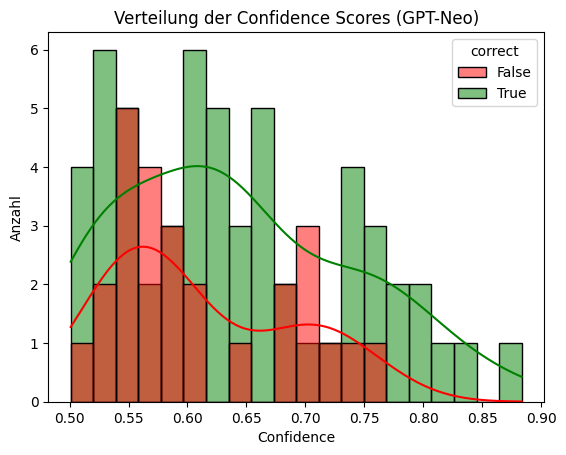

In [5]:
import seaborn as sns
import matplotlib.pyplot as plt
df["label_true"] = df["label"].apply(map_label)
df["correct"] = df["label_true"] == df["label_finetuned-llama3-synthetic+train_subjects"]

sns.histplot(data=df, x="confidence_finetuned-llama3-synthetic+train_subjects", hue="correct", bins=20, kde=True, palette=["red", "green"])
plt.title("Verteilung der Confidence Scores (GPT-Neo)")
plt.xlabel("Confidence")
plt.ylabel("Anzahl")
plt.show()

### Test Gesamt

In [1]:
import torch
import os
import pandas as pd
from transformers import (
    AutoTokenizer,
    AutoModelForCausalLM,
    AutoModelForSeq2SeqLM,
    RobertaTokenizer,
    RobertaForSequenceClassification,
)
import torch.nn.functional as F
from tqdm import tqdm  # für Ladebalken

# CUDA Device
os.environ["CUDA_VISIBLE_DEVICES"] = "5"  # anpassen falls nötig
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Prompt-Template mit Statement + Subjects
def build_prompt(statement, subjects):
    return (
        f"Statement: {statement}\n"
        f"Task: Decide if the statement is factually correct. For better context, consider the subjects: {subjects}.\n"
        f"Answer only with True or False.\n"
        f"Example:\n"
        f"Statement: The sky is green.\n"
        f"Subjects: Weather, Nature\n"
        f"Answer: False\n"
        f"Statement: {statement}\n"
        f"Answer:"
    )

# Modelle
models = {
    "finetuned-llama3-synthetic+train_subjects": "causal",
    # weitere Modelle können ergänzt werden
}

# Daten laden
df = pd.read_csv(r"preprocessed_test_cleaned.csv", sep="\t")
df = df.iloc[:2000].copy()

statements = df["statement"].tolist()
subjects = df["subjects"].tolist()

# Ergebnisse speichern
results = {name: [] for name in models}
confidences = {name: [] for name in models}  # für Confidence Score

# Modelle durchlaufen
for model_name, model_type in models.items():
    print(f"Lade Modell: {model_name} ({model_type})")

    if model_type == "causal":
        tokenizer = AutoTokenizer.from_pretrained(model_name, use_fast=True)
        model = AutoModelForCausalLM.from_pretrained(model_name).to(device)
        model.eval()

        # Tokens mit führendem Leerzeichen, wichtig!
        true_token_id = tokenizer(" True", add_special_tokens=False)["input_ids"][0]
        false_token_id = tokenizer(" False", add_special_tokens=False)["input_ids"][0]

        # tqdm Ladebalken für Fortschritt
        for text, subj in tqdm(zip(statements, subjects), total=len(statements), desc="Processing causal model"):
            prompt = build_prompt(text, subj)
            inputs = tokenizer(prompt, return_tensors="pt", truncation=True).to(device)
            with torch.no_grad():
                outputs = model(**inputs)
                logits = outputs.logits
                next_token_logits = logits[0, -1, :]
                probs = F.softmax(next_token_logits, dim=-1)

            prob_true = probs[true_token_id].item()
            prob_false = probs[false_token_id].item()

            if prob_true > prob_false:
                result = "True"
                confidence = prob_true
            else:
                result = "False"
                confidence = prob_false

            results[model_name].append(result)
            confidences[model_name].append(confidence)

# Ergebnisse im DataFrame speichern
for model_name in results:
    suffix = model_name.split("/")[-1]
    df[f"label_{suffix}"] = results[model_name]
    # Nur für causal Modell Confidence speichern
    if model_name in confidences:
        df[f"confidence_{suffix}"] = confidences[model_name]

# Ausgabe DataFrame (z.B. df.head())
df.head


2025-07-20 10:05:29.465183: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1752998729.497719   33641 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1752998729.506673   33641 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1752998729.527439   33641 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1752998729.527486   33641 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1752998729.527489   33641 computation_placer.cc:177] computation placer alr

Lade Modell: finetuned-llama3-synthetic+train_subjects (causal)


Loading checkpoint shards:   0%|          | 0/4 [00:00<?, ?it/s]

Processing causal model: 100%|██████████| 1267/1267 [03:04<00:00,  6.87it/s]


<bound method NDFrame.head of             label                                          statement  \
0            true  Building a wall on the U.S . Mexico border wil...   
1           false  Wisconsin is on pace to double the number of l...   
2           false  Says John McCain has done nothing to help the ...   
3       half-true  Suzanne Bonamici supports a plan that will cut...   
4      pants-fire  When asked by a reporter whether hes at the ce...   
...           ...                                                ...   
1262    half-true  Says his budget provides the highest state fun...   
1263  barely-true                   Ive been here almost every day .   
1264  barely-true  In the early 1980s Sen . Edward Kennedy secret...   
1265  barely-true  Says an EPA permit languished under Strickland...   
1266        false  Says the governor is going around the state ta...   

                                               subjects  \
0                                           im

In [2]:
import pandas as pd
from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
)

# Definiere deine Labelgruppen
true_labels = ["true", "mostly-true", "half-true"]
false_labels = ["barely-true", "false", "pants-fire", "pants-on-fire"]

# Mapping-Funktion: Normalisiert die Labels zu "True" oder "False"
def map_label(label):
    label = str(label).strip().lower()
    if label in true_labels:
        return "True"
    elif label in false_labels:
        return "False"
    else:
        return "False"  # Default für unbekannte Labels

# Wandle Ground Truth und Prediction in binäre Kategorien um
y_true = df["label"].apply(map_label)
y_pred = df["label_finetuned-llama3-synthetic+train_subjects"].apply(lambda x: map_label(x))

# Konfusionsmatrix
cm = confusion_matrix(y_true, y_pred, labels=["True", "False"])
print("Confusion Matrix (True/False):")
print(cm)

print(f"\nAccuracy:  {accuracy_score(y_true, y_pred)}")
print(f"Precision: {precision_score(y_true, y_pred, pos_label='True')}  (bezogen auf 'True')")
print(f"Recall:    {recall_score(y_true, y_pred, pos_label='True')}  (bezogen auf 'True')")
print(f"F1 Score:  {f1_score(y_true, y_pred, pos_label='True')}  (bezogen auf 'True')")

# Optionaler vollständiger Bericht
print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=["True", "False"]))


Confusion Matrix (True/False):
[[553 161]
 [280 273]]

Accuracy:  0.6519337016574586
Precision: 0.6638655462184874  (bezogen auf 'True')
Recall:    0.7745098039215687  (bezogen auf 'True')
F1 Score:  0.7149321266968326  (bezogen auf 'True')

Classification Report:
              precision    recall  f1-score   support

        True       0.63      0.49      0.55       553
       False       0.66      0.77      0.71       714

    accuracy                           0.65      1267
   macro avg       0.65      0.63      0.63      1267
weighted avg       0.65      0.65      0.64      1267



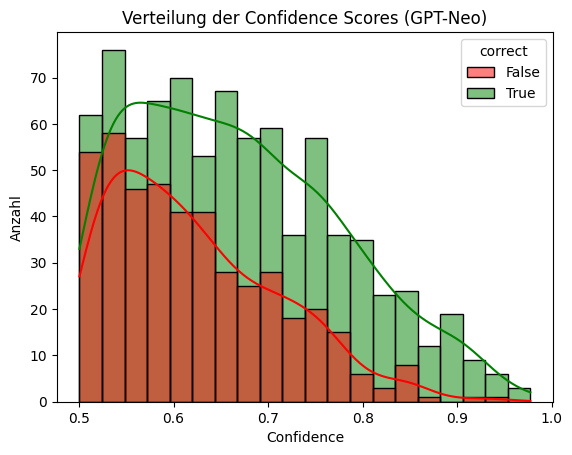

In [3]:
import seaborn as sns
import matplotlib.pyplot as plt
df["label_true"] = df["label"].apply(map_label)
df["correct"] = df["label_true"] == df["label_finetuned-llama3-synthetic+train_subjects"]

sns.histplot(data=df, x="confidence_finetuned-llama3-synthetic+train_subjects", hue="correct", bins=20, kde=True, palette=["red", "green"])
plt.title("Verteilung der Confidence Scores (GPT-Neo)")
plt.xlabel("Confidence")
plt.ylabel("Anzahl")
plt.show()

## Deepseek Normal

In [2]:
from transformers import AutoTokenizer, AutoModelForCausalLM, TrainingArguments, Trainer, DataCollatorForLanguageModeling
from datasets import load_dataset, Dataset
from peft import get_peft_model, LoraConfig, TaskType
import torch
import os 

os.environ["CUDA_VISIBLE_DEVICES"] = "2,3"  # anpassen falls nötig
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model_name = "deepseek-ai/deepseek-llm-7b-base"
tokenizer = AutoTokenizer.from_pretrained(model_name, use_fast=True)
tokenizer.pad_token = tokenizer.eos_token  # Wichtig für CausalLM

# Beispiel-Daten laden (hier: lokal aus JSONL-Datei)
dataset = load_dataset("json", data_files={"train": "fine_tune_data_synthetic+train.jsonl"})["train"]

# Tokenisierung
def tokenize(example):
    return tokenizer(example["text"], truncation=True, padding="max_length", max_length=512)

tokenized_dataset = dataset.map(tokenize, batched=True)

# Modell mit LoRA initialisieren
base_model = AutoModelForCausalLM.from_pretrained(model_name, device_map="auto", torch_dtype=torch.float16)

peft_config = LoraConfig(
    r=8,
    lora_alpha=32,
    target_modules=["q_proj", "v_proj"],  # hängt vom Modell ab
    lora_dropout=0.05,
    bias="none",
    task_type=TaskType.CAUSAL_LM
)

model = get_peft_model(base_model, peft_config)

# Trainingskonfiguration
training_args = TrainingArguments(
    output_dir="./results",
    per_device_train_batch_size=2,
    gradient_accumulation_steps=4,
    num_train_epochs=3,
    logging_dir="./logs",
    save_total_limit=2,
    fp16=True,
    optim="adamw_torch",
    logging_steps=10,
    save_steps=100,
    learning_rate=2e-5,
    report_to="none",
    max_steps=1500
)

data_collator = DataCollatorForLanguageModeling(tokenizer, mlm=False)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_dataset,
    tokenizer=tokenizer,
    data_collator=data_collator,
)

trainer.train()


Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

/tmp/ipykernel_34111/2609284458.py:56: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(
No label_names provided for model class `PeftModelForCausalLM`. Since `PeftModel` hides base models input arguments, if label_names is not given, label_names can't be set automatically within `Trainer`. Note that empty label_names list will be used instead.


Step,Training Loss
10,3.027200
20,2.978400
30,2.838900
40,2.684700
50,2.476600
60,2.224400
70,1.952100
80,1.671700
90,1.391500
100,1.298000


TrainOutput(global_step=1500, training_loss=0.9820888729095459, metrics={'train_runtime': 1497.8589, 'train_samples_per_second': 8.011, 'train_steps_per_second': 1.001, 'total_flos': 2.3932703273385984e+17, 'train_loss': 0.9820888729095459, 'epoch': 1.054871614491734})

In [3]:
trainer.save_model("finetuned-deepseek-synthetic+train_normal")
tokenizer.save_pretrained("finetuned-deepseek-synthetic+train_normal")

('finetuned-deepseek-synthetic+train_normal/tokenizer_config.json',
 'finetuned-deepseek-synthetic+train_normal/special_tokens_map.json',
 'finetuned-deepseek-synthetic+train_normal/tokenizer.json')

### Test Healthcare

In [1]:
import torch
import os
import pandas as pd
from transformers import (
    AutoTokenizer,
    AutoModelForCausalLM,
)
import torch.nn.functional as F
from tqdm import tqdm  # für den Ladebalken

# CUDA-Konfiguration
os.environ["CUDA_VISIBLE_DEVICES"] = "2"  # anpassen falls nötig
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Prompt-Template
def build_prompt(text):
    return (
        f"Statement: {text}\n"
        f"Task: Determine whether the statement is factually correct or fake news. Use only publicly verifiable and objective facts. Do not guess.\n"
        f"Answer with only one word: True or False.\n"
        f"Answer:"
    )

# Modell-Auswahl
models = {
    "finetuned-deepseek-synthetic+train_normal": "causal"
}

# Daten laden
df = pd.read_csv("healthcare_prompts_test.csv", sep=",")
df = df.iloc[:2000].copy()
statements = df["statement"].tolist()

# Ergebnis-Speicher
results = {name: [] for name in models}
confidences = {name: [] for name in models}

# Modelle durchlaufen
for model_name, model_type in models.items():
    print(f"\n📦 Lade Modell: {model_name} ({model_type})")

    tokenizer = AutoTokenizer.from_pretrained(model_name, use_fast=True)
    model = AutoModelForCausalLM.from_pretrained(model_name).to(device)
    model.eval()

    # Token IDs für " True" und " False" (mit führendem Leerzeichen!)
    true_token_id = tokenizer(" True", add_special_tokens=False)["input_ids"][0]
    false_token_id = tokenizer(" False", add_special_tokens=False)["input_ids"][0]

    # Verarbeitung mit Ladebalken
    for text in tqdm(statements, desc="🔍 Verarbeitung"):
        prompt = build_prompt(text)
        inputs = tokenizer(prompt, return_tensors="pt").to(device)

        with torch.no_grad():
            outputs = model(**inputs)
            logits = outputs.logits
            next_token_logits = logits[0, -1, :]  # nächstes Token
            probs = F.softmax(next_token_logits, dim=-1)

        # Wahrscheinlichkeiten abrufen
        prob_true = probs[true_token_id].item()
        prob_false = probs[false_token_id].item()

        if prob_true > prob_false:
            result = "True"
            confidence = prob_true
        else:
            result = "False"
            confidence = prob_false

        results[model_name].append(result)
        confidences[model_name].append(confidence)

# Ergebnisse ins DataFrame schreiben
for model_name in results:
    suffix = model_name.split("/")[-1]
    df[f"label_{suffix}"] = results[model_name]
    df[f"confidence_{suffix}"] = confidences[model_name]

# Ausgabe zur Kontrolle
print("\n✅ Verarbeitung abgeschlossen.")
df



📦 Lade Modell: finetuned-deepseek-synthetic+train_normal (causal)


2025-07-20 10:44:40.942970: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1753001080.964345   35681 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1753001080.970182   35681 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1753001080.986731   35681 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1753001080.986744   35681 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1753001080.986746   35681 computation_placer.cc:177] computation placer alr

Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

🔍 Verarbeitung: 100%|██████████| 83/83 [00:11<00:00,  7.29it/s]


✅ Verarbeitung abgeschlossen.


,label,statement,subjects,label_finetuned-deepseek-synthetic+train_normal,confidence_finetuned-deepseek-synthetic+train_normal
0,true,Each year 18000 people die in America because ...,health-care,True,0.560790
1,mostly-true,Active duty males in the military are twice as...,"health-care,military",True,0.587121
2,half-true,Says Thomas Jefferson said You might be able t...,"health-care,history",True,0.755619
3,barely-true,Because of the federal health care law 300000 ...,health-care,True,0.559391
4,barely-true,Pre-existing conditions are covered under my (...,"debates,health-care",True,0.721050
...,...,...,...,...,...
78,false,We had an amendment in the health care law tha...,"education,health-care",False,0.614155
79,true,Texas has the highest rate of uninsured in the...,health-care,True,0.626501
80,true,Says 80 percent of the health care dollars are...,"health-care,public-health",True,0.723447
81,pants-fire,Says state Rep . Sandy Pasch her recall oppone...,"health-care,unions",False,0.625990


In [2]:
import pandas as pd
from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
)

# Definiere deine Labelgruppen
true_labels = ["true", "mostly-true", "half-true"]
false_labels = ["barely-true", "false", "pants-fire", "pants-on-fire"]

# Mapping-Funktion: Normalisiert die Labels zu "True" oder "False"
def map_label(label):
    label = str(label).strip().lower()
    if label in true_labels:
        return "True"
    elif label in false_labels:
        return "False"
    else:
        return "False"  # Default für unbekannte Labels

# Wandle Ground Truth und Prediction in binäre Kategorien um
y_true = df["label"].apply(map_label)
y_pred = df["label_finetuned-deepseek-synthetic+train_normal"].apply(lambda x: map_label(x))

# Konfusionsmatrix
cm = confusion_matrix(y_true, y_pred, labels=["True", "False"])
print("Confusion Matrix (True/False):")
print(cm)

print(f"\nAccuracy:  {accuracy_score(y_true, y_pred)}")
print(f"Precision: {precision_score(y_true, y_pred, pos_label='True')}  (bezogen auf 'True')")
print(f"Recall:    {recall_score(y_true, y_pred, pos_label='True')}  (bezogen auf 'True')")
print(f"F1 Score:  {f1_score(y_true, y_pred, pos_label='True')}  (bezogen auf 'True')")

# Optionaler vollständiger Bericht
print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=["True", "False"]))


Confusion Matrix (True/False):
[[27 15]
 [14 27]]

Accuracy:  0.6506024096385542
Precision: 0.6585365853658537  (bezogen auf 'True')
Recall:    0.6428571428571429  (bezogen auf 'True')
F1 Score:  0.6506024096385542  (bezogen auf 'True')

Classification Report:
              precision    recall  f1-score   support

        True       0.64      0.66      0.65        41
       False       0.66      0.64      0.65        42

    accuracy                           0.65        83
   macro avg       0.65      0.65      0.65        83
weighted avg       0.65      0.65      0.65        83



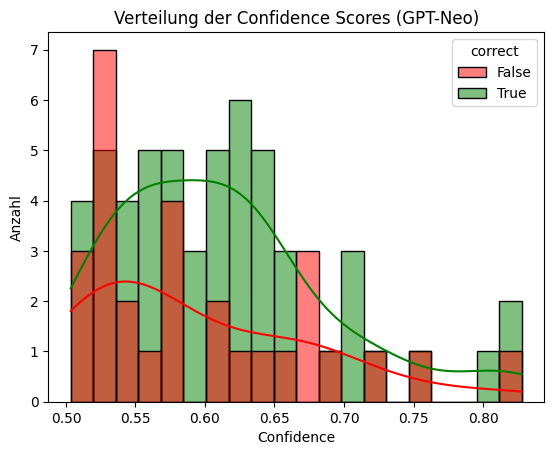

In [3]:
import seaborn as sns
import matplotlib.pyplot as plt
df["label_true"] = df["label"].apply(map_label)
df["correct"] = df["label_true"] == df["label_finetuned-deepseek-synthetic+train_normal"]

sns.histplot(data=df, x="confidence_finetuned-deepseek-synthetic+train_normal", hue="correct", bins=20, kde=True, palette=["red", "green"])
plt.title("Verteilung der Confidence Scores (GPT-Neo)")
plt.xlabel("Confidence")
plt.ylabel("Anzahl")
plt.show()

### Test Gesamt

In [1]:
import torch
import os
import pandas as pd
from transformers import (
    AutoTokenizer,
    AutoModelForCausalLM,
)
import torch.nn.functional as F
from tqdm import tqdm  # für den Ladebalken

# CUDA-Konfiguration
os.environ["CUDA_VISIBLE_DEVICES"] = "2"  # anpassen falls nötig
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Prompt-Template
def build_prompt(text):
    return (
        f"Statement: {text}\n"
        f"Task: Determine whether the statement is factually correct or fake news. Use only publicly verifiable and objective facts. Do not guess.\n"
        f"Answer with only one word: True or False.\n"
        f"Answer:"
    )

# Modell-Auswahl
models = {
    "finetuned-deepseek-synthetic+train_normal": "causal"
}

# Daten laden
df = pd.read_csv("preprocessed_test_cleaned.csv", sep="	")
df = df.iloc[:2000].copy()
statements = df["statement"].tolist()

# Ergebnis-Speicher
results = {name: [] for name in models}
confidences = {name: [] for name in models}

# Modelle durchlaufen
for model_name, model_type in models.items():
    print(f"\n📦 Lade Modell: {model_name} ({model_type})")

    tokenizer = AutoTokenizer.from_pretrained(model_name, use_fast=True)
    model = AutoModelForCausalLM.from_pretrained(model_name).to(device)
    model.eval()

    # Token IDs für " True" und " False" (mit führendem Leerzeichen!)
    true_token_id = tokenizer(" True", add_special_tokens=False)["input_ids"][0]
    false_token_id = tokenizer(" False", add_special_tokens=False)["input_ids"][0]

    # Verarbeitung mit Ladebalken
    for text in tqdm(statements, desc="🔍 Verarbeitung"):
        prompt = build_prompt(text)
        inputs = tokenizer(prompt, return_tensors="pt").to(device)

        with torch.no_grad():
            outputs = model(**inputs)
            logits = outputs.logits
            next_token_logits = logits[0, -1, :]  # nächstes Token
            probs = F.softmax(next_token_logits, dim=-1)

        # Wahrscheinlichkeiten abrufen
        prob_true = probs[true_token_id].item()
        prob_false = probs[false_token_id].item()

        if prob_true > prob_false:
            result = "True"
            confidence = prob_true
        else:
            result = "False"
            confidence = prob_false

        results[model_name].append(result)
        confidences[model_name].append(confidence)

# Ergebnisse ins DataFrame schreiben
for model_name in results:
    suffix = model_name.split("/")[-1]
    df[f"label_{suffix}"] = results[model_name]
    df[f"confidence_{suffix}"] = confidences[model_name]

# Ausgabe zur Kontrolle
print("\n✅ Verarbeitung abgeschlossen.")
df



📦 Lade Modell: finetuned-deepseek-synthetic+train_normal (causal)


2025-07-20 10:48:16.411685: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1753001296.431159   36146 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1753001296.436904   36146 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1753001296.453458   36146 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1753001296.453471   36146 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1753001296.453473   36146 computation_placer.cc:177] computation placer alr

Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

🔍 Verarbeitung: 100%|██████████| 1267/1267 [01:55<00:00, 10.99it/s]


✅ Verarbeitung abgeschlossen.


,label,statement,subjects,label_finetuned-deepseek-synthetic+train_normal,confidence_finetuned-deepseek-synthetic+train_normal
0,true,Building a wall on the U.S . Mexico border wil...,immigration,True,0.633581
1,false,Wisconsin is on pace to double the number of l...,jobs,False,0.523311
2,false,Says John McCain has done nothing to help the ...,"military,veterans,voting-record",False,0.792556
3,half-true,Suzanne Bonamici supports a plan that will cut...,"medicare,message-machine-2012,campaign-adverti...",False,0.523634
4,pants-fire,When asked by a reporter whether hes at the ce...,"campaign-finance,legal-issues,campaign-adverti...",False,0.649978
...,...,...,...,...,...
1262,half-true,Says his budget provides the highest state fun...,education,True,0.710725
1263,barely-true,Ive been here almost every day .,"civil-rights,crime,criminal-justice",True,0.585509
1264,barely-true,In the early 1980s Sen . Edward Kennedy secret...,"bipartisanship,congress,foreign-policy,history",True,0.536985
1265,barely-true,Says an EPA permit languished under Strickland...,"environment,government-efficiency",True,0.500014


In [2]:
import pandas as pd
from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
)

# Definiere deine Labelgruppen
true_labels = ["true", "mostly-true", "half-true"]
false_labels = ["barely-true", "false", "pants-fire", "pants-on-fire"]

# Mapping-Funktion: Normalisiert die Labels zu "True" oder "False"
def map_label(label):
    label = str(label).strip().lower()
    if label in true_labels:
        return "True"
    elif label in false_labels:
        return "False"
    else:
        return "False"  # Default für unbekannte Labels

# Wandle Ground Truth und Prediction in binäre Kategorien um
y_true = df["label"].apply(map_label)
y_pred = df["label_finetuned-deepseek-synthetic+train_normal"].apply(lambda x: map_label(x))

# Konfusionsmatrix
cm = confusion_matrix(y_true, y_pred, labels=["True", "False"])
print("Confusion Matrix (True/False):")
print(cm)

print(f"\nAccuracy:  {accuracy_score(y_true, y_pred)}")
print(f"Precision: {precision_score(y_true, y_pred, pos_label='True')}  (bezogen auf 'True')")
print(f"Recall:    {recall_score(y_true, y_pred, pos_label='True')}  (bezogen auf 'True')")
print(f"F1 Score:  {f1_score(y_true, y_pred, pos_label='True')}  (bezogen auf 'True')")

# Optionaler vollständiger Bericht
print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=["True", "False"]))


Confusion Matrix (True/False):
[[514 200]
 [247 306]]

Accuracy:  0.6471981057616417
Precision: 0.6754270696452037  (bezogen auf 'True')
Recall:    0.7198879551820728  (bezogen auf 'True')
F1 Score:  0.6969491525423729  (bezogen auf 'True')

Classification Report:
              precision    recall  f1-score   support

        True       0.60      0.55      0.58       553
       False       0.68      0.72      0.70       714

    accuracy                           0.65      1267
   macro avg       0.64      0.64      0.64      1267
weighted avg       0.64      0.65      0.64      1267



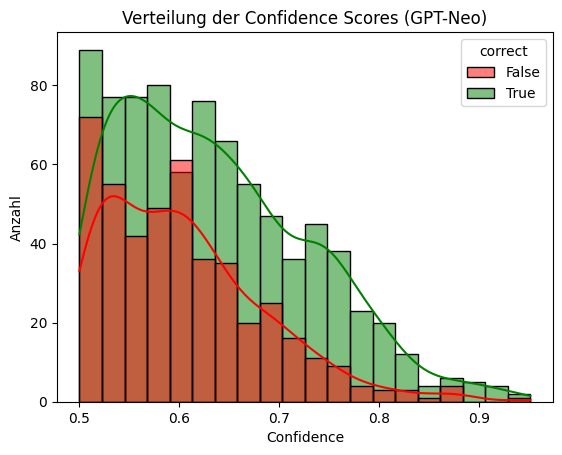

In [3]:
import seaborn as sns
import matplotlib.pyplot as plt
df["label_true"] = df["label"].apply(map_label)
df["correct"] = df["label_true"] == df["label_finetuned-deepseek-synthetic+train_normal"]

sns.histplot(data=df, x="confidence_finetuned-deepseek-synthetic+train_normal", hue="correct", bins=20, kde=True, palette=["red", "green"])
plt.title("Verteilung der Confidence Scores (GPT-Neo)")
plt.xlabel("Confidence")
plt.ylabel("Anzahl")
plt.show()

## Deepseek Subjects

In [1]:
from transformers import AutoTokenizer, AutoModelForCausalLM, TrainingArguments, Trainer, DataCollatorForLanguageModeling
from datasets import load_dataset, Dataset
from peft import get_peft_model, LoraConfig, TaskType
import torch
import os 

os.environ["CUDA_VISIBLE_DEVICES"] = "2,3"  # anpassen falls nötig
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model_name = "deepseek-ai/deepseek-llm-7b-base"
tokenizer = AutoTokenizer.from_pretrained(model_name, use_fast=True)
tokenizer.pad_token = tokenizer.eos_token  # Wichtig für CausalLM

# Beispiel-Daten laden (hier: lokal aus JSONL-Datei)
dataset = load_dataset("json", data_files={"train": "fine_tune_data_subjects_synthetic+train.jsonl"})["train"]

# Tokenisierung
def tokenize(example):
    return tokenizer(example["text"], truncation=True, padding="max_length", max_length=512)

tokenized_dataset = dataset.map(tokenize, batched=True)

# Modell mit LoRA initialisieren
base_model = AutoModelForCausalLM.from_pretrained(model_name, device_map="auto", torch_dtype=torch.float16)

peft_config = LoraConfig(
    r=8,
    lora_alpha=32,
    target_modules=["q_proj", "v_proj"],  # hängt vom Modell ab
    lora_dropout=0.05,
    bias="none",
    task_type=TaskType.CAUSAL_LM
)

model = get_peft_model(base_model, peft_config)

# Trainingskonfiguration
training_args = TrainingArguments(
    output_dir="./results",
    per_device_train_batch_size=2,
    gradient_accumulation_steps=4,
    num_train_epochs=3,
    logging_dir="./logs",
    save_total_limit=2,
    fp16=True,
    optim="adamw_torch",
    logging_steps=10,
    save_steps=100,
    learning_rate=2e-5,
    report_to="none",
    max_steps=1500
)

data_collator = DataCollatorForLanguageModeling(tokenizer, mlm=False)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_dataset,
    tokenizer=tokenizer,
    data_collator=data_collator,
)

trainer.train()


2025-07-20 10:55:32.659789: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1753001732.681122   37474 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1753001732.687571   37474 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1753001732.705866   37474 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1753001732.705890   37474 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1753001732.705892   37474 computation_placer.cc:177] computation placer alr

Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

/tmp/ipykernel_37474/91822938.py:56: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(
No label_names provided for model class `PeftModelForCausalLM`. Since `PeftModel` hides base models input arguments, if label_names is not given, label_names can't be set automatically within `Trainer`. Note that empty label_names list will be used instead.


Step,Training Loss
10,2.410900
20,2.372700
30,2.241300
40,2.089800
50,1.871300
60,1.661900
70,1.420600
80,1.287500
90,1.122000
100,0.987300


TrainOutput(global_step=1500, training_loss=0.6907564776738485, metrics={'train_runtime': 1459.4729, 'train_samples_per_second': 8.222, 'train_steps_per_second': 1.028, 'total_flos': 2.3932703273385984e+17, 'train_loss': 0.6907564776738485, 'epoch': 1.054871614491734})

In [2]:
trainer.save_model("finetuned-deepseek-synthetic+train_subjects")
tokenizer.save_pretrained("finetuned-deepseek-synthetic+train_subjects")

('finetuned-deepseek-synthetic+train_subjects/tokenizer_config.json',
 'finetuned-deepseek-synthetic+train_subjects/special_tokens_map.json',
 'finetuned-deepseek-synthetic+train_subjects/tokenizer.json')

### Test Healthcare

In [1]:
import torch
import os
import pandas as pd
from transformers import (
    AutoTokenizer,
    AutoModelForCausalLM,
    AutoModelForSeq2SeqLM,
    RobertaTokenizer,
    RobertaForSequenceClassification,
)
import torch.nn.functional as F
from tqdm import tqdm  # für Ladebalken

# CUDA Device
os.environ["CUDA_VISIBLE_DEVICES"] = "5"  # anpassen falls nötig
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Prompt-Template mit Statement + Subjects
def build_prompt(statement, subjects):
    return (
        f"Statement: {statement}\n"
        f"Task: Decide if the statement is factually correct. For better context, consider the subjects: {subjects}.\n"
        f"Answer only with True or False.\n"
        f"Example:\n"
        f"Statement: The sky is green.\n"
        f"Subjects: Weather, Nature\n"
        f"Answer: False\n"
        f"Statement: {statement}\n"
        f"Answer:"
    )

# Modelle
models = {
    "finetuned-deepseek-synthetic+train_subjects": "causal",
    # weitere Modelle können ergänzt werden
}

# Daten laden
df = pd.read_csv(r"healthcare_prompts_test.csv", sep=",")
df = df.iloc[:2000].copy()

statements = df["statement"].tolist()
subjects = df["subjects"].tolist()

# Ergebnisse speichern
results = {name: [] for name in models}
confidences = {name: [] for name in models}  # für Confidence Score

# Modelle durchlaufen
for model_name, model_type in models.items():
    print(f"Lade Modell: {model_name} ({model_type})")

    if model_type == "causal":
        tokenizer = AutoTokenizer.from_pretrained(model_name, use_fast=True)
        model = AutoModelForCausalLM.from_pretrained(model_name).to(device)
        model.eval()

        # Tokens mit führendem Leerzeichen, wichtig!
        true_token_id = tokenizer(" True", add_special_tokens=False)["input_ids"][0]
        false_token_id = tokenizer(" False", add_special_tokens=False)["input_ids"][0]

        # tqdm Ladebalken für Fortschritt
        for text, subj in tqdm(zip(statements, subjects), total=len(statements), desc="Processing causal model"):
            prompt = build_prompt(text, subj)
            inputs = tokenizer(prompt, return_tensors="pt", truncation=True).to(device)
            with torch.no_grad():
                outputs = model(**inputs)
                logits = outputs.logits
                next_token_logits = logits[0, -1, :]
                probs = F.softmax(next_token_logits, dim=-1)

            prob_true = probs[true_token_id].item()
            prob_false = probs[false_token_id].item()

            if prob_true > prob_false:
                result = "True"
                confidence = prob_true
            else:
                result = "False"
                confidence = prob_false

            results[model_name].append(result)
            confidences[model_name].append(confidence)

# Ergebnisse im DataFrame speichern
for model_name in results:
    suffix = model_name.split("/")[-1]
    df[f"label_{suffix}"] = results[model_name]
    # Nur für causal Modell Confidence speichern
    if model_name in confidences:
        df[f"confidence_{suffix}"] = confidences[model_name]

# Ausgabe DataFrame (z.B. df.head())
df.head


2025-07-20 11:22:14.730141: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1753003334.751371   38251 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1753003334.758019   38251 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1753003334.777656   38251 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1753003334.777681   38251 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1753003334.777683   38251 computation_placer.cc:177] computation placer alr

Lade Modell: finetuned-deepseek-synthetic+train_subjects (causal)


Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

Processing causal model: 100%|██████████| 83/83 [00:10<00:00,  7.95it/s]


<bound method NDFrame.head of           label                                          statement  \
0          true  Each year 18000 people die in America because ...   
1   mostly-true  Active duty males in the military are twice as...   
2     half-true  Says Thomas Jefferson said You might be able t...   
3   barely-true  Because of the federal health care law 300000 ...   
4   barely-true  Pre-existing conditions are covered under my (...   
..          ...                                                ...   
78        false  We had an amendment in the health care law tha...   
79         true  Texas has the highest rate of uninsured in the...   
80         true  Says 80 percent of the health care dollars are...   
81   pants-fire  Says state Rep . Sandy Pasch her recall oppone...   
82    half-true  Says Mark Pryorcut Medicare to pay for Obamaca...   

                     subjects  \
0                 health-care   
1        health-care,military   
2         health-care,history 

In [2]:
import pandas as pd
from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
)

# Definiere deine Labelgruppen
true_labels = ["true", "mostly-true", "half-true"]
false_labels = ["barely-true", "false", "pants-fire", "pants-on-fire"]

# Mapping-Funktion: Normalisiert die Labels zu "True" oder "False"
def map_label(label):
    label = str(label).strip().lower()
    if label in true_labels:
        return "True"
    elif label in false_labels:
        return "False"
    else:
        return "False"  # Default für unbekannte Labels

# Wandle Ground Truth und Prediction in binäre Kategorien um
y_true = df["label"].apply(map_label)
y_pred = df["label_finetuned-deepseek-synthetic+train_subjects"].apply(lambda x: map_label(x))

# Konfusionsmatrix
cm = confusion_matrix(y_true, y_pred, labels=["True", "False"])
print("Confusion Matrix (True/False):")
print(cm)

print(f"\nAccuracy:  {accuracy_score(y_true, y_pred)}")
print(f"Precision: {precision_score(y_true, y_pred, pos_label='True')}  (bezogen auf 'True')")
print(f"Recall:    {recall_score(y_true, y_pred, pos_label='True')}  (bezogen auf 'True')")
print(f"F1 Score:  {f1_score(y_true, y_pred, pos_label='True')}  (bezogen auf 'True')")

# Optionaler vollständiger Bericht
print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=["True", "False"]))


Confusion Matrix (True/False):
[[28 14]
 [17 24]]

Accuracy:  0.6265060240963856
Precision: 0.6222222222222222  (bezogen auf 'True')
Recall:    0.6666666666666666  (bezogen auf 'True')
F1 Score:  0.6436781609195402  (bezogen auf 'True')

Classification Report:
              precision    recall  f1-score   support

        True       0.63      0.59      0.61        41
       False       0.62      0.67      0.64        42

    accuracy                           0.63        83
   macro avg       0.63      0.63      0.63        83
weighted avg       0.63      0.63      0.63        83



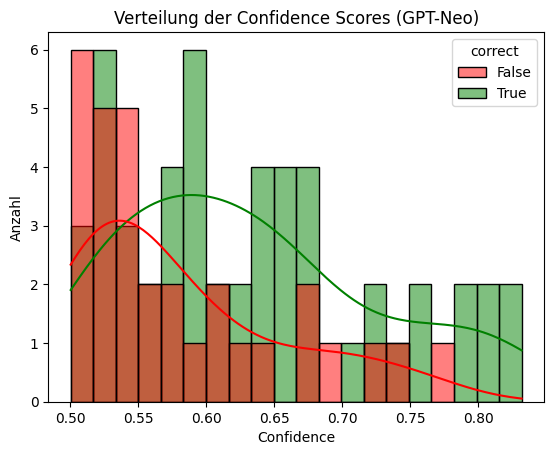

In [3]:
import seaborn as sns
import matplotlib.pyplot as plt
df["label_true"] = df["label"].apply(map_label)
df["correct"] = df["label_true"] == df["label_finetuned-deepseek-synthetic+train_subjects"]

sns.histplot(data=df, x="confidence_finetuned-deepseek-synthetic+train_subjects", hue="correct", bins=20, kde=True, palette=["red", "green"])
plt.title("Verteilung der Confidence Scores (GPT-Neo)")
plt.xlabel("Confidence")
plt.ylabel("Anzahl")
plt.show()

### Test Gesamt

In [1]:
import torch
import os
import pandas as pd
from transformers import (
    AutoTokenizer,
    AutoModelForCausalLM,
    AutoModelForSeq2SeqLM,
    RobertaTokenizer,
    RobertaForSequenceClassification,
)
import torch.nn.functional as F
from tqdm import tqdm  # für Ladebalken

# CUDA Device
os.environ["CUDA_VISIBLE_DEVICES"] = "5"  # anpassen falls nötig
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Prompt-Template mit Statement + Subjects
def build_prompt(statement, subjects):
    return (
        f"Statement: {statement}\n"
        f"Task: Decide if the statement is factually correct. For better context, consider the subjects: {subjects}.\n"
        f"Answer only with True or False.\n"
        f"Example:\n"
        f"Statement: The sky is green.\n"
        f"Subjects: Weather, Nature\n"
        f"Answer: False\n"
        f"Statement: {statement}\n"
        f"Answer:"
    )

# Modelle
models = {
    "finetuned-deepseek-synthetic+train_subjects": "causal",
    # weitere Modelle können ergänzt werden
}

# Daten laden
df = pd.read_csv(r"preprocessed_test_cleaned.csv", sep="\t")
df = df.iloc[:2000].copy()

statements = df["statement"].tolist()
subjects = df["subjects"].tolist()

# Ergebnisse speichern
results = {name: [] for name in models}
confidences = {name: [] for name in models}  # für Confidence Score

# Modelle durchlaufen
for model_name, model_type in models.items():
    print(f"Lade Modell: {model_name} ({model_type})")

    if model_type == "causal":
        tokenizer = AutoTokenizer.from_pretrained(model_name, use_fast=True)
        model = AutoModelForCausalLM.from_pretrained(model_name).to(device)
        model.eval()

        # Tokens mit führendem Leerzeichen, wichtig!
        true_token_id = tokenizer(" True", add_special_tokens=False)["input_ids"][0]
        false_token_id = tokenizer(" False", add_special_tokens=False)["input_ids"][0]

        # tqdm Ladebalken für Fortschritt
        for text, subj in tqdm(zip(statements, subjects), total=len(statements), desc="Processing causal model"):
            prompt = build_prompt(text, subj)
            inputs = tokenizer(prompt, return_tensors="pt", truncation=True).to(device)
            with torch.no_grad():
                outputs = model(**inputs)
                logits = outputs.logits
                next_token_logits = logits[0, -1, :]
                probs = F.softmax(next_token_logits, dim=-1)

            prob_true = probs[true_token_id].item()
            prob_false = probs[false_token_id].item()

            if prob_true > prob_false:
                result = "True"
                confidence = prob_true
            else:
                result = "False"
                confidence = prob_false

            results[model_name].append(result)
            confidences[model_name].append(confidence)

# Ergebnisse im DataFrame speichern
for model_name in results:
    suffix = model_name.split("/")[-1]
    df[f"label_{suffix}"] = results[model_name]
    # Nur für causal Modell Confidence speichern
    if model_name in confidences:
        df[f"confidence_{suffix}"] = confidences[model_name]

# Ausgabe DataFrame (z.B. df.head())
df.head


2025-07-20 11:23:38.460967: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1753003418.485597   38683 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1753003418.492491   38683 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1753003418.510230   38683 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1753003418.510264   38683 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1753003418.510266   38683 computation_placer.cc:177] computation placer alr

Lade Modell: finetuned-deepseek-synthetic+train_subjects (causal)


Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

Processing causal model: 100%|██████████| 1267/1267 [02:41<00:00,  7.86it/s]


<bound method NDFrame.head of             label                                          statement  \
0            true  Building a wall on the U.S . Mexico border wil...   
1           false  Wisconsin is on pace to double the number of l...   
2           false  Says John McCain has done nothing to help the ...   
3       half-true  Suzanne Bonamici supports a plan that will cut...   
4      pants-fire  When asked by a reporter whether hes at the ce...   
...           ...                                                ...   
1262    half-true  Says his budget provides the highest state fun...   
1263  barely-true                   Ive been here almost every day .   
1264  barely-true  In the early 1980s Sen . Edward Kennedy secret...   
1265  barely-true  Says an EPA permit languished under Strickland...   
1266        false  Says the governor is going around the state ta...   

                                               subjects  \
0                                           im

In [2]:
import pandas as pd
from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
)

# Definiere deine Labelgruppen
true_labels = ["true", "mostly-true", "half-true"]
false_labels = ["barely-true", "false", "pants-fire", "pants-on-fire"]

# Mapping-Funktion: Normalisiert die Labels zu "True" oder "False"
def map_label(label):
    label = str(label).strip().lower()
    if label in true_labels:
        return "True"
    elif label in false_labels:
        return "False"
    else:
        return "False"  # Default für unbekannte Labels

# Wandle Ground Truth und Prediction in binäre Kategorien um
y_true = df["label"].apply(map_label)
y_pred = df["label_finetuned-deepseek-synthetic+train_subjects"].apply(lambda x: map_label(x))

# Konfusionsmatrix
cm = confusion_matrix(y_true, y_pred, labels=["True", "False"])
print("Confusion Matrix (True/False):")
print(cm)

print(f"\nAccuracy:  {accuracy_score(y_true, y_pred)}")
print(f"Precision: {precision_score(y_true, y_pred, pos_label='True')}  (bezogen auf 'True')")
print(f"Recall:    {recall_score(y_true, y_pred, pos_label='True')}  (bezogen auf 'True')")
print(f"F1 Score:  {f1_score(y_true, y_pred, pos_label='True')}  (bezogen auf 'True')")

# Optionaler vollständiger Bericht
print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=["True", "False"]))


Confusion Matrix (True/False):
[[517 197]
 [262 291]]

Accuracy:  0.6377269139700079
Precision: 0.6636713735558408  (bezogen auf 'True')
Recall:    0.7240896358543417  (bezogen auf 'True')
F1 Score:  0.6925653047555258  (bezogen auf 'True')

Classification Report:
              precision    recall  f1-score   support

        True       0.60      0.53      0.56       553
       False       0.66      0.72      0.69       714

    accuracy                           0.64      1267
   macro avg       0.63      0.63      0.63      1267
weighted avg       0.63      0.64      0.63      1267



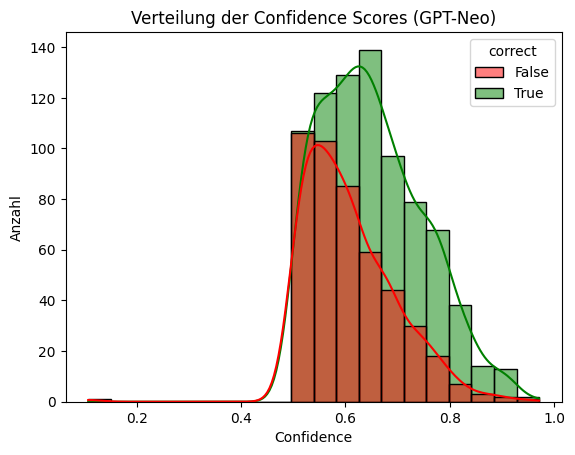

In [3]:
import seaborn as sns
import matplotlib.pyplot as plt
df["label_true"] = df["label"].apply(map_label)
df["correct"] = df["label_true"] == df["label_finetuned-deepseek-synthetic+train_subjects"]

sns.histplot(data=df, x="confidence_finetuned-deepseek-synthetic+train_subjects", hue="correct", bins=20, kde=True, palette=["red", "green"])
plt.title("Verteilung der Confidence Scores (GPT-Neo)")
plt.xlabel("Confidence")
plt.ylabel("Anzahl")
plt.show()